# **Lightweight Machine Learning for Detecting DGA-Based  Botnet Communications (Unbalanced)**

Imports

In [18]:
from collections import Counter
from datetime import datetime
from dateutil import parser
from itertools import combinations
import kagglehub
import matplotlib.pyplot as plt
import math
import pandas as pd
import re
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

Download Benign Domains

In [19]:
cisco_path = kagglehub.dataset_download("adebayo/cisco-umbrella-list")
cisco_path += "/top-1m.csv"
print(cisco_path)

C:\Users\Admin\.cache\kagglehub\datasets\adebayo\cisco-umbrella-list\versions\1/top-1m.csv


Download Malicious DGA Domains

In [20]:
dga_path = kagglehub.dataset_download("gtkcyber/dga-dataset")
dga_path += "/dga_data.csv"
print(dga_path)

C:\Users\Admin\.cache\kagglehub\datasets\gtkcyber\dga-dataset\versions\1/dga_data.csv


Load Datasets

In [21]:
benign_domains = pd.read_csv(cisco_path, header=None)
benign_domains.columns = ["rank", "domain"]
benign_domains["label"] = 0

dga_domains = pd.read_csv(dga_path)
dga_domains["label"] = dga_domains["subclass"].apply(lambda x: 0 if x in ["alexa", "legit"] else 1)
# remove fake DGAs
dga_domains = dga_domains[dga_domains["label"] == 1]

print("Length of Benign Domain dataset:", len(benign_domains))
print("Length of DGA Domain dataset:", len(dga_domains))

benign_sample = benign_domains[["domain", "label"]]
dga_sample = dga_domains[["domain", "label"]]
df = pd.concat([benign_sample, dga_sample], ignore_index=True)
# Drop any rows with missing domains
print("Missing domains (benign):", benign_sample["domain"].isna().sum())
print("Missing domains (DGA):   ", dga_sample["domain"].isna().sum())
df = df.dropna(subset=["domain"]).reset_index(drop=True)
df["domain"] = df["domain"].astype(str).str.lower()

print("\nClass balance:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

Length of Benign Domain dataset: 1000000
Length of DGA Domain dataset: 80000
Missing domains (benign): 0
Missing domains (DGA):    0

Class balance:
label
0    1000000
1      80000
Name: count, dtype: int64
label
0    0.926
1    0.074
Name: proportion, dtype: float64


In [22]:
print(dga_domains.columns.tolist())
print(dga_domains.head(10))

['isDGA', 'domain', 'host', 'subclass', 'label']
  isDGA                      domain                            host  \
0   dga  6xzxsw3sokvg1tc752y1a6p0af  6xzxsw3sokvg1tc752y1a6p0af.com   
1   dga              glbtlxwwhbnpxs               glbtlxwwhbnpxs.ru   
2   dga              xxmamopyipbfpk               xxmamopyipbfpk.ru   
3   dga   zfd5szpi18i85wj9uy13l69rg   zfd5szpi18i85wj9uy13l69rg.net   
4   dga                jpqftymiuver                 jpqftymiuver.ru   
5   dga                   takenroll                   takenroll.net   
6   dga                vrrtneoswsds                 vrrtneoswsds.ru   
7   dga   mzapiwbcsbqiyxnlxa1hprx8n   mzapiwbcsbqiyxnlxa1hprx8n.com   
8   dga              xkoihiygtanuio               xkoihiygtanuio.ru   
9   dga                   dreamdont                   dreamdont.net   

       subclass  label  
0   gameoverdga      1  
1  cryptolocker      1  
2  cryptolocker      1  
3        newgoz      1  
4  cryptolocker      1  
5       nivdort    

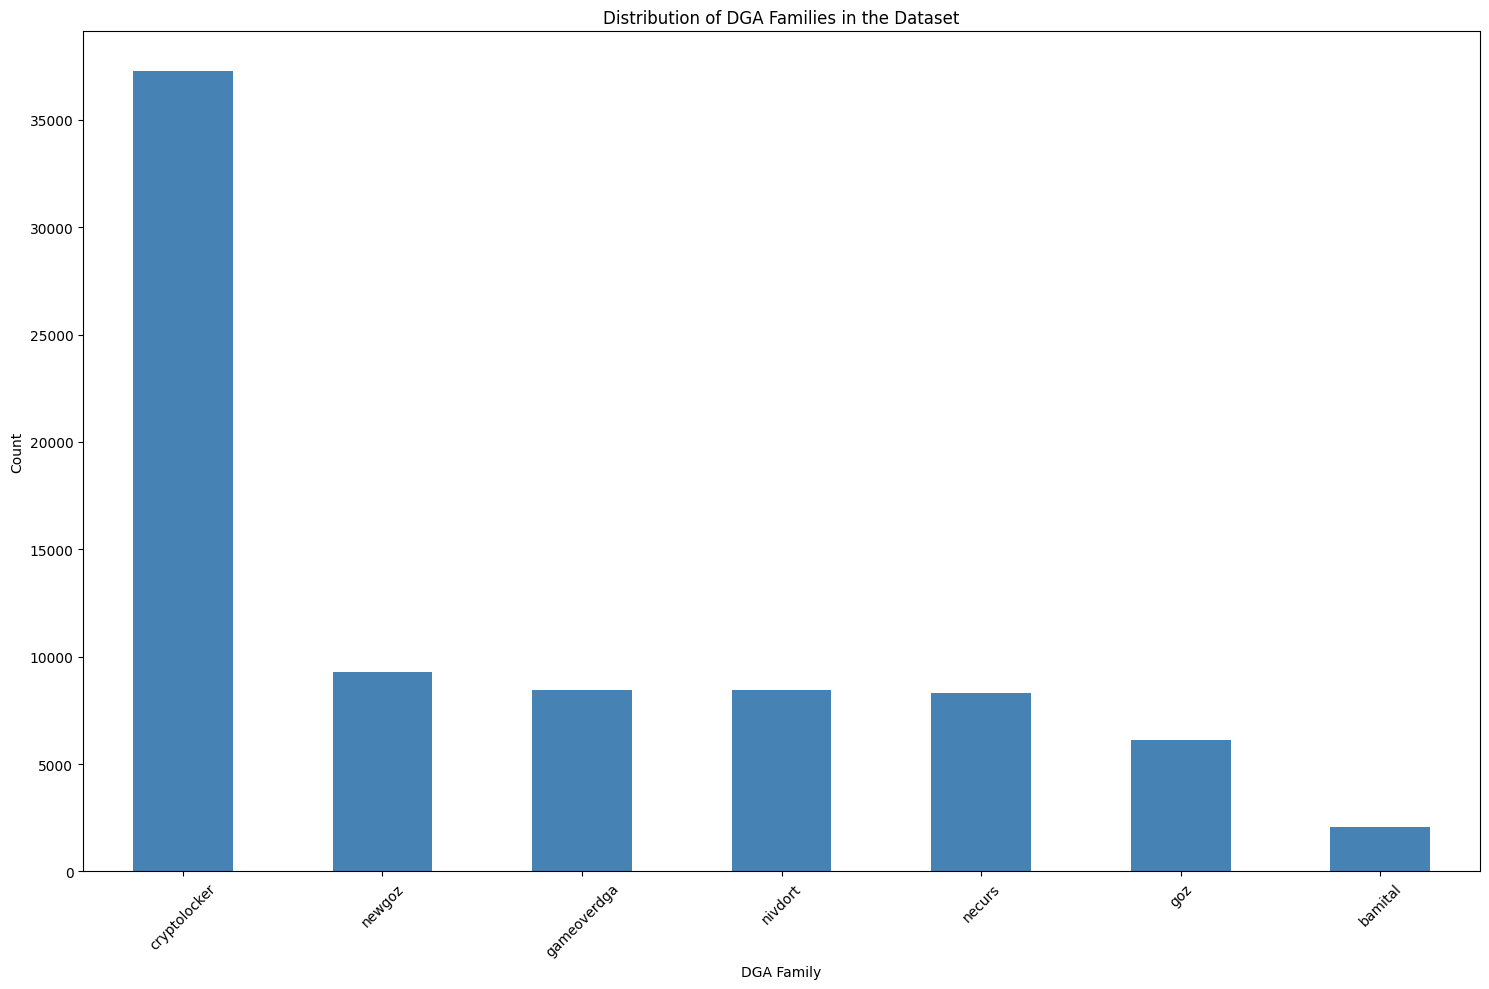


Total DGA families: 7

Appearing families:
subclass
cryptolocker    37254
newgoz           9276
gameoverdga      8461
nivdort          8456
necurs           8331
goz              6136
bamital          2086
Name: count, dtype: int64


In [23]:
family_col = "subclass"

family_counts = dga_domains[family_col].value_counts()

fig, ax = plt.subplots(figsize=(15, 10))
family_counts.plot(kind="bar", ax=ax, color=["steelblue"])
ax.set_xlabel("DGA Family")
ax.set_ylabel("Count")
ax.set_title("Distribution of DGA Families in the Dataset")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTotal DGA families: {family_counts.nunique()}")
print(f"\nAppearing families:\n{family_counts.head(10)}")

In [24]:
print("Sample Domain Names by DGA Family")
for family in dga_domains[family_col].unique():
    examples = dga_domains[dga_domains[family_col] == family]["domain"].head(5).tolist()
    print(f"{family:20s}: {examples}")

Sample Domain Names by DGA Family
gameoverdga         : ['6xzxsw3sokvg1tc752y1a6p0af', '1rw1pc44mkxp4qjx18qua26', '1x75xo41t4fno51wc86e1y4s13d', '1y6oppp7k3pwfpo2sfmkloyxa', '1t5fkef5u26di8wtme9ezjamn']
cryptolocker        : ['glbtlxwwhbnpxs', 'xxmamopyipbfpk', 'jpqftymiuver', 'vrrtneoswsds', 'xkoihiygtanuio']
newgoz              : ['zfd5szpi18i85wj9uy13l69rg', 'mzapiwbcsbqiyxnlxa1hprx8n', 'n3m4txqpb6a415iwzkrmdzgk6', 'wawft814u5se21tmptb51yy47q2', 'by86yc1p7f81d1tb5g7h1el8t9k']
nivdort             : ['takenroll', 'dreamdont', 'visitshot', 'mostjune', 'fairslow']
goz                 : ['rcdqeqmpxgdiuqombhuwcfu', 'jrxrovxkbemgqutopblbbfe', 'dixnzhelzukwsojfxuivlamadu', 'ydhmbyhgypnkdpzcymnnjxcalfm', 'umficyzdvcdpzbalvdmkjjvcm']
necurs              : ['sfmbdpnijlarq', 'vdqqfdcax', 'njtvrfhfaklho', 'hsmcnwof', 'mcedlrfqaqjcypqwhmio']
bamital             : ['5df9d44072820ad6eaac91669f357fea', 'a7fd378e8e64200f13421e6135a06dce', 'dd82f8a0b2b6520e2706f704ba2a289a', '08c9bb43ca6555de477ec262b

In [25]:
rows = []
for family in dga_domains[family_col].value_counts().index:
    examples = dga_domains[dga_domains[family_col] == family]["domain"].head(3).tolist()
    rows.append({
        "Family": family,
        "Count": len(dga_domains[dga_domains[family_col] == family]),
        "Example 1": examples[0] if len(examples) > 0 else "",
        "Example 2": examples[1] if len(examples) > 1 else "",
        "Example 3": examples[2] if len(examples) > 2 else "",
    })
example_table = pd.DataFrame(rows)
print(example_table.to_string(index=False))

      Family  Count                        Example 1                        Example 2                        Example 3
cryptolocker  37254                   glbtlxwwhbnpxs                   xxmamopyipbfpk                     jpqftymiuver
      newgoz   9276        zfd5szpi18i85wj9uy13l69rg        mzapiwbcsbqiyxnlxa1hprx8n        n3m4txqpb6a415iwzkrmdzgk6
 gameoverdga   8461       6xzxsw3sokvg1tc752y1a6p0af          1rw1pc44mkxp4qjx18qua26      1x75xo41t4fno51wc86e1y4s13d
     nivdort   8456                        takenroll                        dreamdont                        visitshot
      necurs   8331                    sfmbdpnijlarq                        vdqqfdcax                    njtvrfhfaklho
         goz   6136          rcdqeqmpxgdiuqombhuwcfu          jrxrovxkbemgqutopblbbfe       dixnzhelzukwsojfxuivlamadu
     bamital   2086 5df9d44072820ad6eaac91669f357fea a7fd378e8e64200f13421e6135a06dce dd82f8a0b2b6520e2706f704ba2a289a


Skipping bamital: not enough variation


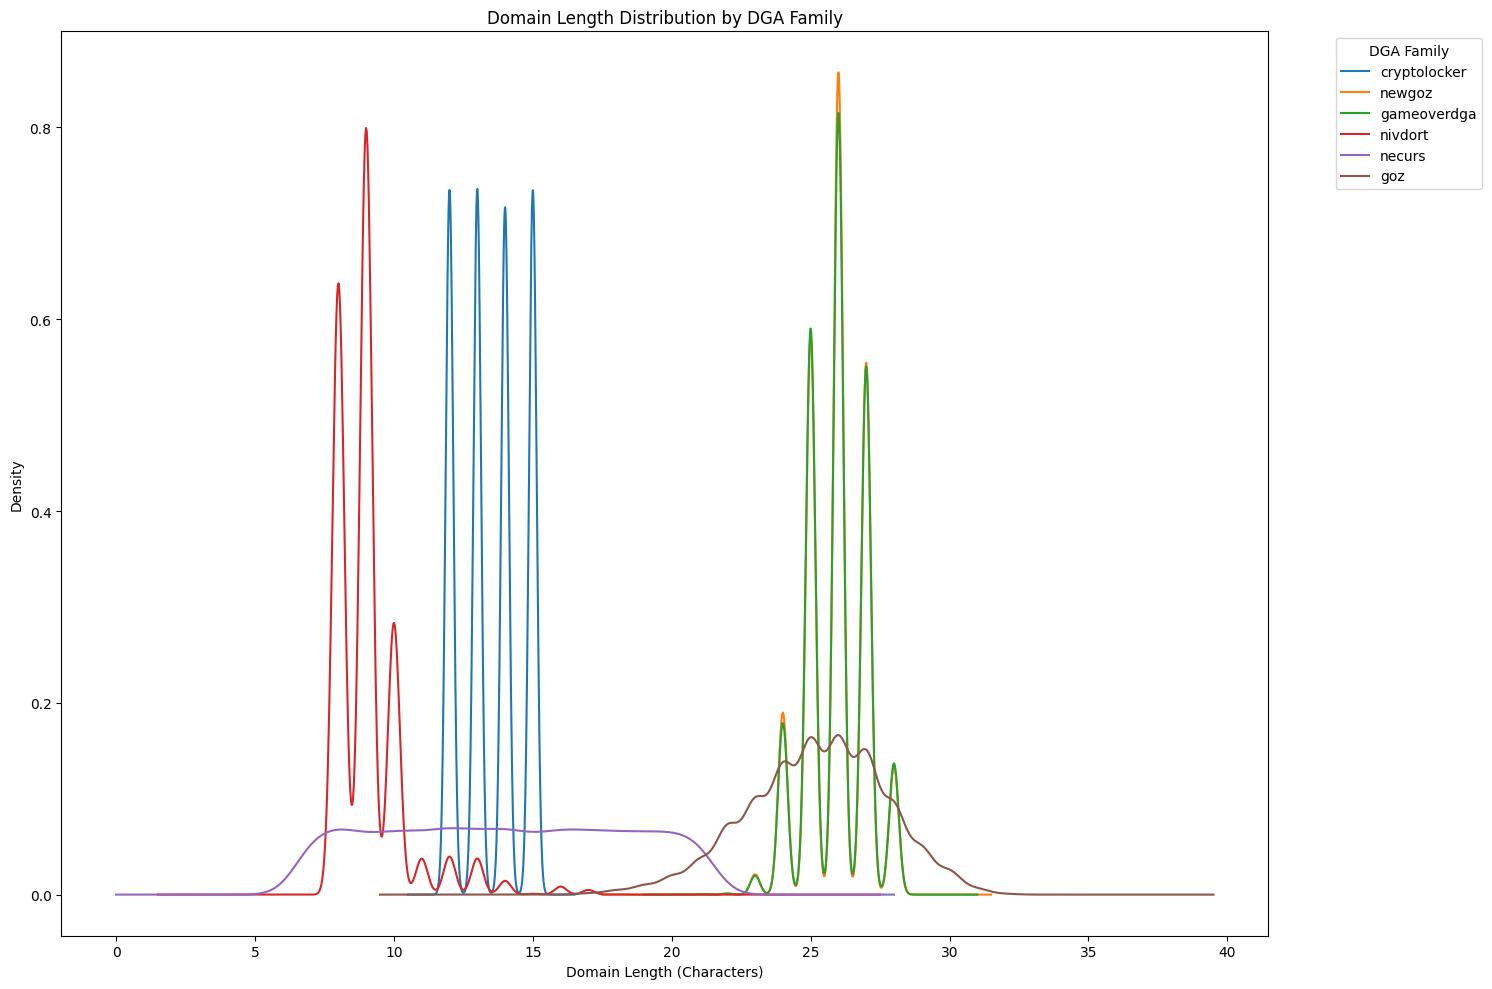

In [26]:
top_families = dga_domains[family_col].value_counts().head(10).index
dgas = dga_domains.copy()
dgas["length"] = dgas["domain"].str.split(".").str[0].str.len()

fig, ax = plt.subplots(figsize=(15, 10))
for family in top_families:
    subset = dgas[dgas[family_col] == family]["length"].dropna()
    if(subset.nunique() < 2):
        print(f"Skipping {family}: not enough variation")
        continue
    subset.plot(kind="kde", ax=ax, label=family)

ax.set_xlabel("Domain Length (Characters)")
ax.set_ylabel("Density")
ax.set_title("Domain Length Distribution by DGA Family")
ax.legend(title="DGA Family", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Extract Features

In [27]:
def shannon_entropy(s):
    """Measures randomness of characters in a string. Higher = more random."""
    if not s:
        return 0.0
    counts = Counter(s)
    length = len(s)
    return -sum((c/length) * math.log2(c/length) for c in counts.values())

def vowel_ratio(s):
    if not s:
        return 0.0
    vowels = sum(1 for ch in s if ch in "aeiou")
    letters = sum(1 for ch in s if ch.isalpha())
    return vowels / letters if letters else 0.0

def digit_ratio(s):
    if not s:
        return 0.0
    return sum(1 for ch in s if ch.isdigit()) / len(s)

def max_consecutive_consonants(s):
    rows = re.findall(r'[^aeiou\d\W_]+', s)
    maximum = max((len(r) for r in rows), default=0)
    return maximum

def hex_valid_ratio(s):
    if(not s):
        return 0
    return sum(1 for ch in s if ch in '0123456789abcdef') / len(s)

def is_dword_value(s):
    return int(bool(re.fullmatch(r'[0-9a-f]{8}', s)))

def max_consecutive_digits(s):
    rows = re.findall(r'\d+', s)
    maximum = max((len(r) for r in rows), default=0)
    return maximum

def is_punycode(domain):
    return int(any(label.startswith('xn--') for label in domain.split('.')))

def subdomain_count(domain):
    return len(domain.split('.')) - 1

# top-level domain
def tld_detection(df):
    tlds = df.groupby("tld")["label"]
    tld_counts = tlds.count()
    tld_sums = tlds.sum()
    # Laplace Smoothing - Benign and DGA (2)
    tld_malicious_laplace_smoothed = (tld_sums + 1) / (tld_counts + 2)
    return df["tld"].map(tld_malicious_laplace_smoothed)

def has_embedded_date(s):
    no_date = datetime(1900, 1, 1)
    try:
        result = parser.parse(s, fuzzy=True, default=no_date)
        if(result.date() == no_date.date()):
            return 0
        return 1
    except (ValueError, parser.ParserError, OverflowError):
        return 0
    
def cons_vowel_transition_rate(s):
    def is_vowel(character):
        return (character in 'aeiou')
    
    # we want to ignore digits and hyphens
    alpha = [ch for ch in s if ch.isalpha()] 
    if(len(alpha) < 2):
        return 0.0
    curr_v = is_vowel(alpha[0])
    trans_count = 0
    if(curr_v):
        vowel_count = 1
    else:
        vowel_count = 0

    for ch in alpha[1:]:
        typing = is_vowel(ch)
        if(typing):
            vowel_count += 1
        # if a change in vowel to consonant or vice-versa, it is a transition
        if(typing != curr_v):
            trans_count += 1
            curr_v = typing

    if(vowel_count < 2):
        return 0.0
    return trans_count / (vowel_count - 1)

def char_class_entropy(s):
    def classify(ch):
        # if a vowel
        if(ch in 'aeiou'):
            return 'V'
        # otherwise if a letter, it is a consonant
        elif(ch.isalpha()):
            return 'C'
        # if it is a number
        elif(ch.isdigit()):
            return 'D'
        # if it is a special character, like a hyphen
        else:
            return 'H'
    classes = ''.join(classify(ch) for ch in s)
    return shannon_entropy(classes)

df["name"] = df["domain"].str.split(".").str[0]
df["tld"] = df["domain"].str.split(".").str[-1]
df["length"] = df["name"].str.len()
df["entropy"] = df["name"].apply(shannon_entropy)
df["vowel_ratio"] = df["name"].apply(vowel_ratio)
df["digit_ratio"] = df["name"].apply(digit_ratio)
df["unique_chars"] = df["name"].apply(lambda s: len(set(s)))
df["hyphen_count"] = df["name"].str.count('-')
df["max_consec_cons"] = df["name"].apply(max_consecutive_consonants)
df["hex_ratio"] = df["name"].apply(hex_valid_ratio)
df["dword"] = df["name"].apply(is_dword_value)
df["max_consec_digit"] = df["name"].apply(max_consecutive_digits)
df["puny_code"] = df["domain"].apply(is_punycode)
df["subdomain_count"] = df["domain"].apply(subdomain_count)
df["mal_tld"] = tld_detection(df)
df["embed_date"] = df["name"].apply(has_embedded_date)
df["cons_vowel_transition_rate"] = df["name"].apply(cons_vowel_transition_rate)
df["char_class_entropy"] = df["name"].apply(char_class_entropy)

In [28]:
print("\n--- Feature statistics by class ---")
summary = df.groupby("label")[["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "mal_tld", "embed_date", "cons_vowel_transition_rate", "char_class_entropy"]].agg(["mean", "std", "median"])
print(summary.round(3))

print("\n--- Random samples ---")
print("Benign:", df[df.label == 0]["domain"].sample(5, random_state=1).tolist())
print("DGA:   ", df[df.label == 1]["domain"].sample(5, random_state=1).tolist())


--- Feature statistics by class ---
       length               entropy               vowel_ratio                \
         mean    std median    mean    std median        mean    std median   
label                                                                         
0       8.547  6.434    7.0   2.306  1.012  2.522       0.273  0.218  0.308   
1      17.213  6.730   14.0   3.460  0.444  3.418       0.217  0.116  0.211   

      digit_ratio  ... mal_tld embed_date                \
             mean  ...  median       mean    std median   
label              ...                                    
0           0.152  ...   0.000      0.151  0.358    0.0   
1           0.089  ...   0.667      0.064  0.245    0.0   

      cons_vowel_transition_rate               char_class_entropy         \
                            mean    std median               mean    std   
label                                                                      
0                          1.375  1.371    

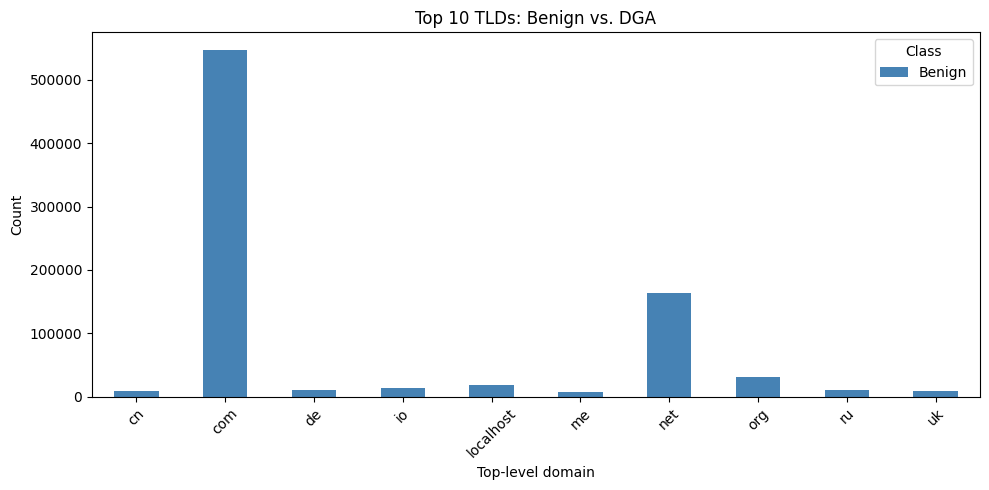

In [29]:
top_tlds = df["tld"].value_counts().head(10).index

# tld_by_class = df[df.tld.isin(top_tlds)].groupby(["tld", "label"]).size().unstack(fill_value=0)
# tld_by_class.columns = ["Benign", "DGA"]
# tld_by_class = tld_by_class.loc[top_tlds]

tld_by_class = (df[df.tld.isin(top_tlds)].groupby(["tld", "label"]).size().unstack(fill_value=0))

tld_by_class = tld_by_class.rename(
    columns={0: "Benign", 1: "DGA"}
)

fig, ax = plt.subplots(figsize=(10, 5))
tld_by_class.plot(kind="bar", ax=ax, color=["steelblue", "crimson"])
ax.set_xlabel("Top-level domain")
ax.set_ylabel("Count")
ax.set_title("Top 10 TLDs: Benign vs. DGA")
ax.legend(title="Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Build a clean comparison table: Benign vs DGA side-by-side
features = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "mal_tld", "embed_date", "cons_vowel_transition_rate", "char_class_entropy"]

stats = df.groupby("label")[features].agg(["mean", "std", "median"])

# Reshape so features are rows and (class, stat) are columns
benign_stats = stats.loc[0].unstack(level=0)  # rows = stat, cols = feature
dga_stats    = stats.loc[1].unstack(level=0)

# Build a tidy summary dataframe
summary = pd.DataFrame({
    "Benign (mean)":   [df[df.label == 0][f].mean()   for f in features],
    "Benign (median)": [df[df.label == 0][f].median() for f in features],
    "Benign (std)":    [df[df.label == 0][f].std()    for f in features],
    "DGA (mean)":      [df[df.label == 1][f].mean()   for f in features],
    "DGA (median)":    [df[df.label == 1][f].median() for f in features],
    "DGA (std)":       [df[df.label == 1][f].std()    for f in features],
}, index=features)

# Add a difference column to highlight which features separate the classes
summary["Δ mean (DGA − Benign)"] = summary["DGA (mean)"] - summary["Benign (mean)"]

summary = summary.round(3)
print(summary.to_string())

                            Benign (mean)  Benign (median)  Benign (std)  DGA (mean)  DGA (median)  DGA (std)  Δ mean (DGA − Benign)
length                              8.547            7.000         6.434      17.213        14.000      6.730                  8.666
entropy                             2.306            2.522         1.012       3.460         3.418      0.444                  1.154
vowel_ratio                         0.273            0.308         0.218       0.217         0.211      0.116                 -0.056
digit_ratio                         0.152            0.000         0.261       0.089         0.000      0.168                 -0.063
unique_chars                        6.465            6.000         3.928      12.487        11.000      3.957                  6.022
hyphen_count                        0.509            0.000         1.156       0.000         0.000      0.000                 -0.509
max_consec_cons                     2.226            2.000         1.

In [31]:
# Styled version for notebook display
styled = (summary.style
    .background_gradient(subset=["Δ mean (DGA − Benign)"], cmap="RdBu_r")
    .format("{:.3f}")
    .set_caption("Feature Statistics by Class (0 = Benign, 1 = DGA)")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "8px")]},
        {"selector": "th", "props": [("text-align", "center"), ("padding", "6px")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "6px")]},
    ])
)
styled

,Benign (mean),Benign (median),Benign (std),DGA (mean),DGA (median),DGA (std),Δ mean (DGA − Benign)
length,8.547,7.000,6.434,17.213,14.000,6.730,8.666
entropy,2.306,2.522,1.012,3.460,3.418,0.444,1.154
vowel_ratio,0.273,0.308,0.218,0.217,0.211,0.116,-0.056
digit_ratio,0.152,0.000,0.261,0.089,0.000,0.168,-0.063
unique_chars,6.465,6.000,3.928,12.487,11.000,3.957,6.022
hyphen_count,0.509,0.000,1.156,0.000,0.000,0.000,-0.509
max_consec_cons,2.226,2.000,1.226,6.031,5.000,3.242,3.806
hex_ratio,0.380,0.333,0.255,0.319,0.286,0.188,-0.062
dword,0.002,0.000,0.048,0.000,0.000,0.004,-0.002
max_consec_digit,0.973,0.000,1.945,0.727,0.000,1.515,-0.247


In [ ]:
def roc_auc_fpr(best_n_acc, best_n_prec, best_n_recall, best_n_f1, X_train, y_train, X_test, y_test):
    # complete ROC-AUC (theoretical capability measure of detecting DGAs) and False Positive Rate (practical deployability)
    fig, ax = plt.subplots(figsize=(8, 6))

    # plot a curve for each metric's best model
    for best_n, label, color in [
        (best_n_acc, "Accuracy", "blue"),
        (best_n_prec, "Precision", "green"),
        (best_n_recall, "Recall", "orange"),
        (best_n_f1, "F1 Score", "red")]:
        clf = RandomForestClassifier(n_estimators=best_n, random_state=60)
        clf.fit(X_train, y_train)
        # probability of a DGA class
        y_prob = clf.predict_proba(X_test)[:, 1]  
        y_pred = clf.predict(X_test)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        # number of benign domains incorrectly flagged as DGA
        fpr0 = fp / (fp + tn)   
        # how many DGA domains were overlooked
        fnr = fn / (fn + tp)
        
        print(f"{label} (n={best_n}):")
        print(f"\tFalse Positive Rate: {fpr0:.5f} ({fpr0*100:.3f}%)")
        print(f"\tFalse Negative Rate: {fnr:.5f} ({fnr*100:.3f}%)")
        print(f"\tTrue Negatives={tn}, False Positives={fp}, False Negatives={fn}, True Positives={tp}\n")
        # fpr = false positive rates, tpr = true positive rates
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, label=f"{label} (AUC = {roc_auc:.3f})")

    # draw a line for the random classifier baseline
    ax.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.50)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC-AUC Curve")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

Logistic Regression's Accuracy:  0.9999074074074074
Logistic Regression's Precision: 0.9987367357251137
Logistic Regression's Recall:    1.0
Logistic Regression's F1 Score:  0.9993679686512451
Training: 1
Training: 2
Training: 3
Training: 4
Training: 5
Training: 6
Training: 7
Training: 8
Training: 9
Training: 10
Training: 11
Training: 12
Training: 13
Training: 14
Training: 15
Training: 16
Training: 17
Training: 18
Training: 19
Training: 20
Training: 21
Training: 22
Training: 23
Training: 24
Training: 25
Training: 26
Training: 27
Training: 28
Training: 29
Training: 30
Training: 31
Training: 32
Training: 33
Training: 34
Training: 35
Training: 36
Training: 37
Training: 38
Training: 39
Training: 40
Training: 41
Training: 42
Training: 43
Training: 44
Training: 45
Training: 46
Training: 47
Training: 48
Training: 49
Training: 50
Training: 51
Training: 52
Training: 53
Training: 54
Training: 55
Training: 56
Training: 57
Training: 58
Training: 59
Training: 60
Training: 61
Training: 62
Training: 

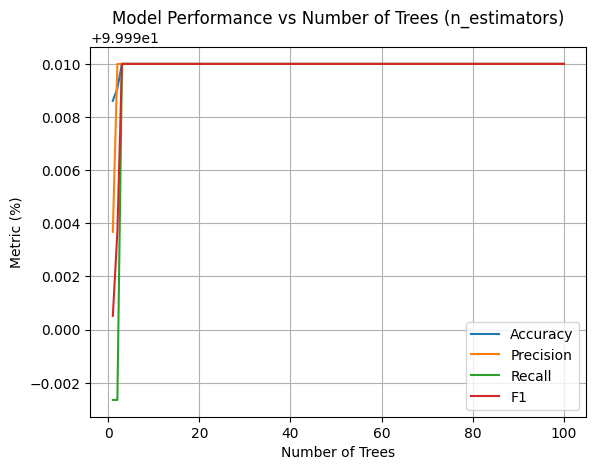

Best n_estimators (Accuracy): 3
Best Accuracy: 1.0
Best n_estimators (Precision): 2
Best Precision: 1.0
Best n_estimators (Recall): 3
Best Recall: 1.0
Best n_estimators (F1): 3
Best F1: 1.0


In [33]:
X = df[["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "mal_tld", "embed_date", "cons_vowel_transition_rate", "char_class_entropy"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

lr = LogisticRegression(max_iter=1000, random_state=60)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f"Logistic Regression's Accuracy:  {accuracy_score(y_test, y_pred)}")
print(f"Logistic Regression's Precision: {precision_score(y_test, y_pred)}")
print(f"Logistic Regression's Recall:    {recall_score(y_test, y_pred)}")
print(f"Logistic Regression's F1 Score:  {f1_score(y_test, y_pred)}")

scores = {}
num_test_estimators = range(1, 101)
for n in num_test_estimators:
  print("Training:", n)
  clf = RandomForestClassifier(n_estimators=n, random_state=60, n_jobs=-1)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  scores[n] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }
accuracies = [scores[n]["accuracy"] * 100 for n in num_test_estimators]
precisions = [scores[n]["precision"] * 100 for n in num_test_estimators]
recalls = [scores[n]["recall"] * 100 for n in num_test_estimators]
f1s = [scores[n]["f1"] * 100 for n in num_test_estimators]
plt.plot(num_test_estimators, accuracies, label="Accuracy")
plt.plot(num_test_estimators, precisions, label="Precision")
plt.plot(num_test_estimators, recalls, label="Recall")
plt.plot(num_test_estimators, f1s, label="F1")
plt.xlabel("Number of Trees")
plt.ylabel("Metric (%)")
plt.title("Model Performance vs Number of Trees (n_estimators)")
plt.legend()
plt.grid(True)
plt.show()

best_n_acc = max(scores, key=lambda n: scores[n]["accuracy"])
best_score_acc = scores[best_n_acc]["accuracy"]
print("Best n_estimators (Accuracy):", best_n_acc)
print("Best Accuracy:", best_score_acc)

best_n_prec = max(scores, key=lambda n: scores[n]["precision"])
best_score_prec = scores[best_n_prec]["precision"]
print("Best n_estimators (Precision):", best_n_prec)
print("Best Precision:", best_score_prec)

best_n_recall = max(scores, key=lambda n: scores[n]["recall"])
best_score_recall = scores[best_n_recall]["recall"]
print("Best n_estimators (Recall):", best_n_recall)
print("Best Recall:", best_score_recall)

best_n_f1 = max(scores, key=lambda n: scores[n]["f1"])
best_score_f1 = scores[best_n_f1]["f1"]
print("Best n_estimators (F1):", best_n_f1)
print("Best F1:", best_score_f1)

In [34]:
def create_best_feature_importance(best_n, ver, color):
    best_clf = RandomForestClassifier(n_estimators=best_n, random_state=60)
    best_clf.fit(X_train, y_train)
    feature_importance = pd.Series(best_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("Feature Importance:\n" + str(feature_importance))
    plt.figure(figsize=(8,5))
    feature_importance.plot(kind="bar", color=color)
    plt.xlabel("Feature")
    plt.ylabel("Importance Score")
    plt.title(f"Random Forest Feature Importance ({ver} Metric)")
    # plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    single_tree = best_clf.estimators_[0]
    fig, ax = plt.subplots(figsize=(20, 10))
    plot_tree(
        single_tree,
        feature_names=X.columns.tolist(),
        class_names=["Benign", "DGA"],
        filled=True,
        rounded=True,
        max_depth=3,
        ax=ax
    )
    plt.title(f"Singular Decision Tree from Random Forest (max_depth=3) ({ver} Metric)")
    plt.tight_layout()
    plt.show()

Feature Importance:
subdomain_count               0.636429
max_consec_cons               0.108048
hyphen_count                  0.085791
entropy                       0.066370
mal_tld                       0.043943
unique_chars                  0.022786
embed_date                    0.013334
length                        0.010986
cons_vowel_transition_rate    0.007714
char_class_entropy            0.002969
vowel_ratio                   0.000924
digit_ratio                   0.000340
hex_ratio                     0.000324
max_consec_digit              0.000042
puny_code                     0.000000
dword                         0.000000
dtype: float64


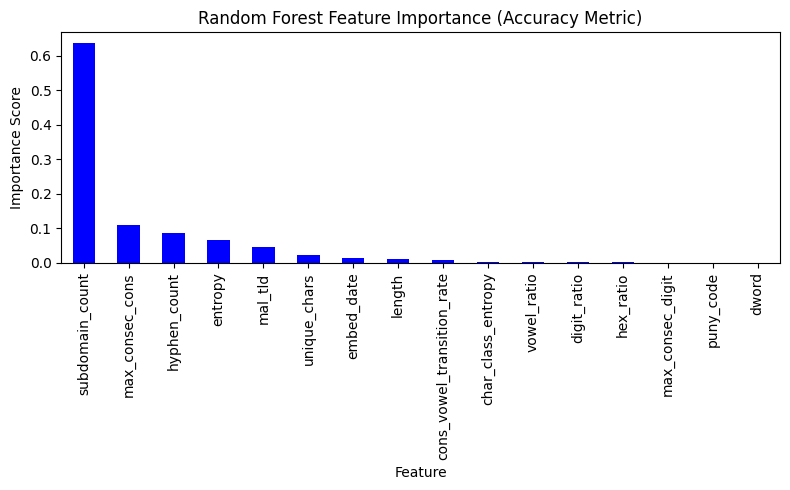

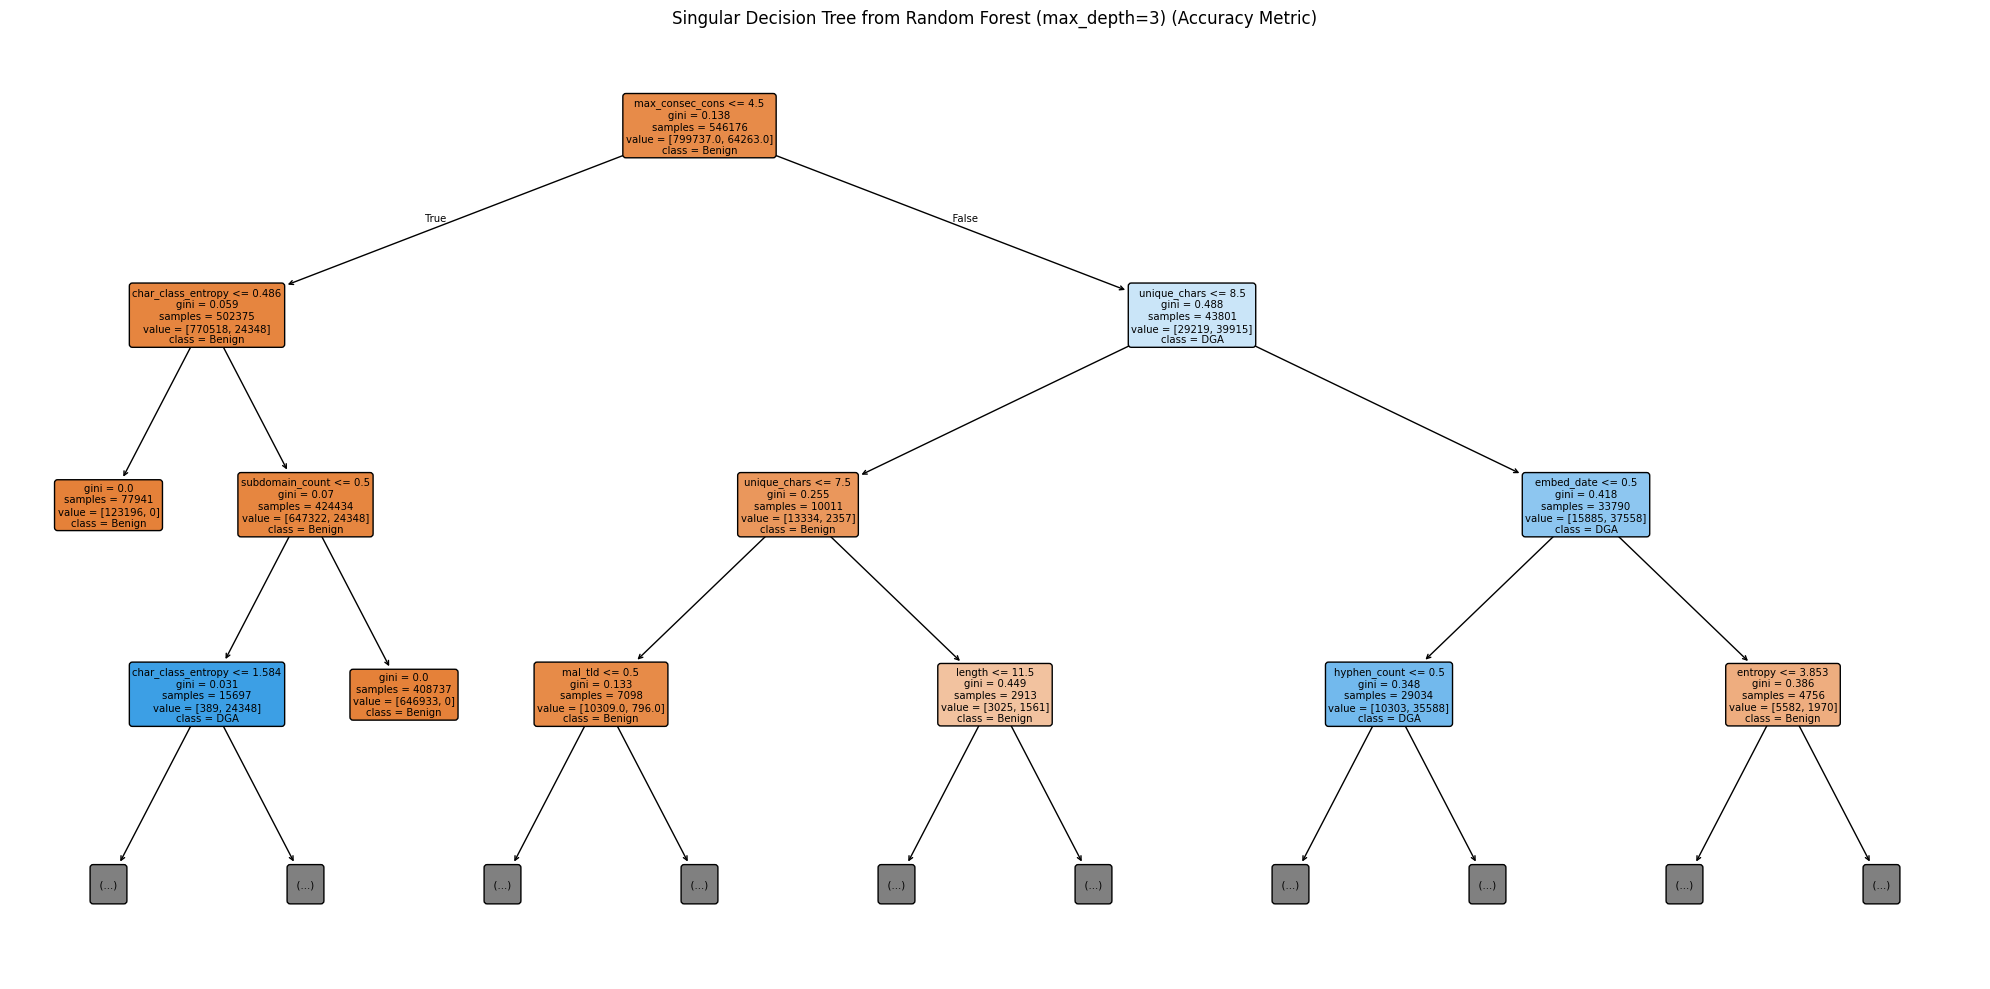

Feature Importance:
subdomain_count               0.706989
max_consec_cons               0.162071
mal_tld                       0.039395
unique_chars                  0.034168
hyphen_count                  0.021728
embed_date                    0.014437
length                        0.010836
entropy                       0.006640
char_class_entropy            0.001996
vowel_ratio                   0.000742
digit_ratio                   0.000510
cons_vowel_transition_rate    0.000407
max_consec_digit              0.000045
hex_ratio                     0.000036
puny_code                     0.000000
dword                         0.000000
dtype: float64


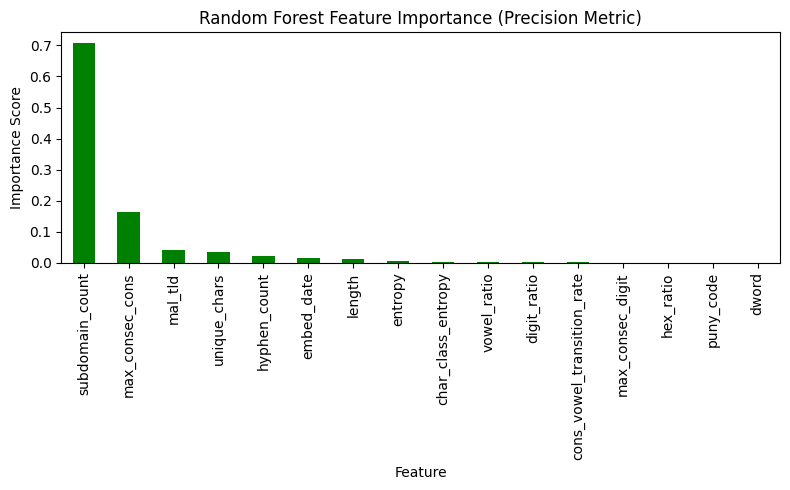

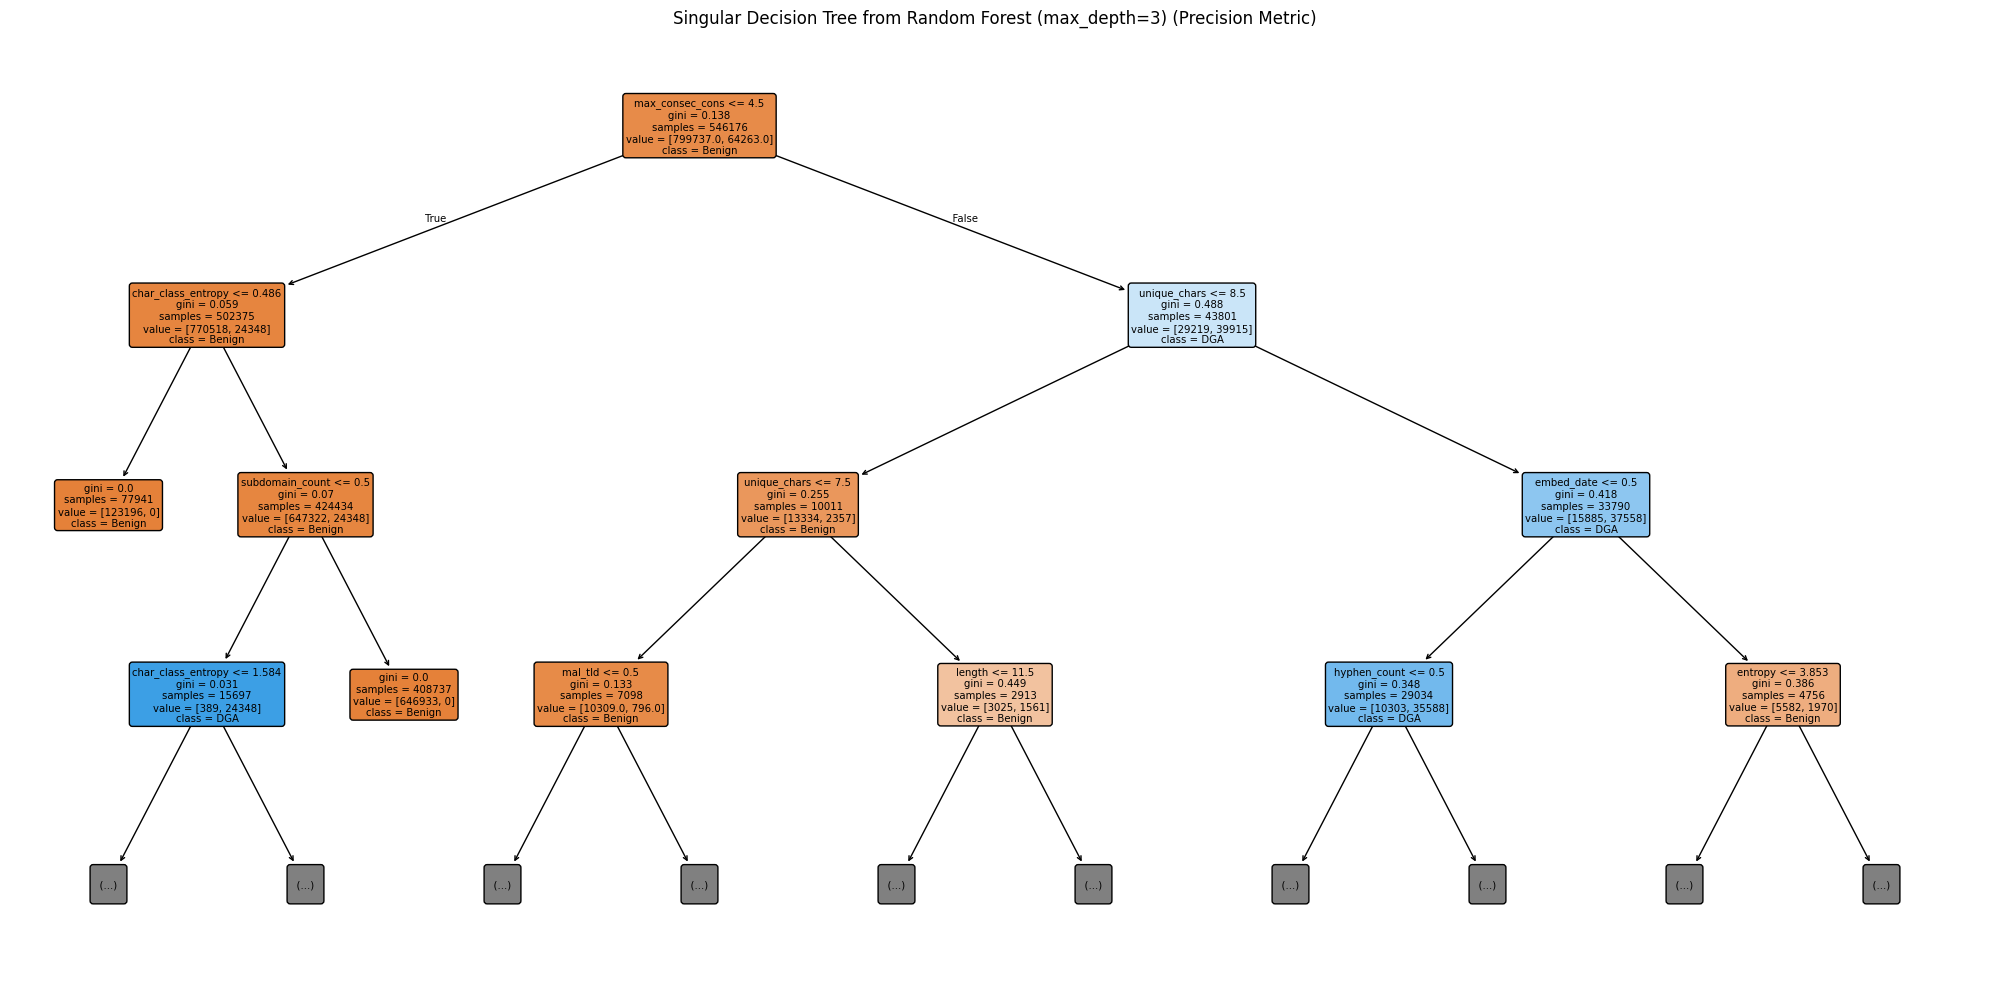

Feature Importance:
subdomain_count               0.636429
max_consec_cons               0.108048
hyphen_count                  0.085791
entropy                       0.066370
mal_tld                       0.043943
unique_chars                  0.022786
embed_date                    0.013334
length                        0.010986
cons_vowel_transition_rate    0.007714
char_class_entropy            0.002969
vowel_ratio                   0.000924
digit_ratio                   0.000340
hex_ratio                     0.000324
max_consec_digit              0.000042
puny_code                     0.000000
dword                         0.000000
dtype: float64


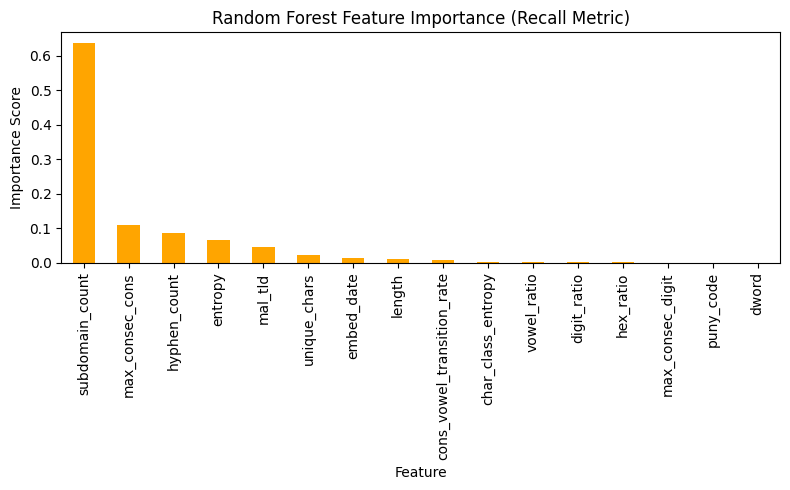

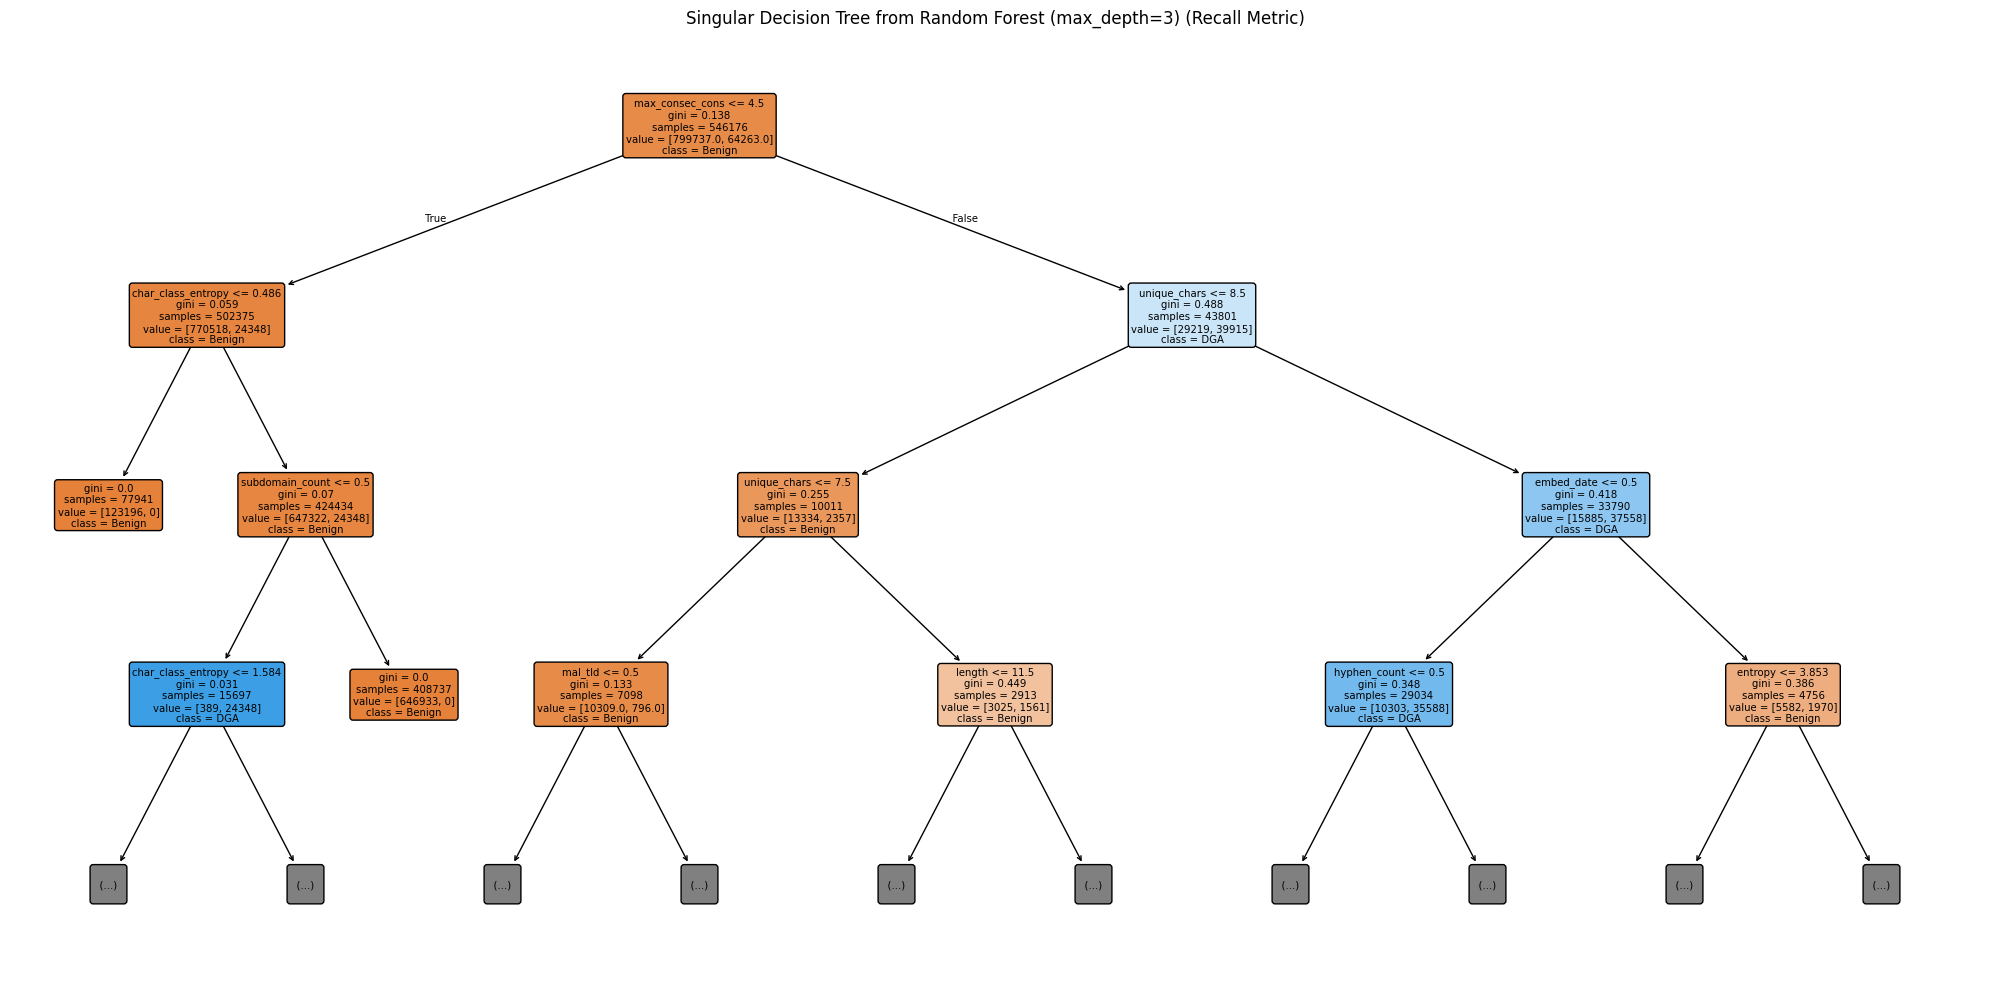

Feature Importance:
subdomain_count               0.636429
max_consec_cons               0.108048
hyphen_count                  0.085791
entropy                       0.066370
mal_tld                       0.043943
unique_chars                  0.022786
embed_date                    0.013334
length                        0.010986
cons_vowel_transition_rate    0.007714
char_class_entropy            0.002969
vowel_ratio                   0.000924
digit_ratio                   0.000340
hex_ratio                     0.000324
max_consec_digit              0.000042
puny_code                     0.000000
dword                         0.000000
dtype: float64


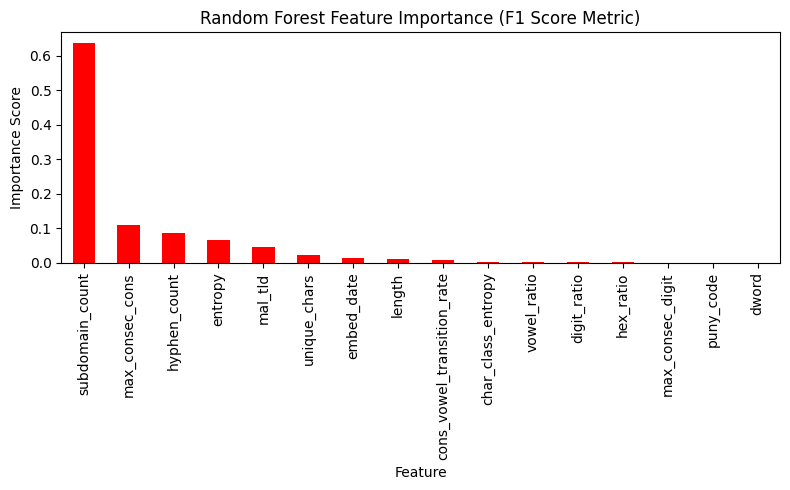

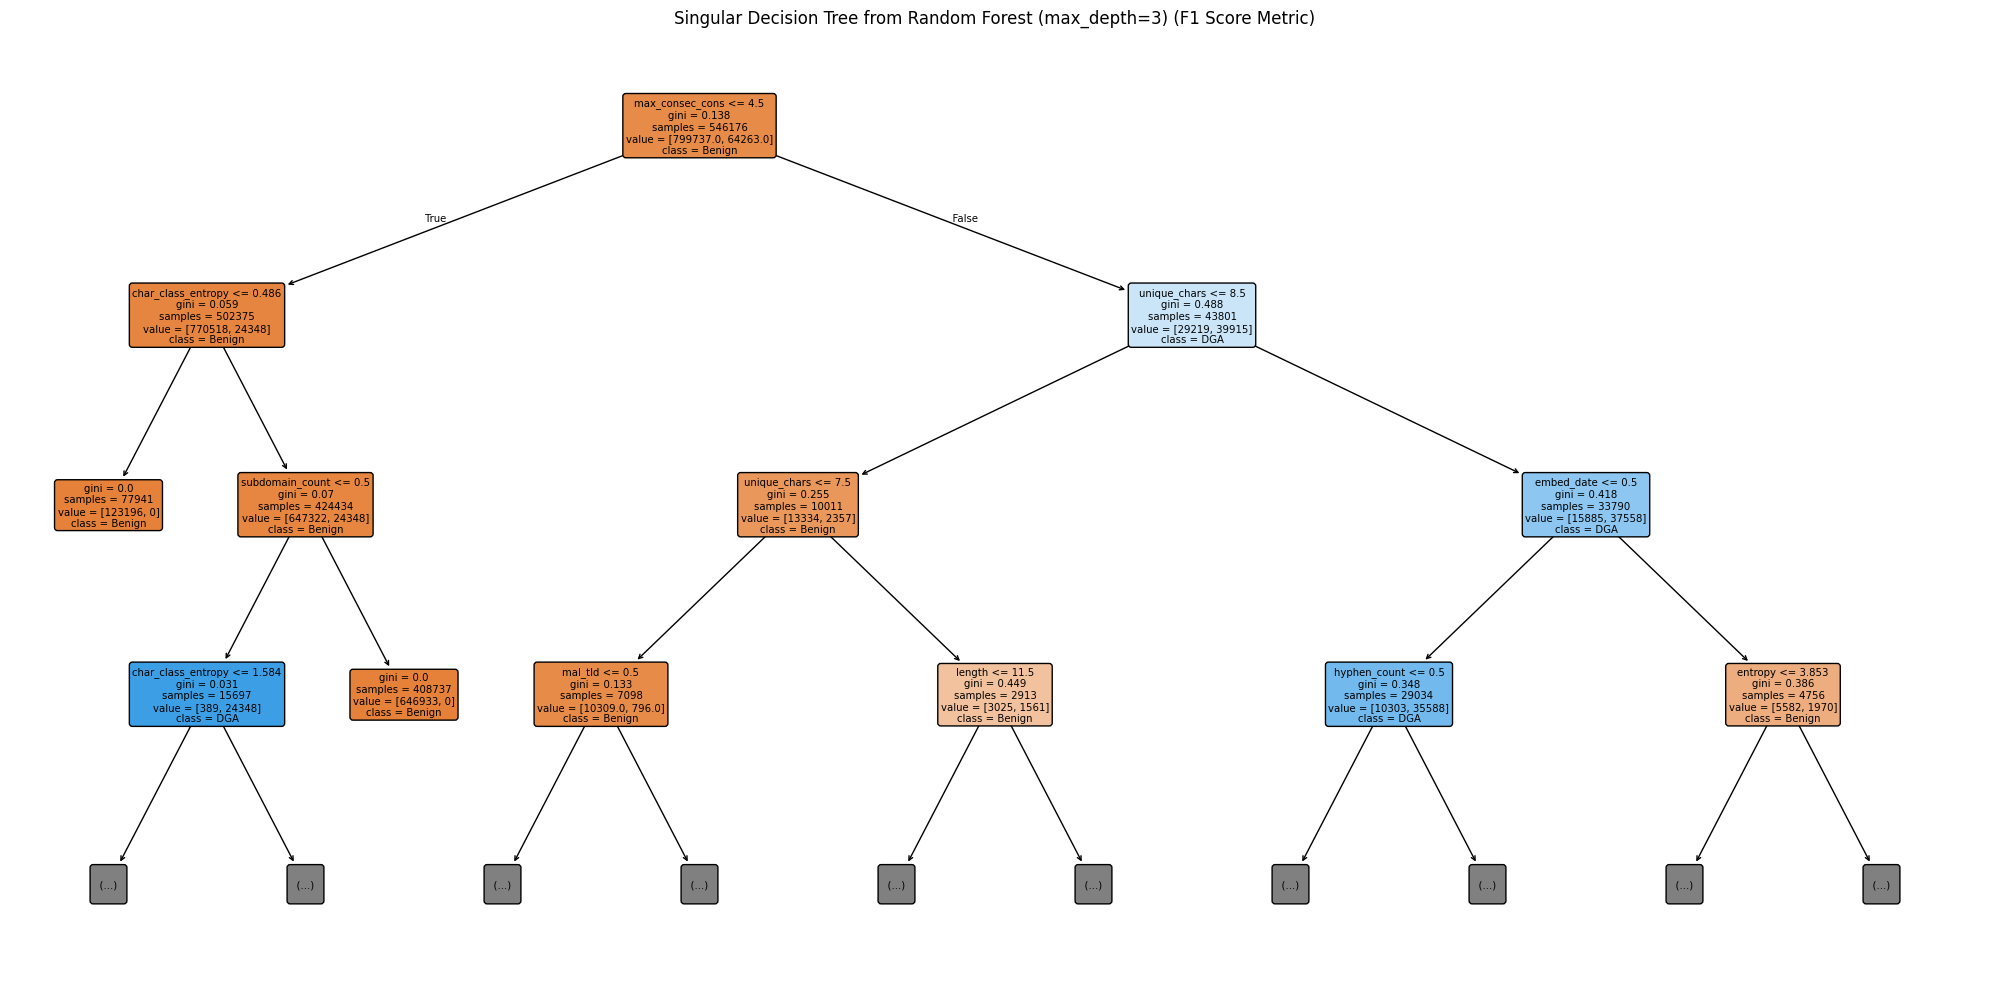

In [35]:
create_best_feature_importance(best_n_acc, "Accuracy", "blue")
create_best_feature_importance(best_n_prec, "Precision", "green")
create_best_feature_importance(best_n_recall, "Recall", "orange")
create_best_feature_importance(best_n_f1, "F1 Score", "red")

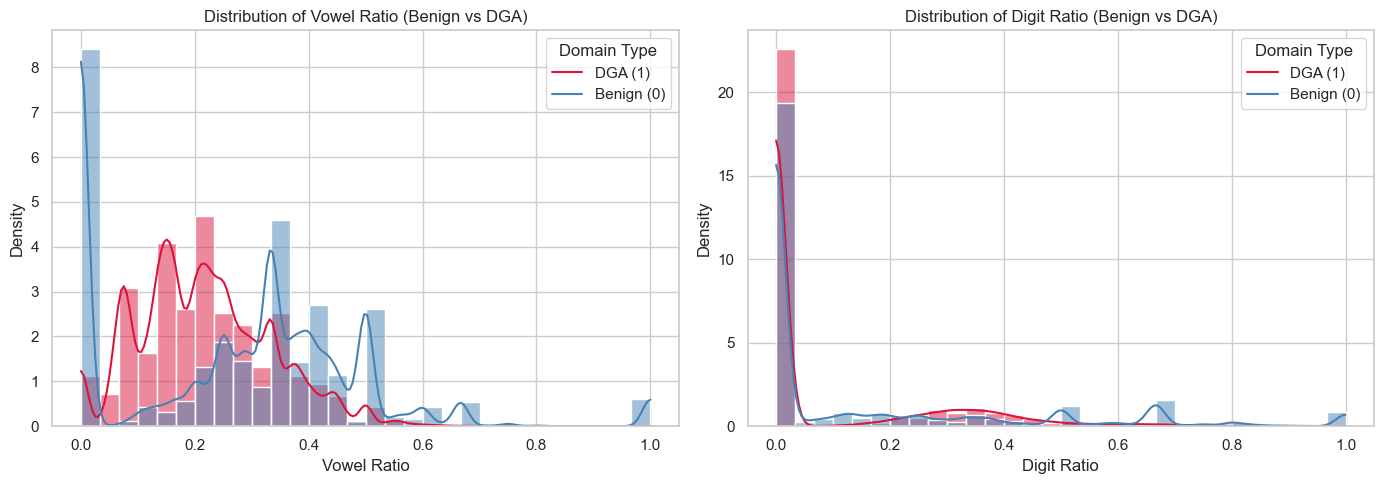

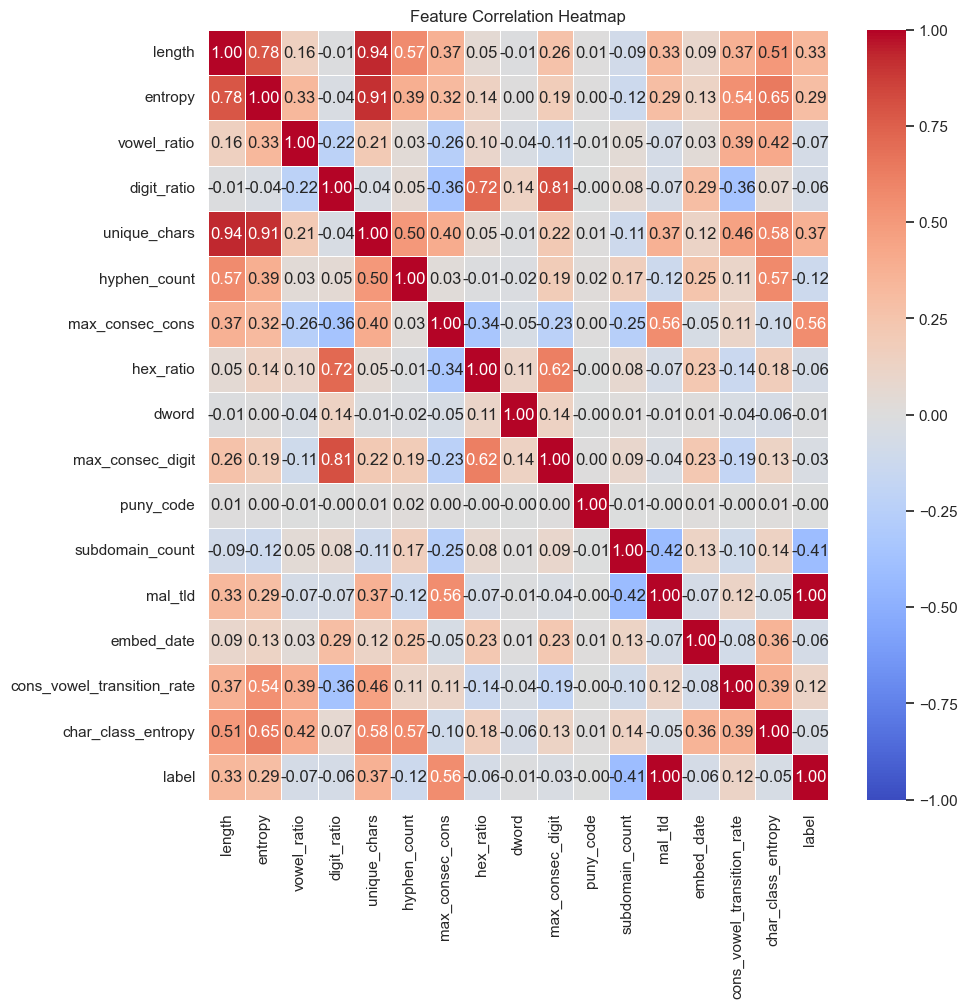

In [36]:
sns.set_theme(style="whitegrid")

# =============================
#Vowel & Digit Ratio
# ================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot the distribution og vowel_ratio
sns.histplot(data=df, x="vowel_ratio", hue="label", bins=30, kde=True,
             palette=["steelblue", "crimson"], ax=axes[0], stat="density", common_norm=False)
axes[0].set_title("Distribution of Vowel Ratio (Benign vs DGA)")
axes[0].set_xlabel("Vowel Ratio")
axes[0].set_ylabel("Density")
axes[0].legend(title="Domain Type", labels=["DGA (1)", "Benign (0)"])

# plot the distribution of digit_ratio
sns.histplot(data=df, x="digit_ratio", hue="label", bins=30, kde=True,
             palette=["steelblue", "crimson"], ax=axes[1], stat="density", common_norm=False)
axes[1].set_title("Distribution of Digit Ratio (Benign vs DGA)")
axes[1].set_xlabel("Digit Ratio")
axes[1].set_ylabel("Density")
axes[1].legend(title="Domain Type", labels=["DGA (1)", "Benign (0)"])

plt.tight_layout()
plt.show()

# =====================================
# Feature Correlation Heatmap
# ==================================
plt.figure(figsize=(10, 10))
# select the characters
features = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "mal_tld", "embed_date", "cons_vowel_transition_rate", "char_class_entropy", "label"]
corr_matrix = df[features].corr()

# plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

Accuracy (n=3):
	False Positive Rate: 0.00000 (0.000%)
	False Negative Rate: 0.00000 (0.000%)
	True Negatives=200188, False Positives=0, False Negatives=0, True Positives=15812

Precision (n=2):
	False Positive Rate: 0.00000 (0.000%)
	False Negative Rate: 0.00013 (0.013%)
	True Negatives=200188, False Positives=0, False Negatives=2, True Positives=15810

Recall (n=3):
	False Positive Rate: 0.00000 (0.000%)
	False Negative Rate: 0.00000 (0.000%)
	True Negatives=200188, False Positives=0, False Negatives=0, True Positives=15812

F1 Score (n=3):
	False Positive Rate: 0.00000 (0.000%)
	False Negative Rate: 0.00000 (0.000%)
	True Negatives=200188, False Positives=0, False Negatives=0, True Positives=15812



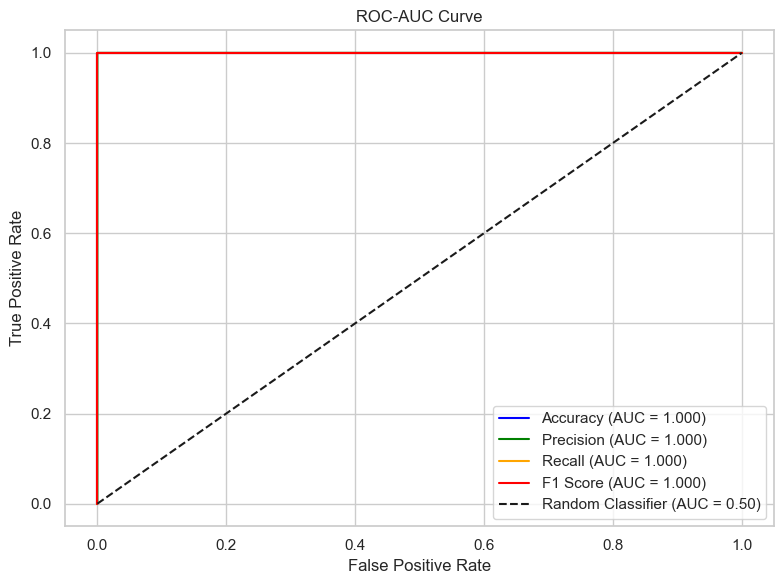

In [37]:
roc_auc_fpr(best_n_acc, best_n_prec, best_n_recall, best_n_f1, X_train, y_train, X_test, y_test)

Testing without Malicious TLDs

Logistic Regression's Accuracy:  0.9996388888888889
Logistic Regression's Precision: 0.9950912523599749
Logistic Regression's Recall:    1.0
Logistic Regression's F1 Score:  0.9975395874077345
Training: 1
Training: 2
Training: 3
Training: 4
Training: 5
Training: 6
Training: 7
Training: 8
Training: 9
Training: 10
Training: 11
Training: 12
Training: 13
Training: 14
Training: 15
Training: 16
Training: 17
Training: 18
Training: 19
Training: 20
Training: 21
Training: 22
Training: 23
Training: 24
Training: 25
Training: 26
Training: 27
Training: 28
Training: 29
Training: 30
Training: 31
Training: 32
Training: 33
Training: 34
Training: 35
Training: 36
Training: 37
Training: 38
Training: 39
Training: 40
Training: 41
Training: 42
Training: 43
Training: 44
Training: 45
Training: 46
Training: 47
Training: 48
Training: 49
Training: 50
Training: 51
Training: 52
Training: 53
Training: 54
Training: 55
Training: 56
Training: 57
Training: 58
Training: 59
Training: 60
Training: 61
Training: 62
Training: 

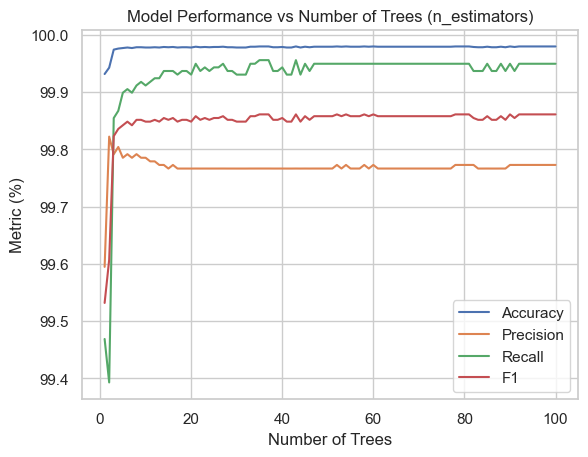

Best n_estimators (Accuracy): 35
Best Accuracy: 0.9997962962962963
Best n_estimators (Precision): 2
Best Precision: 0.9982215447154471
Best n_estimators (Recall): 35
Best Recall: 0.9995572982544902
Best n_estimators (F1): 35
Best F1: 0.9986099703039111


In [38]:
X = df[["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "embed_date", "cons_vowel_transition_rate", "char_class_entropy"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

lr = LogisticRegression(max_iter=1000, random_state=60)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f"Logistic Regression's Accuracy:  {accuracy_score(y_test, y_pred)}")
print(f"Logistic Regression's Precision: {precision_score(y_test, y_pred)}")
print(f"Logistic Regression's Recall:    {recall_score(y_test, y_pred)}")
print(f"Logistic Regression's F1 Score:  {f1_score(y_test, y_pred)}")

scores = {}
num_test_estimators = range(1, 101)
for n in num_test_estimators:
  print("Training:", n)
  clf = RandomForestClassifier(n_estimators=n, random_state=60, n_jobs=-1)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  scores[n] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }
accuracies = [scores[n]["accuracy"] * 100 for n in num_test_estimators]
precisions = [scores[n]["precision"] * 100 for n in num_test_estimators]
recalls = [scores[n]["recall"] * 100 for n in num_test_estimators]
f1s = [scores[n]["f1"] * 100 for n in num_test_estimators]
plt.plot(num_test_estimators, accuracies, label="Accuracy")
plt.plot(num_test_estimators, precisions, label="Precision")
plt.plot(num_test_estimators, recalls, label="Recall")
plt.plot(num_test_estimators, f1s, label="F1")
plt.xlabel("Number of Trees")
plt.ylabel("Metric (%)")
plt.title("Model Performance vs Number of Trees (n_estimators)")
plt.legend()
plt.grid(True)
plt.show()

best_n_acc = max(scores, key=lambda n: scores[n]["accuracy"])
best_score_acc = scores[best_n_acc]["accuracy"]
print("Best n_estimators (Accuracy):", best_n_acc)
print("Best Accuracy:", best_score_acc)

best_n_prec = max(scores, key=lambda n: scores[n]["precision"])
best_score_prec = scores[best_n_prec]["precision"]
print("Best n_estimators (Precision):", best_n_prec)
print("Best Precision:", best_score_prec)

best_n_recall = max(scores, key=lambda n: scores[n]["recall"])
best_score_recall = scores[best_n_recall]["recall"]
print("Best n_estimators (Recall):", best_n_recall)
print("Best Recall:", best_score_recall)

best_n_f1 = max(scores, key=lambda n: scores[n]["f1"])
best_score_f1 = scores[best_n_f1]["f1"]
print("Best n_estimators (F1):", best_n_f1)
print("Best F1:", best_score_f1)

Feature Importance:
subdomain_count               0.636864
max_consec_cons               0.108571
unique_chars                  0.064221
length                        0.052609
char_class_entropy            0.044239
hyphen_count                  0.028385
vowel_ratio                   0.023378
entropy                       0.017430
digit_ratio                   0.009963
hex_ratio                     0.005082
cons_vowel_transition_rate    0.005052
max_consec_digit              0.003025
embed_date                    0.001164
puny_code                     0.000015
dword                         0.000002
dtype: float64


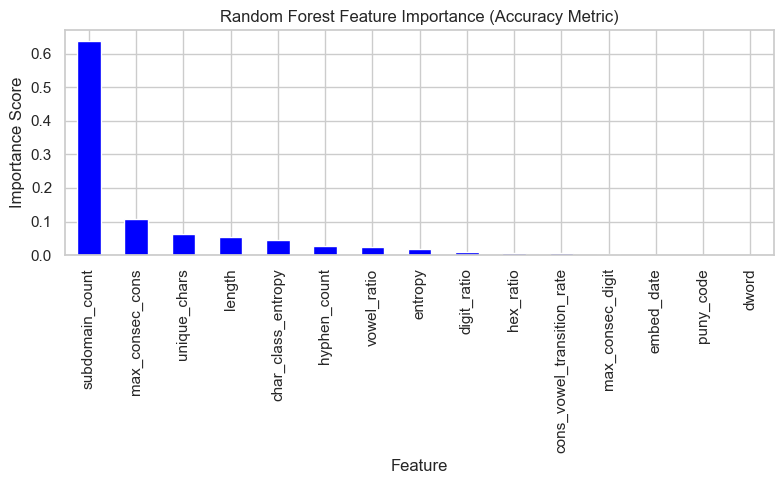

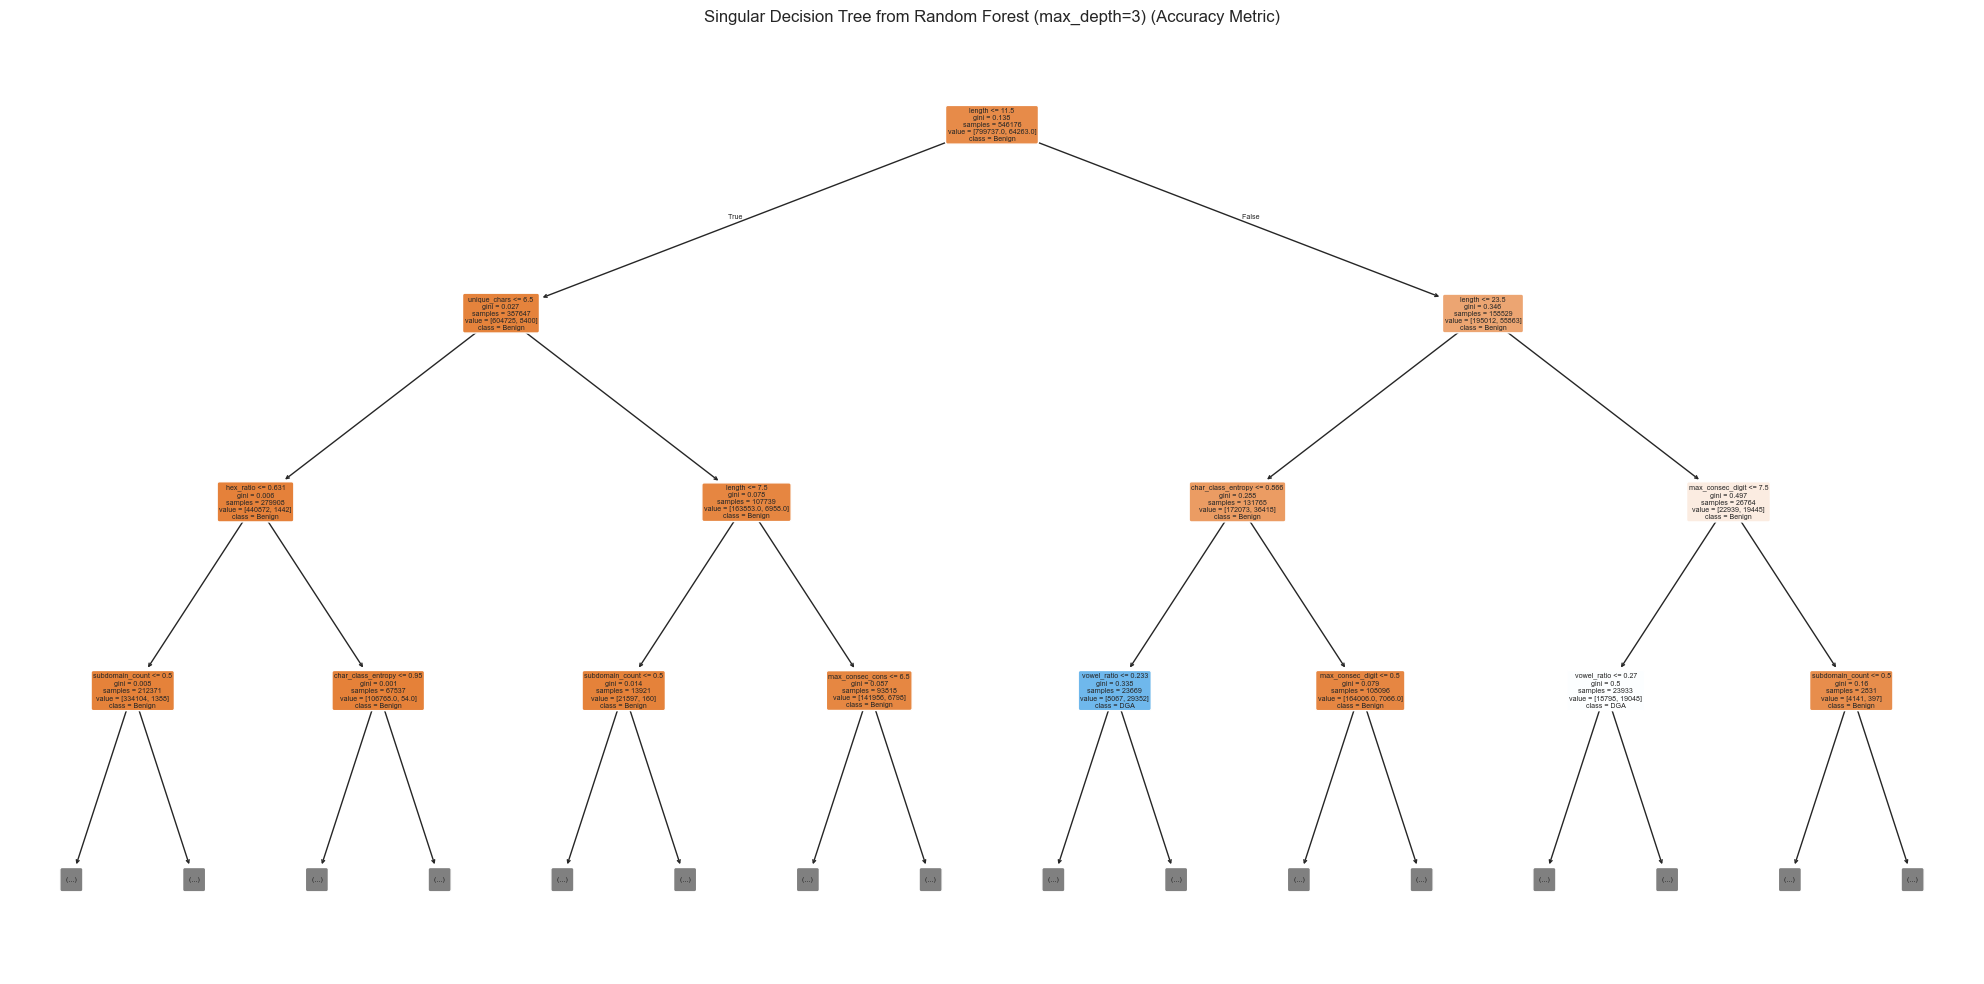

Feature Importance:
subdomain_count               0.565814
char_class_entropy            0.156746
length                        0.097915
unique_chars                  0.063934
hyphen_count                  0.039931
vowel_ratio                   0.032969
max_consec_digit              0.014243
cons_vowel_transition_rate    0.013144
hex_ratio                     0.004500
entropy                       0.004113
max_consec_cons               0.003095
digit_ratio                   0.002248
embed_date                    0.001311
puny_code                     0.000031
dword                         0.000006
dtype: float64


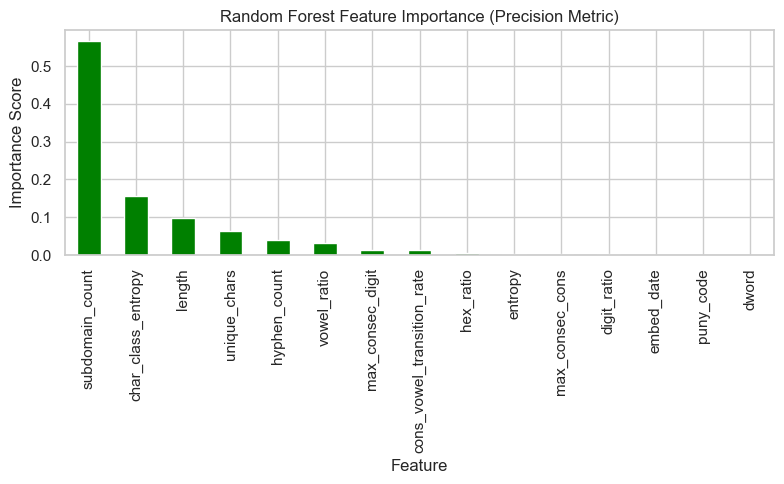

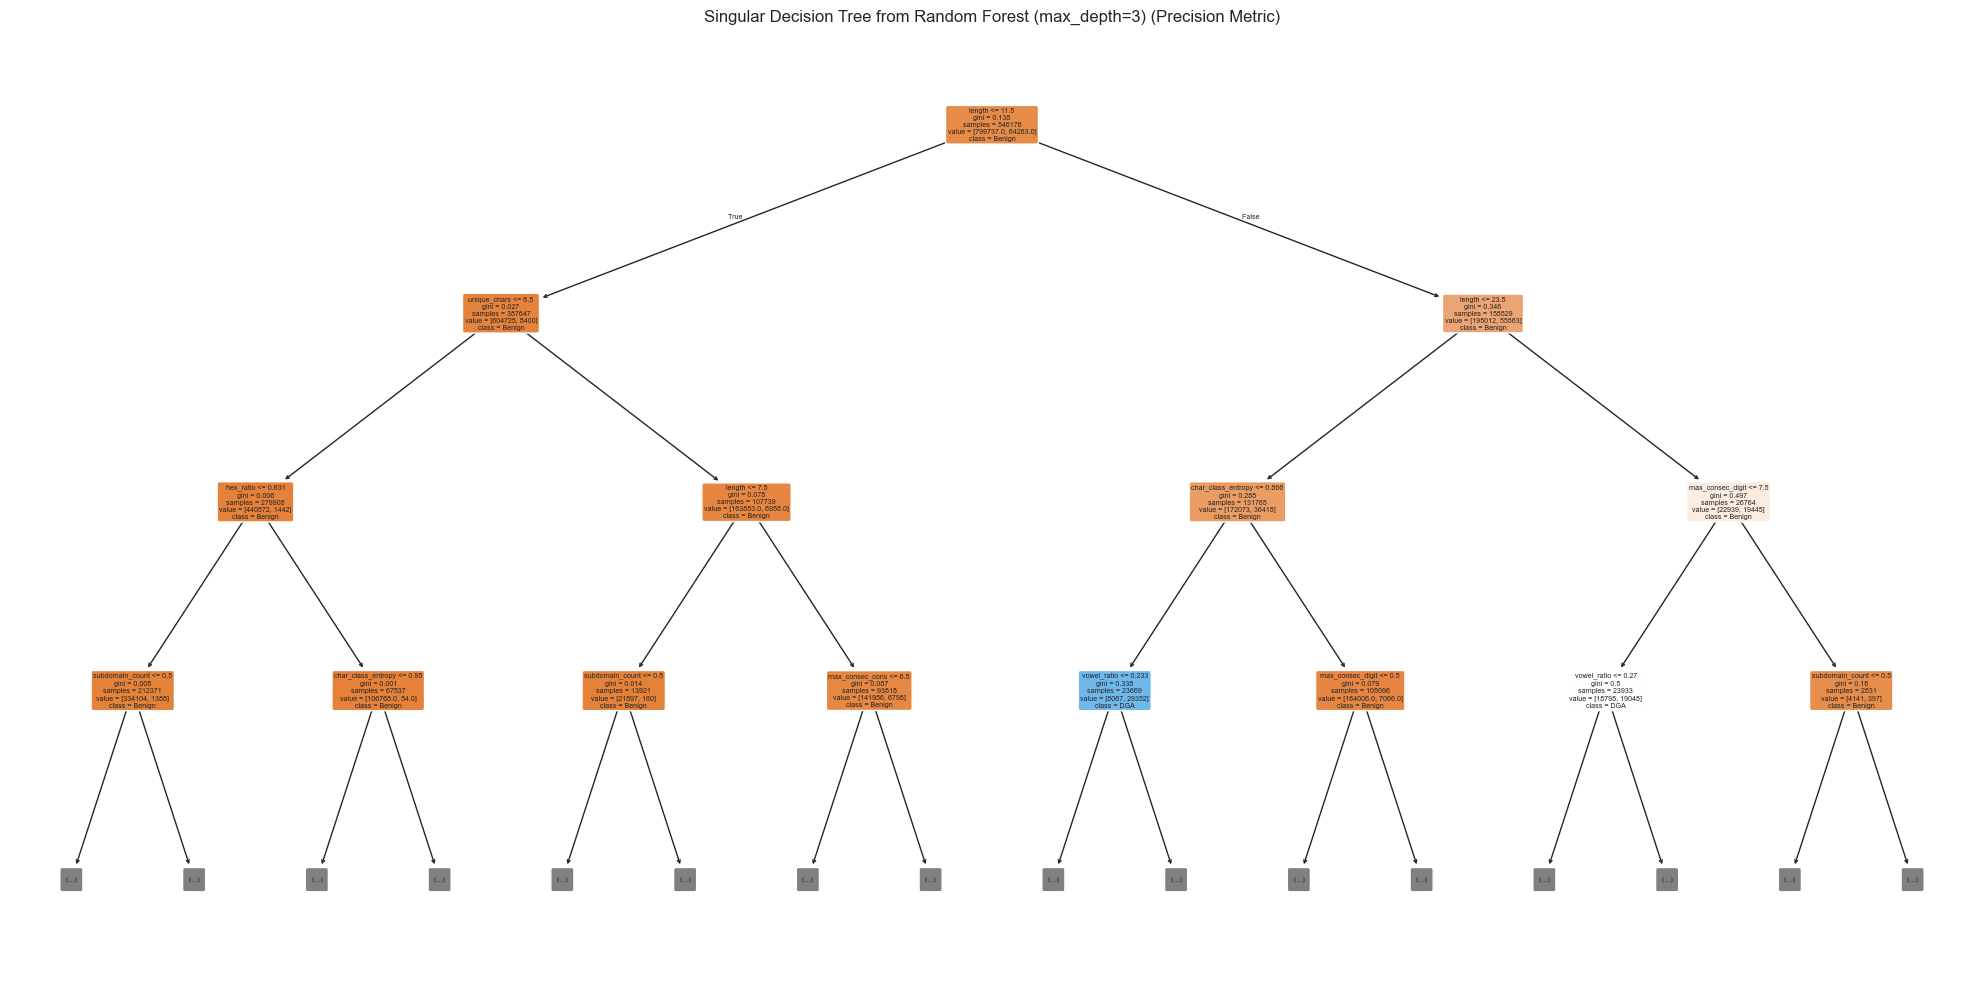

Feature Importance:
subdomain_count               0.636864
max_consec_cons               0.108571
unique_chars                  0.064221
length                        0.052609
char_class_entropy            0.044239
hyphen_count                  0.028385
vowel_ratio                   0.023378
entropy                       0.017430
digit_ratio                   0.009963
hex_ratio                     0.005082
cons_vowel_transition_rate    0.005052
max_consec_digit              0.003025
embed_date                    0.001164
puny_code                     0.000015
dword                         0.000002
dtype: float64


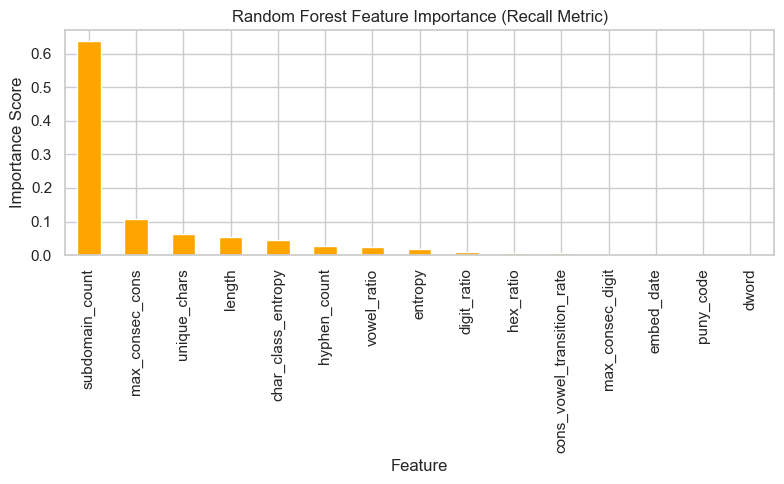

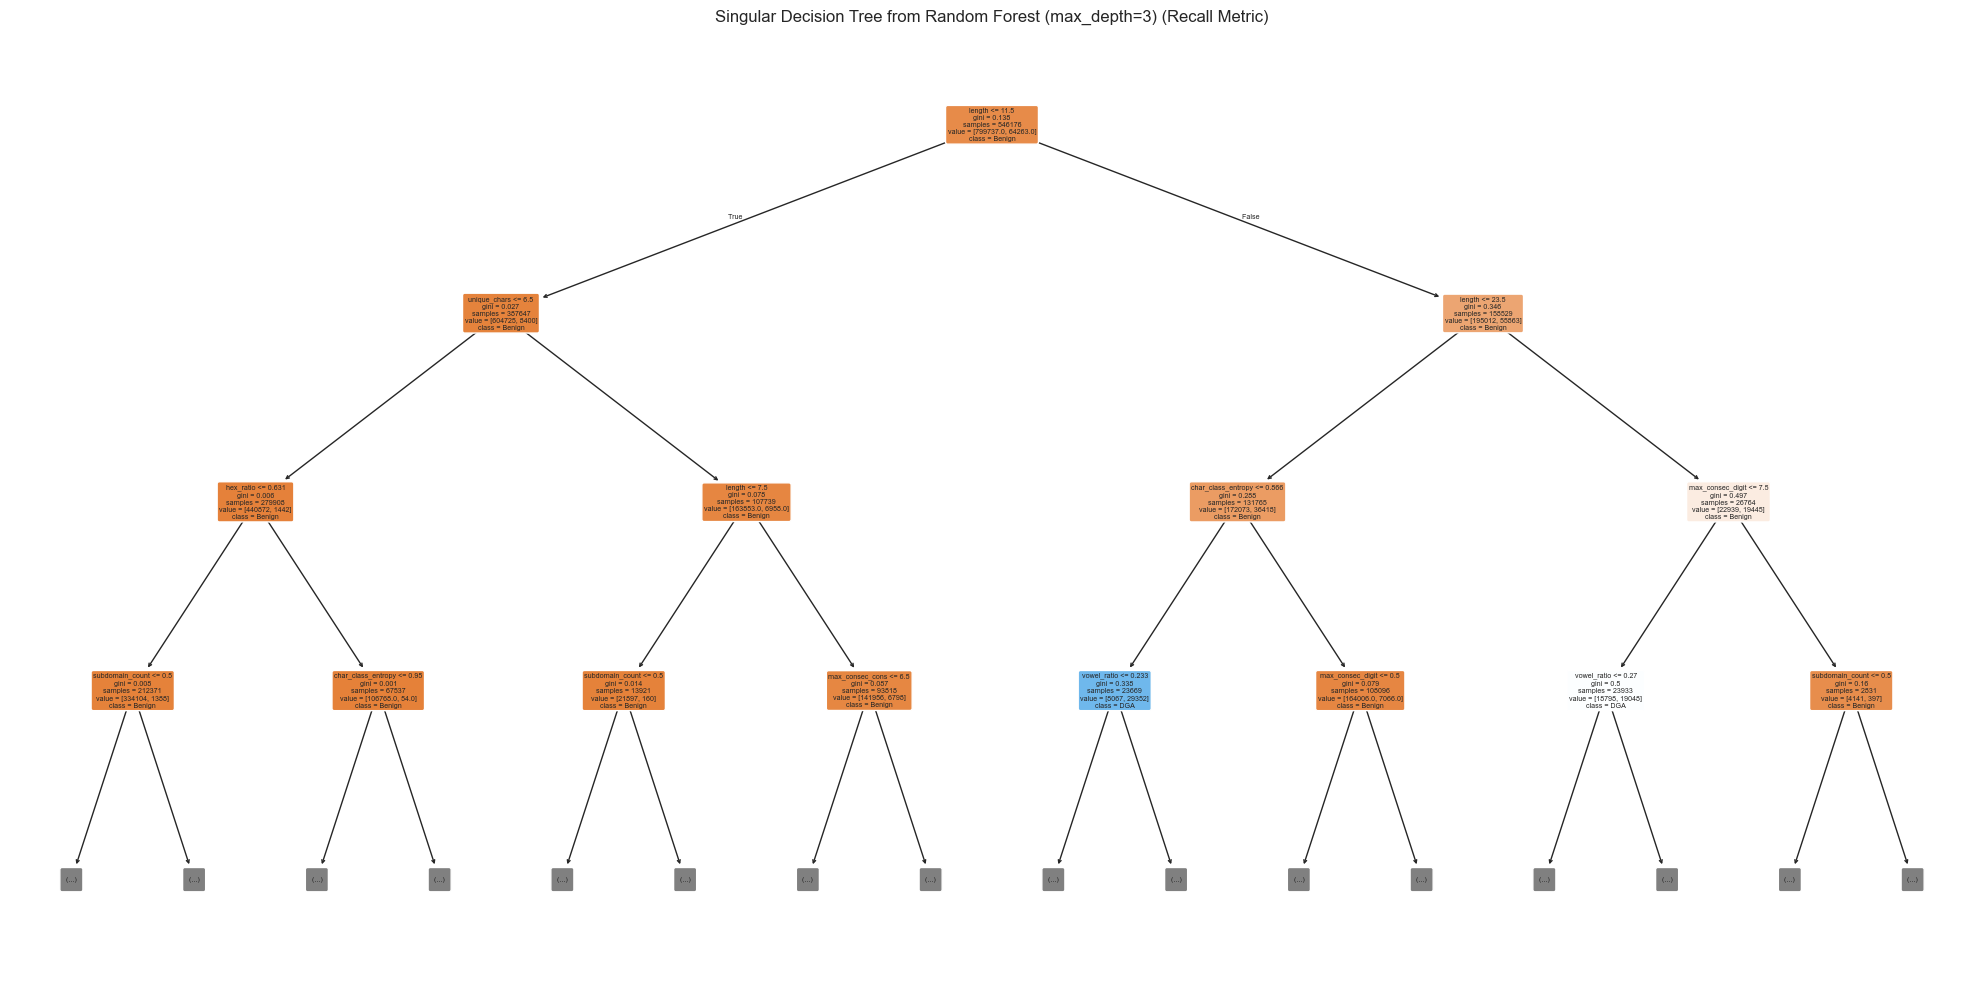

Feature Importance:
subdomain_count               0.636864
max_consec_cons               0.108571
unique_chars                  0.064221
length                        0.052609
char_class_entropy            0.044239
hyphen_count                  0.028385
vowel_ratio                   0.023378
entropy                       0.017430
digit_ratio                   0.009963
hex_ratio                     0.005082
cons_vowel_transition_rate    0.005052
max_consec_digit              0.003025
embed_date                    0.001164
puny_code                     0.000015
dword                         0.000002
dtype: float64


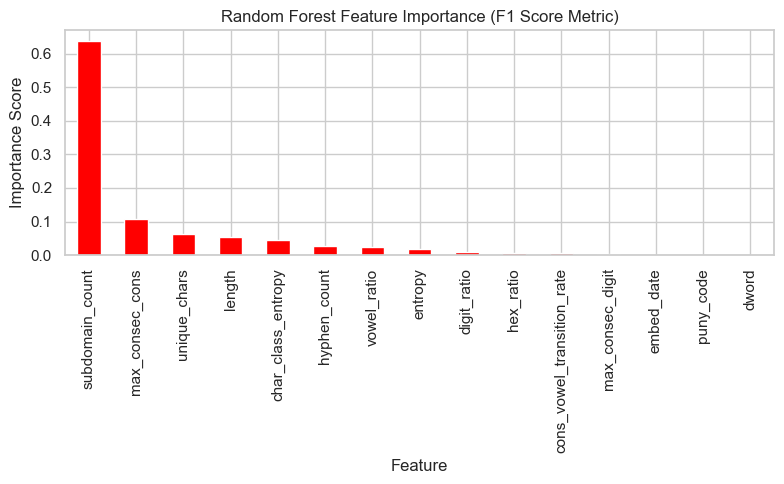

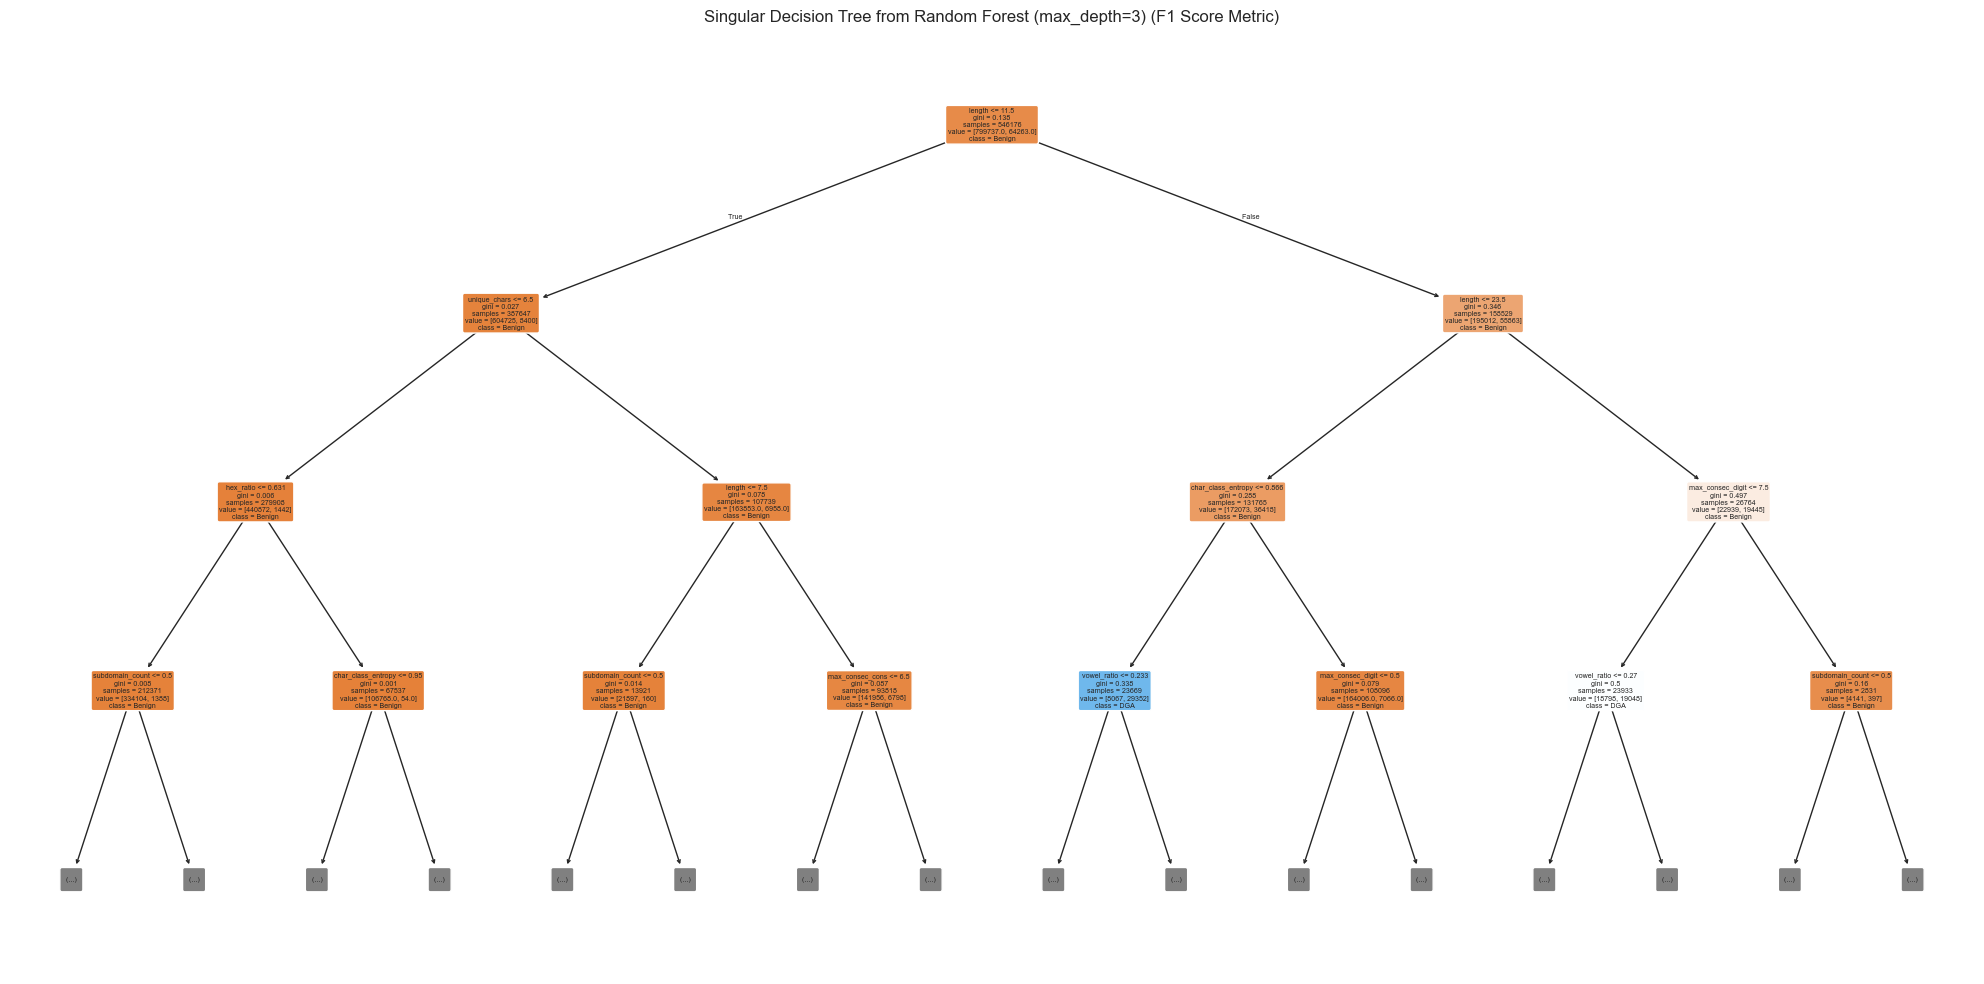

In [39]:
create_best_feature_importance(best_n_acc, "Accuracy", "blue")
create_best_feature_importance(best_n_prec, "Precision", "green")
create_best_feature_importance(best_n_recall, "Recall", "orange")
create_best_feature_importance(best_n_f1, "F1 Score", "red")

Accuracy (n=35):
	False Positive Rate: 0.00018 (0.018%)
	False Negative Rate: 0.00044 (0.044%)
	True Negatives=200151, False Positives=37, False Negatives=7, True Positives=15805

Precision (n=2):
	False Positive Rate: 0.00014 (0.014%)
	False Negative Rate: 0.00607 (0.607%)
	True Negatives=200160, False Positives=28, False Negatives=96, True Positives=15716

Recall (n=35):
	False Positive Rate: 0.00018 (0.018%)
	False Negative Rate: 0.00044 (0.044%)
	True Negatives=200151, False Positives=37, False Negatives=7, True Positives=15805

F1 Score (n=35):
	False Positive Rate: 0.00018 (0.018%)
	False Negative Rate: 0.00044 (0.044%)
	True Negatives=200151, False Positives=37, False Negatives=7, True Positives=15805



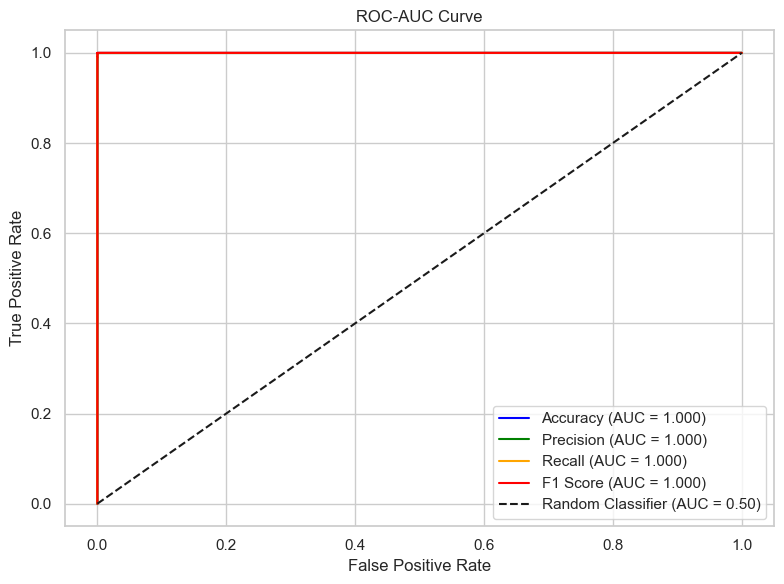

In [40]:
roc_auc_fpr(best_n_acc, best_n_prec, best_n_recall, best_n_f1, X_train, y_train, X_test, y_test)

Find the best combination of features

In [41]:
features = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "mal_tld", "embed_date"]

benign = df[df["label"] == 0].sample(n=25000, random_state=60)
dga = df[df["label"] == 1].sample(n=25000, random_state=60)
df_sample = pd.concat([benign, dga]).sample(frac=1, random_state=60)
# df_sample = df.sample(n=50000, random_state=60)
y = df_sample["label"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=60)
results = []
sample_n_estimators = 20
# test combinations of 3 to 8
for size in range(3, 9):
    for combo in combinations(features, size):
        X_sub = df_sample[list(combo)]
        clf = RandomForestClassifier(n_estimators=sample_n_estimators, random_state=60, n_jobs=-1)
        cv_scores = cross_val_score(clf, X_sub, y, cv=cv, scoring="f1", n_jobs=-1)
        mean_f1 = cv_scores.mean()
        results.append((mean_f1, combo))


results.sort(reverse=True)
print("15 best feature combinations:")
for score, combo in results[:15]:
    print(f"    F1 Score={score} | Length of Features:={len(combo)} | Features: {combo}")

15 best feature combinations:
    F1 Score=1.0 | Length of Features:=5 | Features: ('vowel_ratio', 'unique_chars', 'subdomain_count', 'mal_tld', 'embed_date')
    F1 Score=1.0 | Length of Features:=4 | Features: ('vowel_ratio', 'unique_chars', 'subdomain_count', 'mal_tld')
    F1 Score=1.0 | Length of Features:=6 | Features: ('vowel_ratio', 'unique_chars', 'puny_code', 'subdomain_count', 'mal_tld', 'embed_date')
    F1 Score=1.0 | Length of Features:=5 | Features: ('vowel_ratio', 'unique_chars', 'puny_code', 'subdomain_count', 'mal_tld')
    F1 Score=1.0 | Length of Features:=5 | Features: ('vowel_ratio', 'unique_chars', 'puny_code', 'mal_tld', 'embed_date')
    F1 Score=1.0 | Length of Features:=4 | Features: ('vowel_ratio', 'unique_chars', 'puny_code', 'mal_tld')
    F1 Score=1.0 | Length of Features:=6 | Features: ('vowel_ratio', 'unique_chars', 'max_consec_digit', 'subdomain_count', 'mal_tld', 'embed_date')
    F1 Score=1.0 | Length of Features:=5 | Features: ('vowel_ratio', 'uniqu

In [42]:
for score, combo in results:
    print(f"    F1 Score={score} | Length of Features:={len(combo)} | Features: {combo}")

    F1 Score=1.0 | Length of Features:=5 | Features: ('vowel_ratio', 'unique_chars', 'subdomain_count', 'mal_tld', 'embed_date')
    F1 Score=1.0 | Length of Features:=4 | Features: ('vowel_ratio', 'unique_chars', 'subdomain_count', 'mal_tld')
    F1 Score=1.0 | Length of Features:=6 | Features: ('vowel_ratio', 'unique_chars', 'puny_code', 'subdomain_count', 'mal_tld', 'embed_date')
    F1 Score=1.0 | Length of Features:=5 | Features: ('vowel_ratio', 'unique_chars', 'puny_code', 'subdomain_count', 'mal_tld')
    F1 Score=1.0 | Length of Features:=5 | Features: ('vowel_ratio', 'unique_chars', 'puny_code', 'mal_tld', 'embed_date')
    F1 Score=1.0 | Length of Features:=4 | Features: ('vowel_ratio', 'unique_chars', 'puny_code', 'mal_tld')
    F1 Score=1.0 | Length of Features:=6 | Features: ('vowel_ratio', 'unique_chars', 'max_consec_digit', 'subdomain_count', 'mal_tld', 'embed_date')
    F1 Score=1.0 | Length of Features:=5 | Features: ('vowel_ratio', 'unique_chars', 'max_consec_digit', 

Logistic Regression's Accuracy:  0.9998981481481481
Logistic Regression's Precision: 0.9986105848174813
Logistic Regression's Recall:    1.0
Logistic Regression's F1 Score:  0.9993048094545914
Training: 1
Training: 2
Training: 3
Training: 4
Training: 5
Training: 6
Training: 7
Training: 8
Training: 9
Training: 10
Training: 11
Training: 12
Training: 13
Training: 14
Training: 15
Training: 16
Training: 17
Training: 18
Training: 19
Training: 20
Training: 21
Training: 22
Training: 23
Training: 24
Training: 25
Training: 26
Training: 27
Training: 28
Training: 29
Training: 30
Training: 31
Training: 32
Training: 33
Training: 34
Training: 35
Training: 36
Training: 37
Training: 38
Training: 39
Training: 40
Training: 41
Training: 42
Training: 43
Training: 44
Training: 45
Training: 46
Training: 47
Training: 48
Training: 49
Training: 50
Training: 51
Training: 52
Training: 53
Training: 54
Training: 55
Training: 56
Training: 57
Training: 58
Training: 59
Training: 60
Training: 61
Training: 62
Training: 

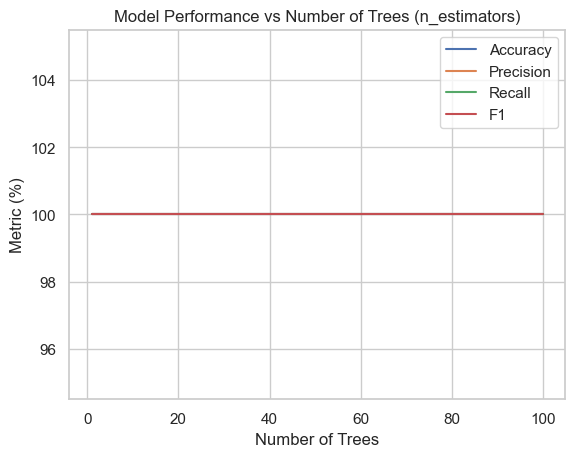

Best n_estimators (Accuracy): 1
Best Accuracy: 1.0
Best n_estimators (Precision): 1
Best Precision: 1.0
Best n_estimators (Recall): 1
Best Recall: 1.0
Best n_estimators (F1): 1
Best F1: 1.0


In [43]:
best_score, best_combo = results[0]
X_best = df[list(best_combo)]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=60)

lr = LogisticRegression(max_iter=1000, random_state=60)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f"Logistic Regression's Accuracy:  {accuracy_score(y_test, y_pred)}")
print(f"Logistic Regression's Precision: {precision_score(y_test, y_pred)}")
print(f"Logistic Regression's Recall:    {recall_score(y_test, y_pred)}")
print(f"Logistic Regression's F1 Score:  {f1_score(y_test, y_pred)}")

scores = {}
num_test_estimators = range(1, 101)
for n in num_test_estimators:
  print("Training:", n)
  clf = RandomForestClassifier(n_estimators=n, random_state=60, n_jobs=-1)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  scores[n] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }
accuracies = [scores[n]["accuracy"] * 100 for n in num_test_estimators]
precisions = [scores[n]["precision"] * 100 for n in num_test_estimators]
recalls = [scores[n]["recall"] * 100 for n in num_test_estimators]
f1s = [scores[n]["f1"] * 100 for n in num_test_estimators]
plt.plot(num_test_estimators, accuracies, label="Accuracy")
plt.plot(num_test_estimators, precisions, label="Precision")
plt.plot(num_test_estimators, recalls, label="Recall")
plt.plot(num_test_estimators, f1s, label="F1")
plt.xlabel("Number of Trees")
plt.ylabel("Metric (%)")
plt.title("Model Performance vs Number of Trees (n_estimators)")
plt.legend()
plt.grid(True)
plt.show()

best_n_acc = max(scores, key=lambda n: scores[n]["accuracy"])
best_score_acc = scores[best_n_acc]["accuracy"]
print("Best n_estimators (Accuracy):", best_n_acc)
print("Best Accuracy:", best_score_acc)

best_n_prec = max(scores, key=lambda n: scores[n]["precision"])
best_score_prec = scores[best_n_prec]["precision"]
print("Best n_estimators (Precision):", best_n_prec)
print("Best Precision:", best_score_prec)

best_n_recall = max(scores, key=lambda n: scores[n]["recall"])
best_score_recall = scores[best_n_recall]["recall"]
print("Best n_estimators (Recall):", best_n_recall)
print("Best Recall:", best_score_recall)

best_n_f1 = max(scores, key=lambda n: scores[n]["f1"])
best_score_f1 = scores[best_n_f1]["f1"]
print("Best n_estimators (F1):", best_n_f1)
print("Best F1:", best_score_f1)

In [44]:
def create_best_feature_importance(best_n, ver, color):
    best_clf = RandomForestClassifier(n_estimators=best_n, random_state=60)
    best_clf.fit(X_train, y_train)
    feature_importance = pd.Series(best_clf.feature_importances_, index=X_best.columns).sort_values(ascending=False)
    print("Feature Importance:\n" + str(feature_importance))
    plt.figure(figsize=(8,5))
    feature_importance.plot(kind="bar", color=color)
    plt.xlabel("Feature")
    plt.ylabel("Importance Score")
    plt.title(f"Random Forest Feature Importance ({ver} Metric)")
    # plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    single_tree = best_clf.estimators_[0]
    fig, ax = plt.subplots(figsize=(20, 10))
    plot_tree(
        single_tree,
        feature_names=X_best.columns.tolist(),
        class_names=["Benign", "DGA"],
        filled=True,
        rounded=True,
        max_depth=3,
        ax=ax
    )
    plt.title(f"Singular Decision Tree from Random Forest (max_depth=3) ({ver} Metric)")
    plt.tight_layout()
    plt.show()

Feature Importance:
subdomain_count    0.990832
mal_tld            0.009168
vowel_ratio        0.000000
unique_chars       0.000000
embed_date         0.000000
dtype: float64


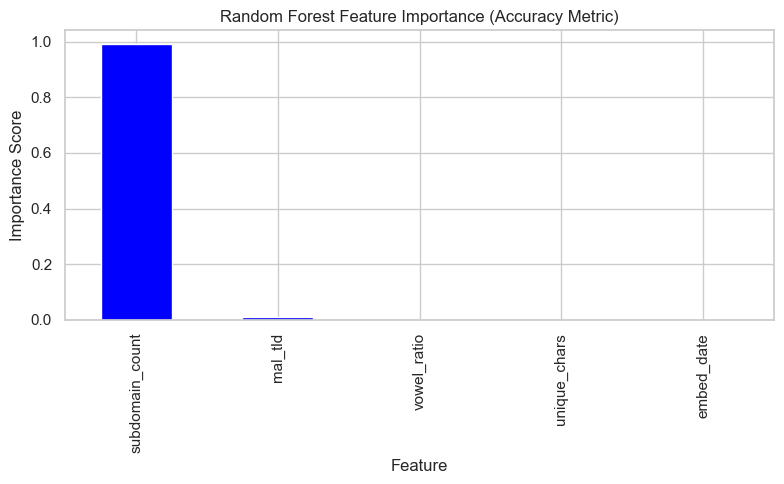

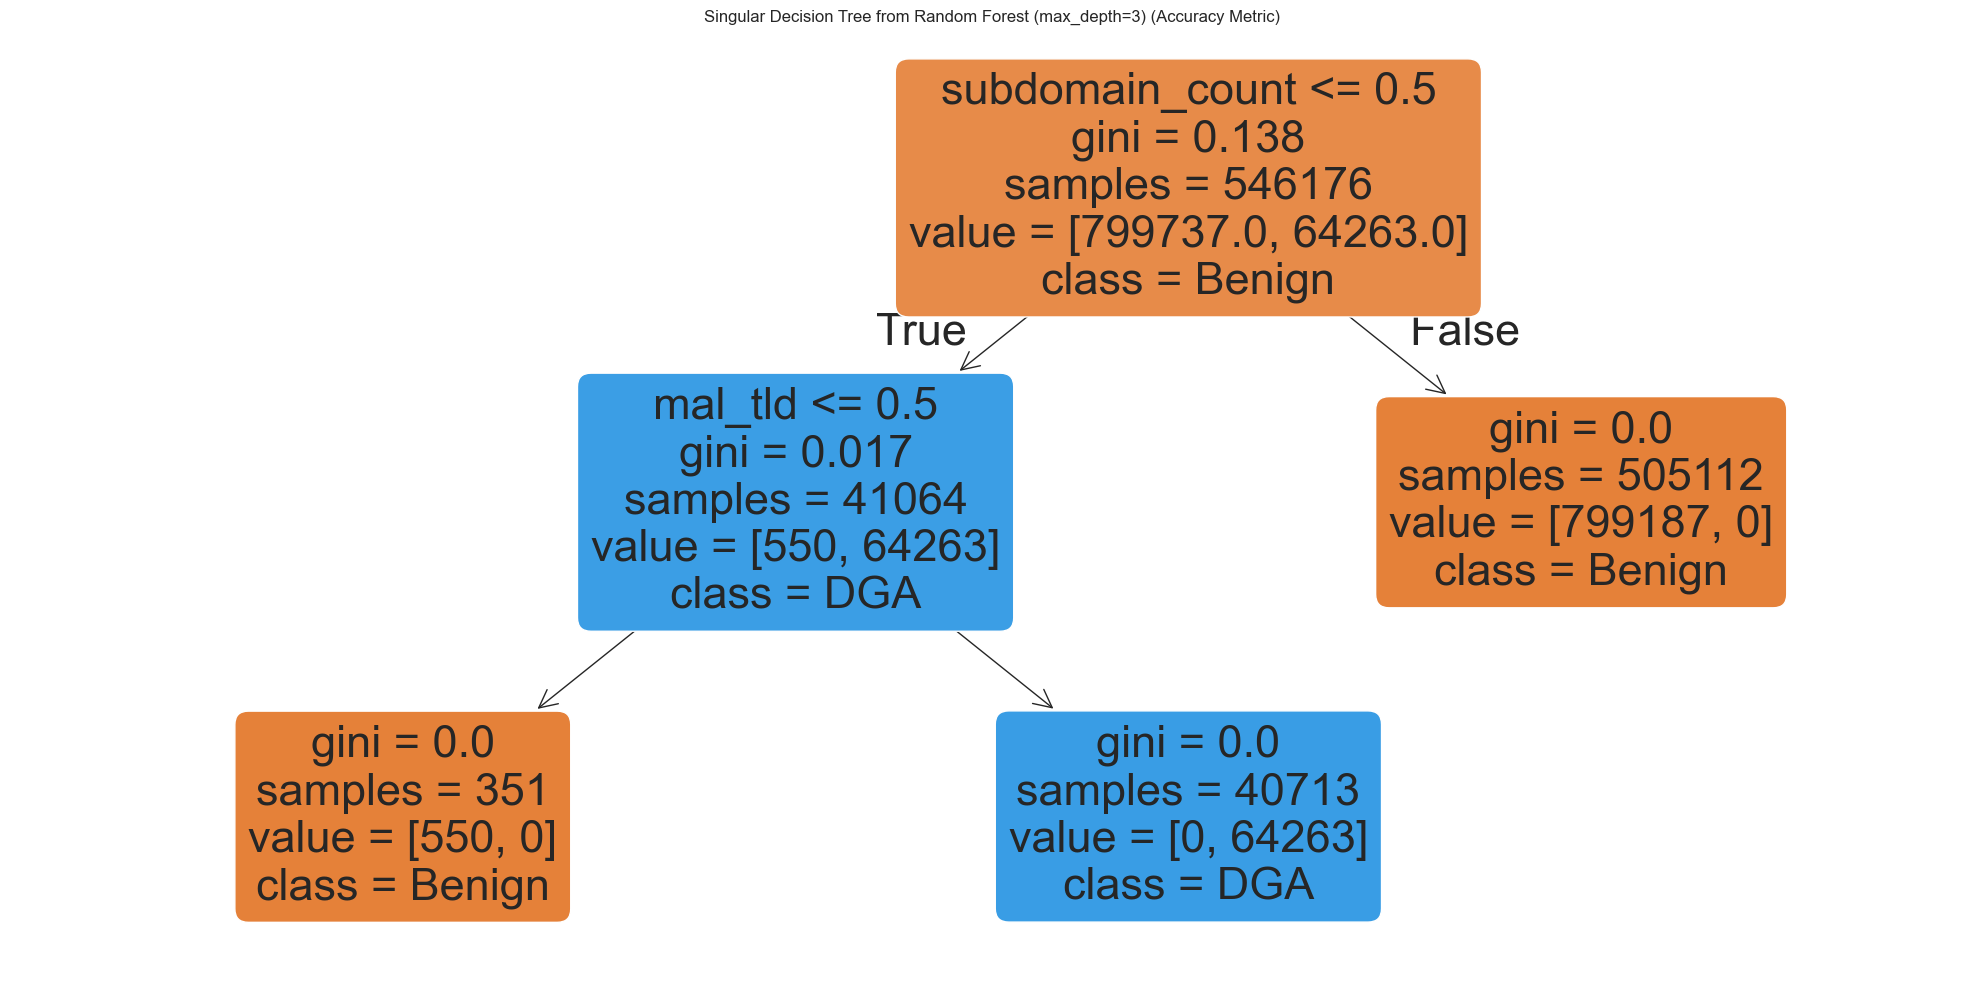

Feature Importance:
subdomain_count    0.990832
mal_tld            0.009168
vowel_ratio        0.000000
unique_chars       0.000000
embed_date         0.000000
dtype: float64


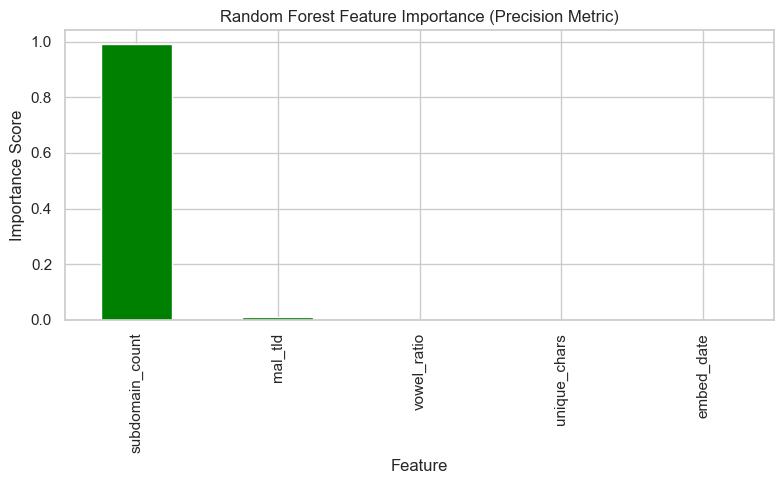

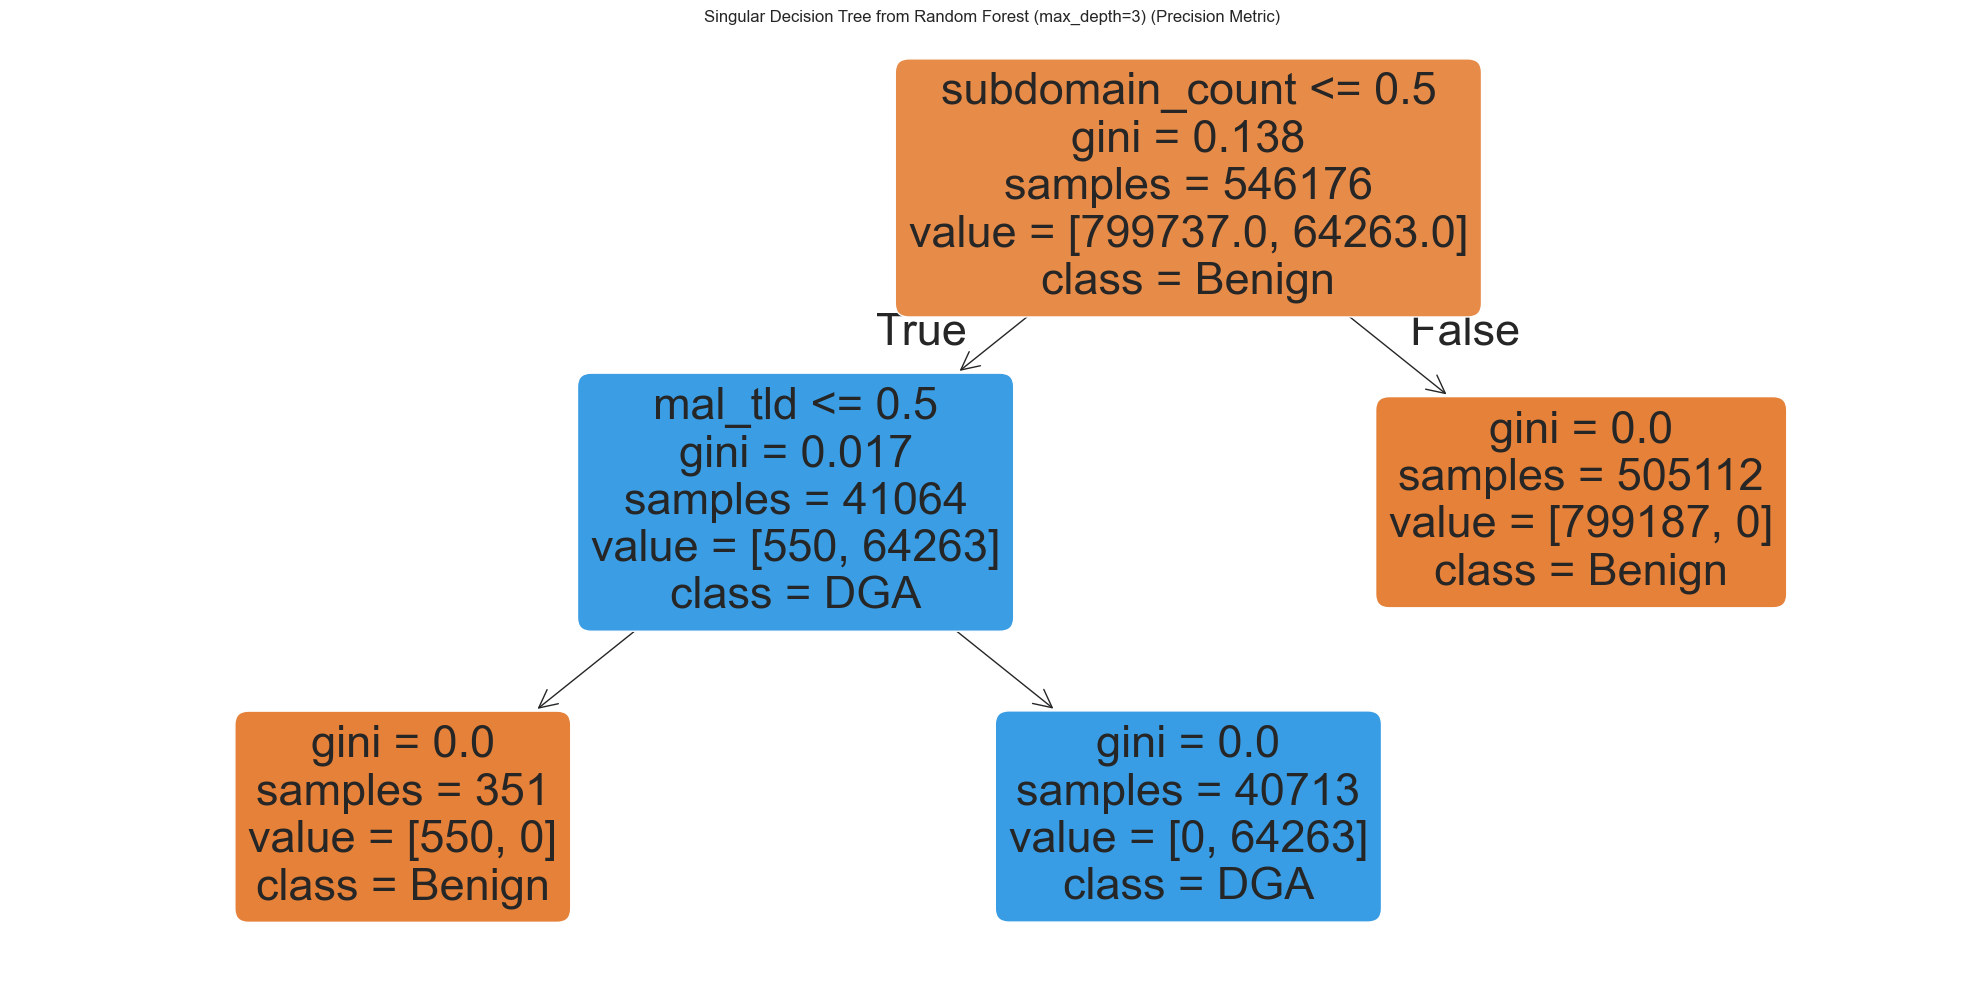

Feature Importance:
subdomain_count    0.990832
mal_tld            0.009168
vowel_ratio        0.000000
unique_chars       0.000000
embed_date         0.000000
dtype: float64


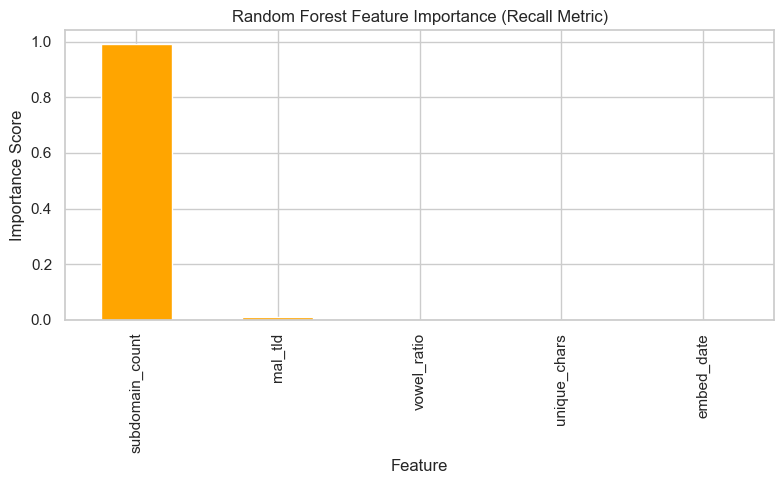

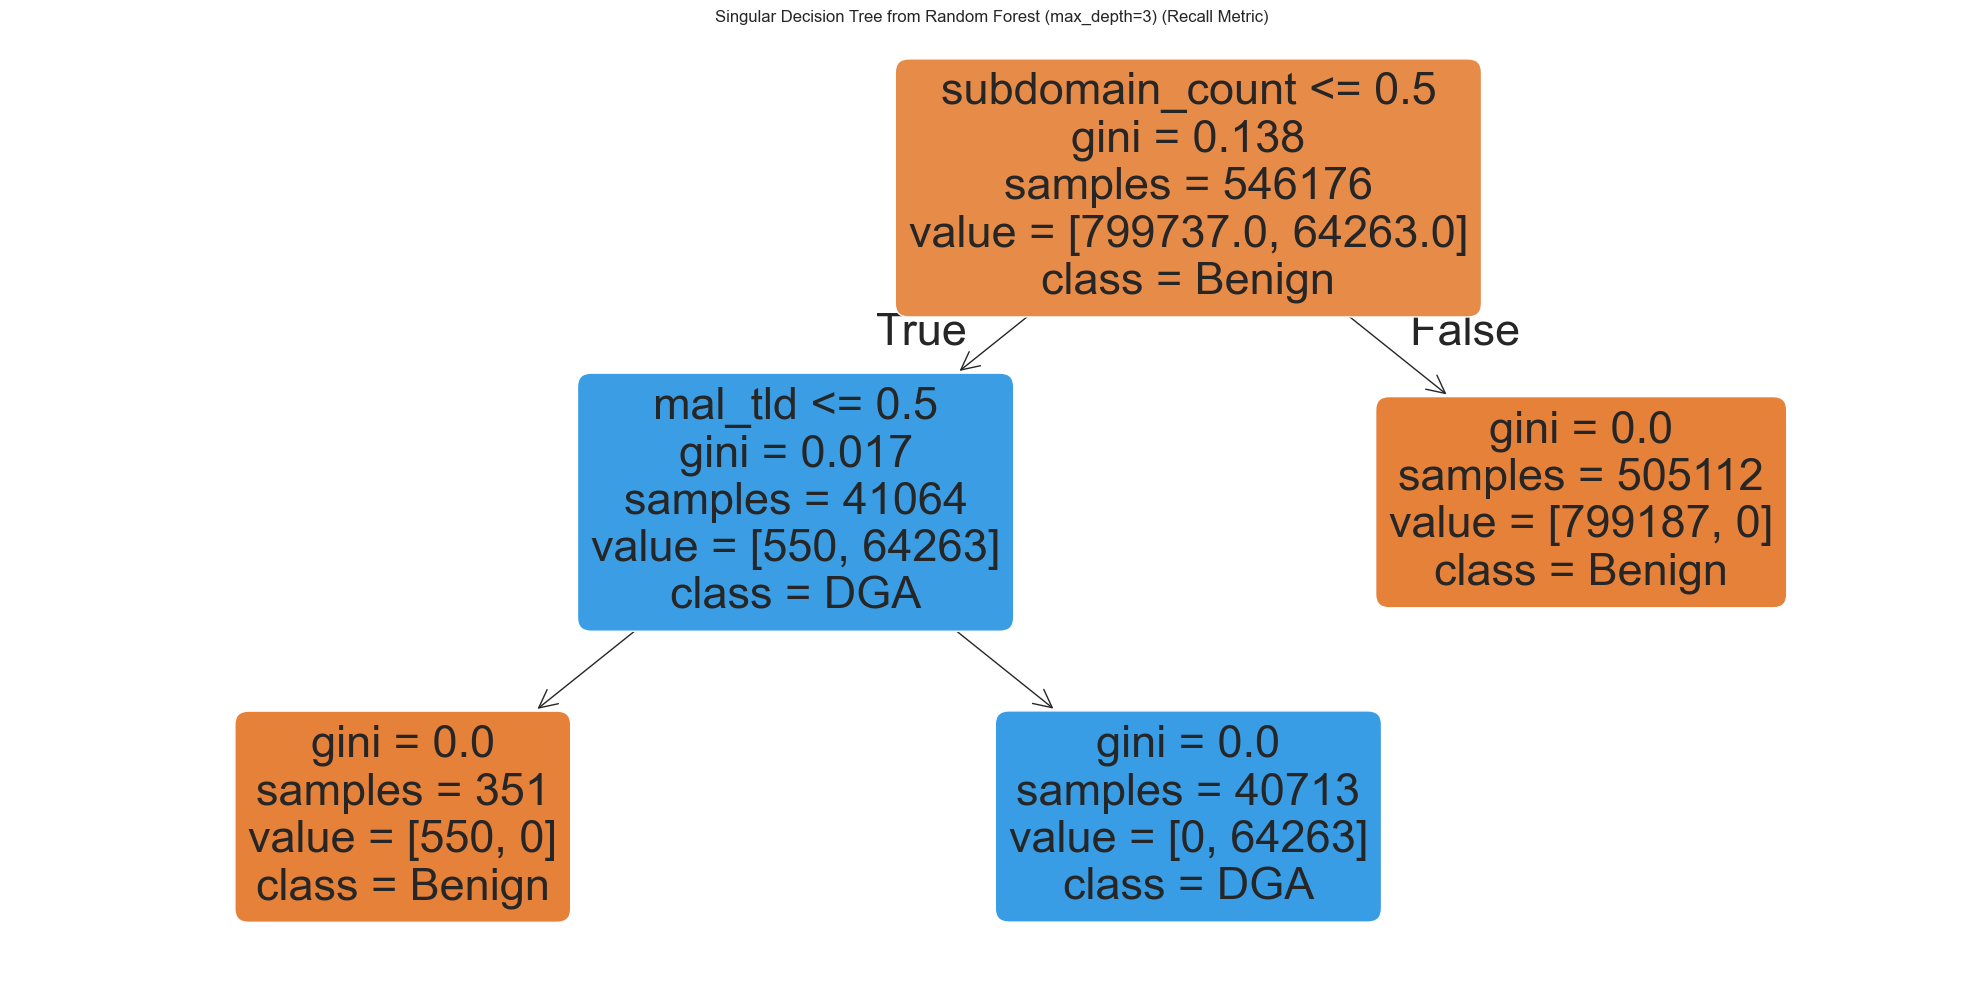

Feature Importance:
subdomain_count    0.990832
mal_tld            0.009168
vowel_ratio        0.000000
unique_chars       0.000000
embed_date         0.000000
dtype: float64


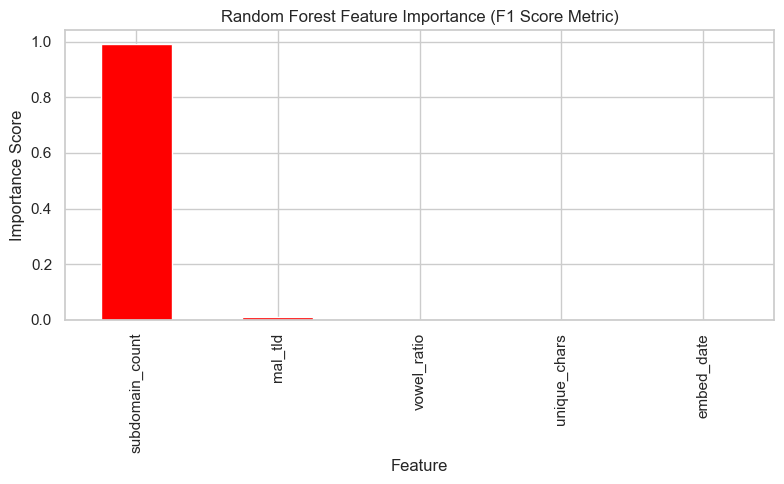

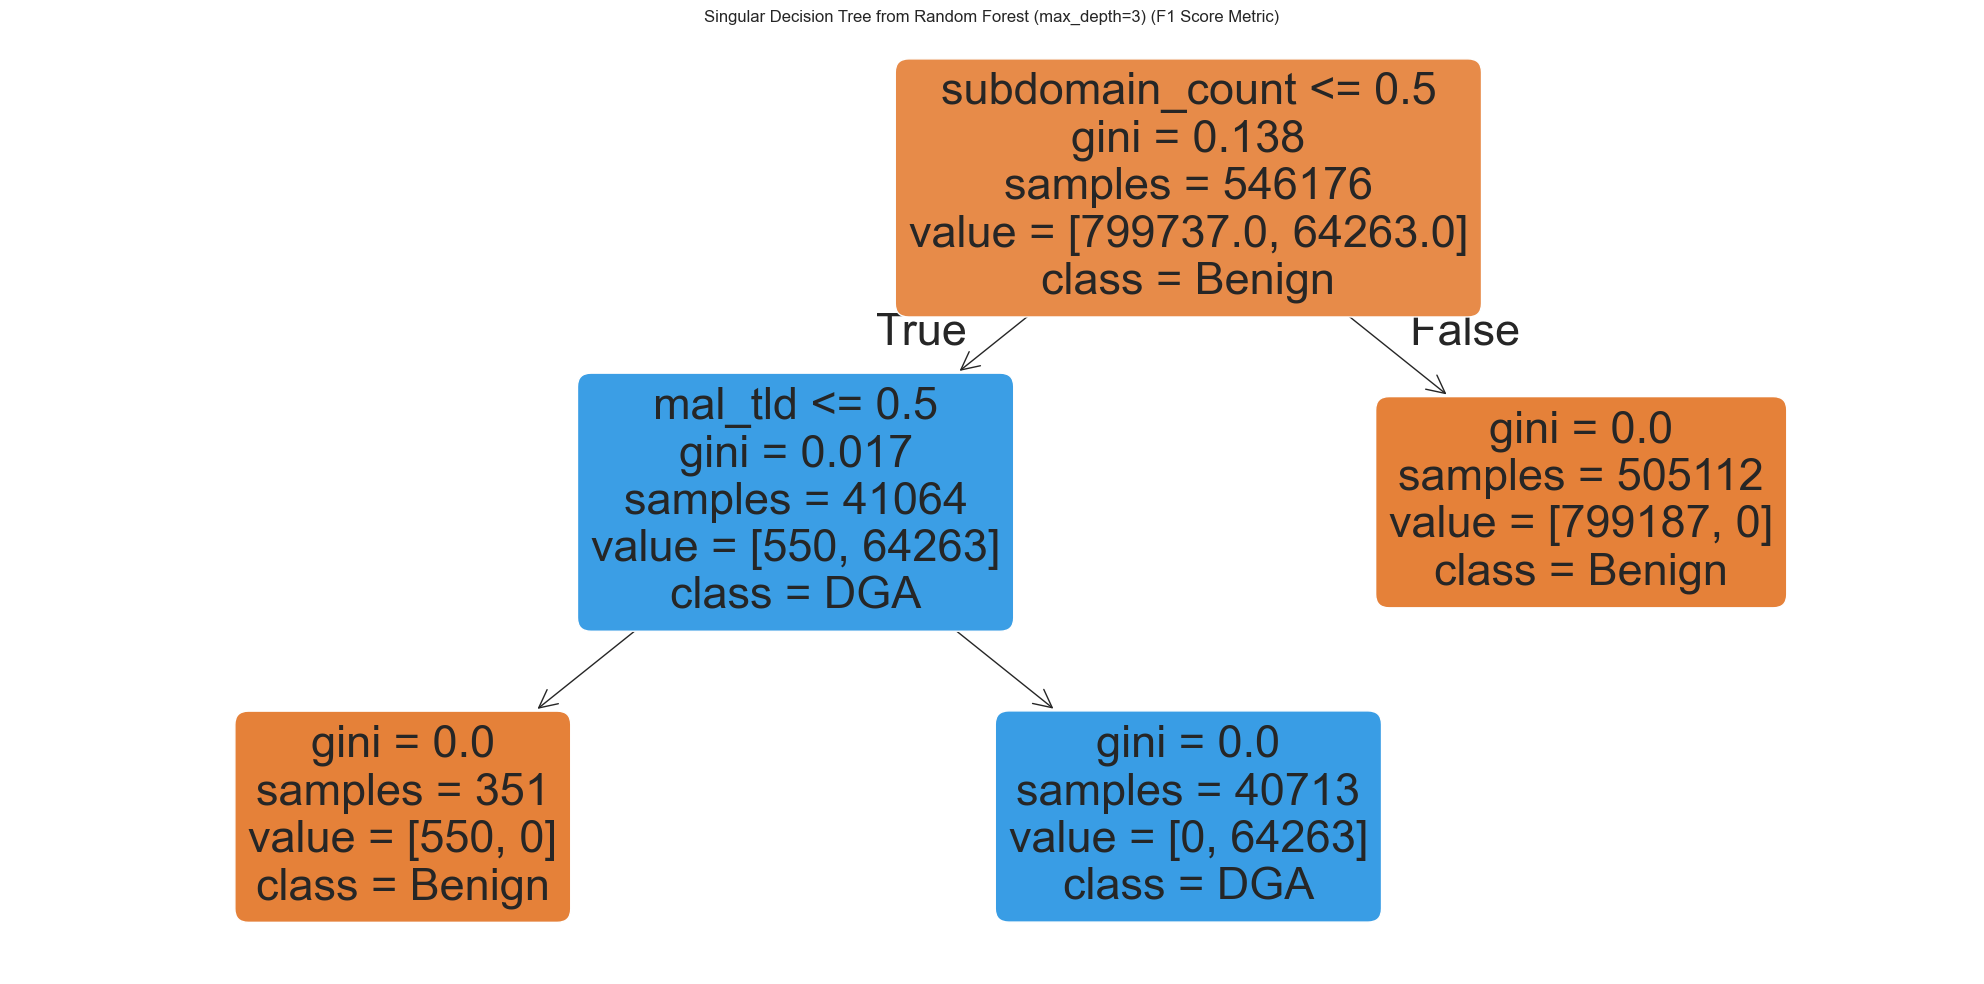

In [45]:
create_best_feature_importance(best_n_acc, "Accuracy", "blue")
create_best_feature_importance(best_n_prec, "Precision", "green")
create_best_feature_importance(best_n_recall, "Recall", "orange")
create_best_feature_importance(best_n_f1, "F1 Score", "red")

Accuracy (n=1):
	False Positive Rate: 0.00000 (0.000%)
	False Negative Rate: 0.00000 (0.000%)
	True Negatives=200188, False Positives=0, False Negatives=0, True Positives=15812

Precision (n=1):
	False Positive Rate: 0.00000 (0.000%)
	False Negative Rate: 0.00000 (0.000%)
	True Negatives=200188, False Positives=0, False Negatives=0, True Positives=15812

Recall (n=1):
	False Positive Rate: 0.00000 (0.000%)
	False Negative Rate: 0.00000 (0.000%)
	True Negatives=200188, False Positives=0, False Negatives=0, True Positives=15812

F1 Score (n=1):
	False Positive Rate: 0.00000 (0.000%)
	False Negative Rate: 0.00000 (0.000%)
	True Negatives=200188, False Positives=0, False Negatives=0, True Positives=15812



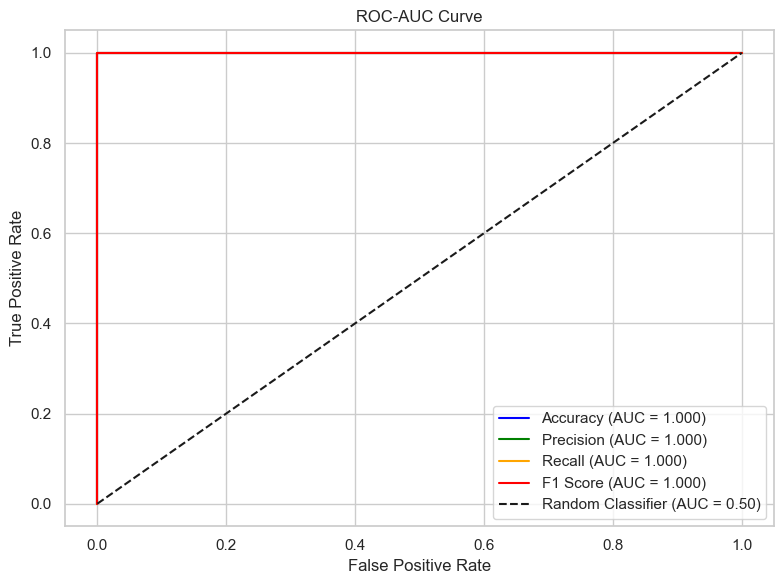

In [46]:
roc_auc_fpr(best_n_acc, best_n_prec, best_n_recall, best_n_f1, X_train, y_train, X_test, y_test)

Combinations without Malicious TLDs

In [47]:
features = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "embed_date"]

benign = df[df["label"] == 0].sample(n=25000, random_state=60)
dga = df[df["label"] == 1].sample(n=25000, random_state=60)
df_sample = pd.concat([benign, dga]).sample(frac=1, random_state=60)
# df_sample = df.sample(n=50000, random_state=60)
y = df_sample["label"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=60)
results = []
sample_n_estimators = 20
# test combinations of 3 to 8
for size in range(3, 9):
    for combo in combinations(features, size):
        X_sub = df_sample[list(combo)]
        clf = RandomForestClassifier(n_estimators=sample_n_estimators, random_state=60, n_jobs=-1)
        cv_scores = cross_val_score(clf, X_sub, y, cv=cv, scoring="f1", n_jobs=-1)
        mean_f1 = cv_scores.mean()
        results.append((mean_f1, combo))


results.sort(reverse=True)
print("15 best feature combinations:")
for score, combo in results[:15]:
    print(f"    F1 Score={score} | Length of Features:={len(combo)} | Features: {combo}")

15 best feature combinations:
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('unique_chars', 'hyphen_count', 'hex_ratio', 'max_consec_digit', 'subdomain_count', 'embed_date')
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('unique_chars', 'hyphen_count', 'hex_ratio', 'max_consec_digit', 'puny_code', 'subdomain_count')
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('length', 'vowel_ratio', 'unique_chars', 'hyphen_count', 'subdomain_count', 'embed_date')
    F1 Score=0.9999600079984002 | Length of Features:=7 | Features: ('length', 'vowel_ratio', 'unique_chars', 'hyphen_count', 'puny_code', 'subdomain_count', 'embed_date')
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('length', 'vowel_ratio', 'unique_chars', 'hyphen_count', 'puny_code', 'subdomain_count')
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('length', 'vowel_ratio', 'unique_chars', 'hyphen_count', 'max_consec_digit', 's

In [48]:
for score, combo in results:
    print(f"    F1 Score={score} | Length of Features:={len(combo)} | Features: {combo}")

    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('unique_chars', 'hyphen_count', 'hex_ratio', 'max_consec_digit', 'subdomain_count', 'embed_date')
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('unique_chars', 'hyphen_count', 'hex_ratio', 'max_consec_digit', 'puny_code', 'subdomain_count')
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('length', 'vowel_ratio', 'unique_chars', 'hyphen_count', 'subdomain_count', 'embed_date')
    F1 Score=0.9999600079984002 | Length of Features:=7 | Features: ('length', 'vowel_ratio', 'unique_chars', 'hyphen_count', 'puny_code', 'subdomain_count', 'embed_date')
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('length', 'vowel_ratio', 'unique_chars', 'hyphen_count', 'puny_code', 'subdomain_count')
    F1 Score=0.9999600079984002 | Length of Features:=6 | Features: ('length', 'vowel_ratio', 'unique_chars', 'hyphen_count', 'max_consec_digit', 'subdomain_count')
    F1 Score=

Logistic Regression's Accuracy:  0.9996712962962963
Logistic Regression's Precision: 0.9959044798689434
Logistic Regression's Recall:    0.9996205413609917
Logistic Regression's F1 Score:  0.9977590505949563
Training: 1
Training: 2
Training: 3
Training: 4
Training: 5
Training: 6
Training: 7
Training: 8
Training: 9
Training: 10
Training: 11
Training: 12
Training: 13
Training: 14
Training: 15
Training: 16
Training: 17
Training: 18
Training: 19
Training: 20
Training: 21
Training: 22
Training: 23
Training: 24
Training: 25
Training: 26
Training: 27
Training: 28
Training: 29
Training: 30
Training: 31
Training: 32
Training: 33
Training: 34
Training: 35
Training: 36
Training: 37
Training: 38
Training: 39
Training: 40
Training: 41
Training: 42
Training: 43
Training: 44
Training: 45
Training: 46
Training: 47
Training: 48
Training: 49
Training: 50
Training: 51
Training: 52
Training: 53
Training: 54
Training: 55
Training: 56
Training: 57
Training: 58
Training: 59
Training: 60
Training: 61
Training

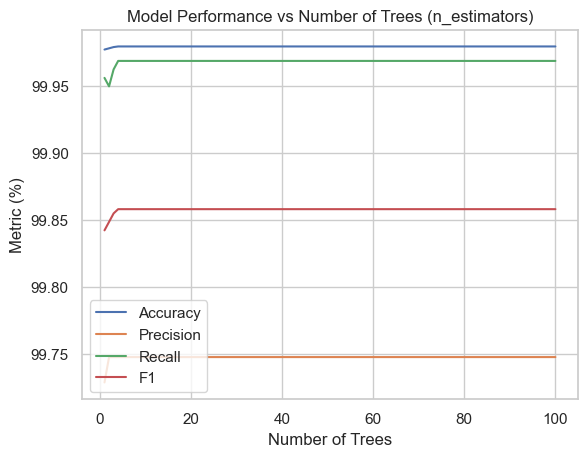

Best n_estimators (Accuracy): 4
Best Accuracy: 0.9997916666666666
Best n_estimators (Precision): 4
Best Precision: 0.9974758629393576
Best n_estimators (Recall): 4
Best Recall: 0.9996837844674931
Best n_estimators (F1): 4
Best F1: 0.9985786032407846


In [49]:
best_score, best_combo = results[0]
X_best = df[list(best_combo)]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=60)

lr = LogisticRegression(max_iter=1000, random_state=60)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f"Logistic Regression's Accuracy:  {accuracy_score(y_test, y_pred)}")
print(f"Logistic Regression's Precision: {precision_score(y_test, y_pred)}")
print(f"Logistic Regression's Recall:    {recall_score(y_test, y_pred)}")
print(f"Logistic Regression's F1 Score:  {f1_score(y_test, y_pred)}")

scores = {}
num_test_estimators = range(1, 101)
for n in num_test_estimators:
  print("Training:", n)
  clf = RandomForestClassifier(n_estimators=n, random_state=60, n_jobs=-1)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  scores[n] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }
accuracies = [scores[n]["accuracy"] * 100 for n in num_test_estimators]
precisions = [scores[n]["precision"] * 100 for n in num_test_estimators]
recalls = [scores[n]["recall"] * 100 for n in num_test_estimators]
f1s = [scores[n]["f1"] * 100 for n in num_test_estimators]
plt.plot(num_test_estimators, accuracies, label="Accuracy")
plt.plot(num_test_estimators, precisions, label="Precision")
plt.plot(num_test_estimators, recalls, label="Recall")
plt.plot(num_test_estimators, f1s, label="F1")
plt.xlabel("Number of Trees")
plt.ylabel("Metric (%)")
plt.title("Model Performance vs Number of Trees (n_estimators)")
plt.legend()
plt.grid(True)
plt.show()

best_n_acc = max(scores, key=lambda n: scores[n]["accuracy"])
best_score_acc = scores[best_n_acc]["accuracy"]
print("Best n_estimators (Accuracy):", best_n_acc)
print("Best Accuracy:", best_score_acc)

best_n_prec = max(scores, key=lambda n: scores[n]["precision"])
best_score_prec = scores[best_n_prec]["precision"]
print("Best n_estimators (Precision):", best_n_prec)
print("Best Precision:", best_score_prec)

best_n_recall = max(scores, key=lambda n: scores[n]["recall"])
best_score_recall = scores[best_n_recall]["recall"]
print("Best n_estimators (Recall):", best_n_recall)
print("Best Recall:", best_score_recall)

best_n_f1 = max(scores, key=lambda n: scores[n]["f1"])
best_score_f1 = scores[best_n_f1]["f1"]
print("Best n_estimators (F1):", best_n_f1)
print("Best F1:", best_score_f1)

Feature Importance:
subdomain_count     0.652575
unique_chars        0.225108
hyphen_count        0.091180
hex_ratio           0.017862
max_consec_digit    0.013033
embed_date          0.000241
dtype: float64


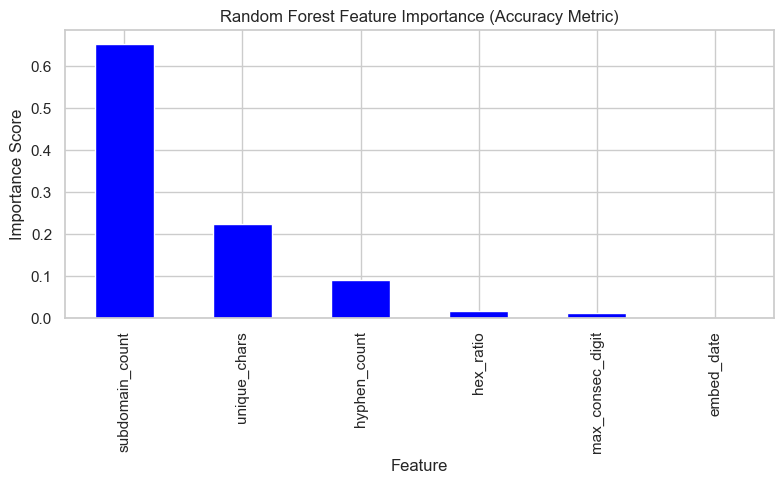

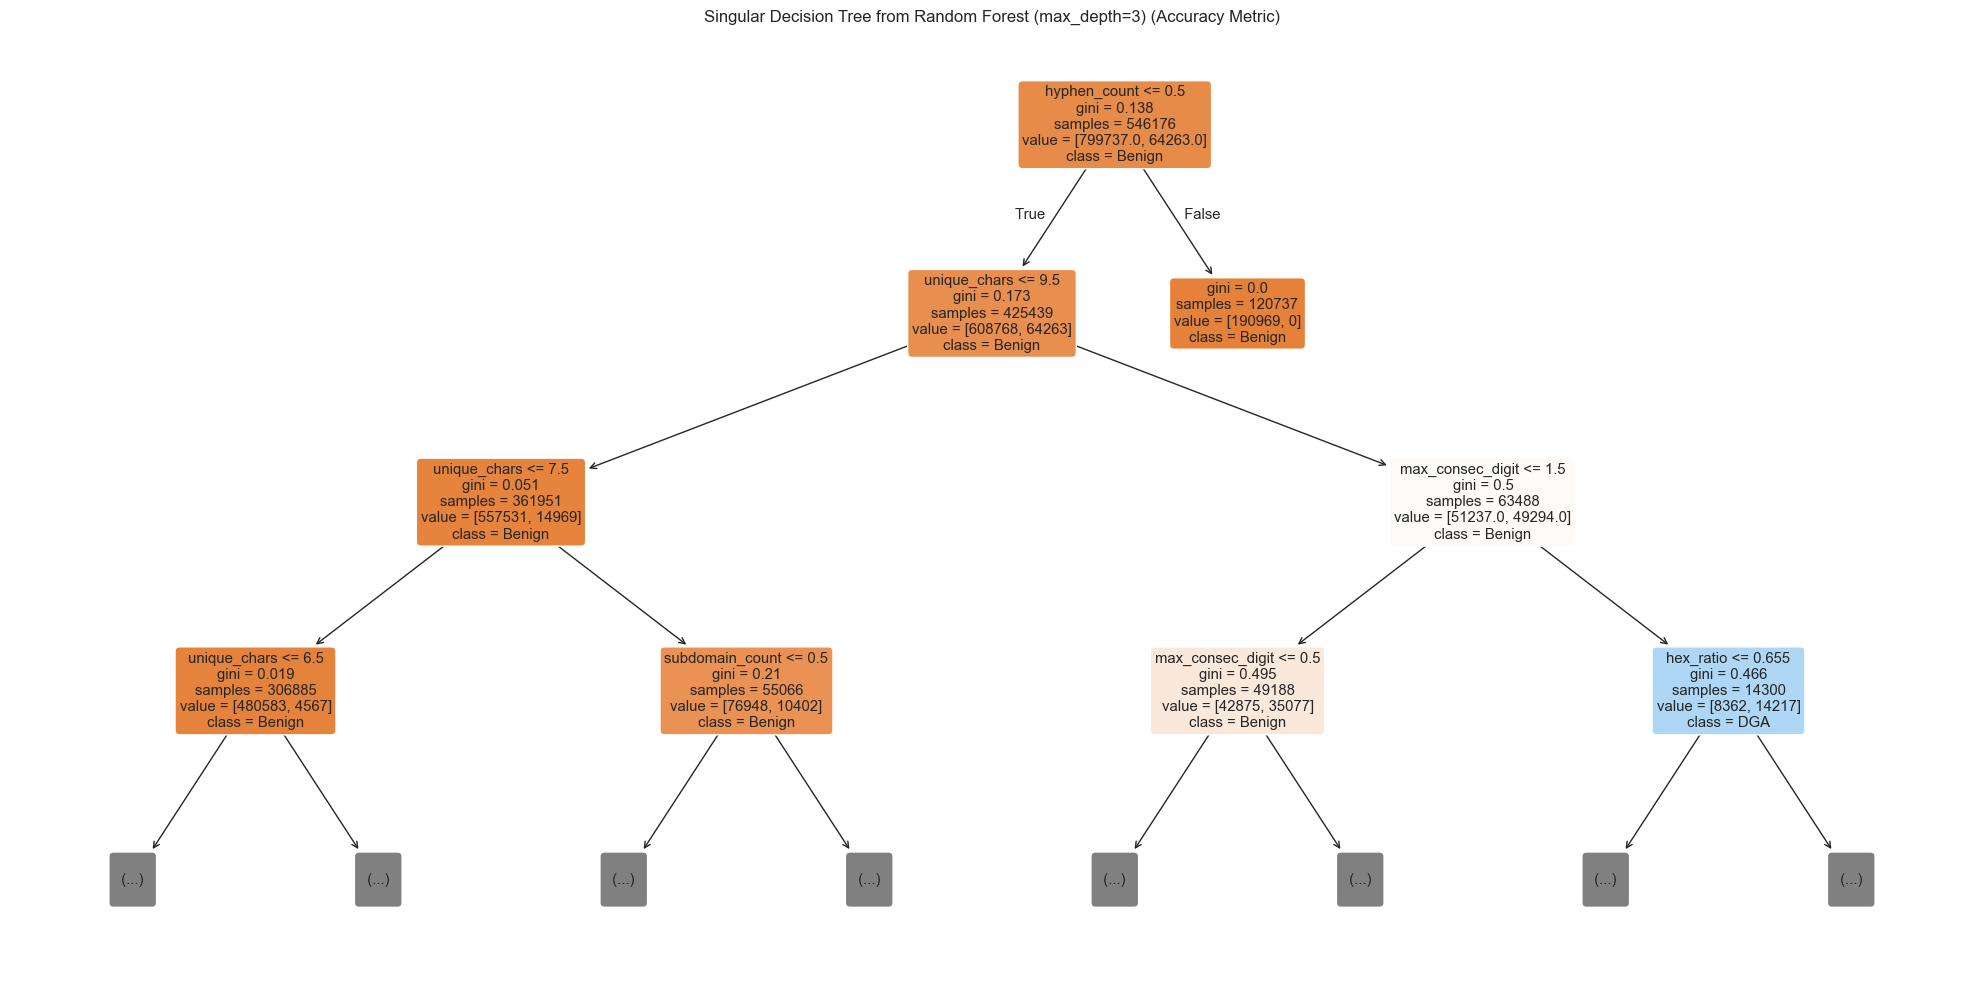

Feature Importance:
subdomain_count     0.652575
unique_chars        0.225108
hyphen_count        0.091180
hex_ratio           0.017862
max_consec_digit    0.013033
embed_date          0.000241
dtype: float64


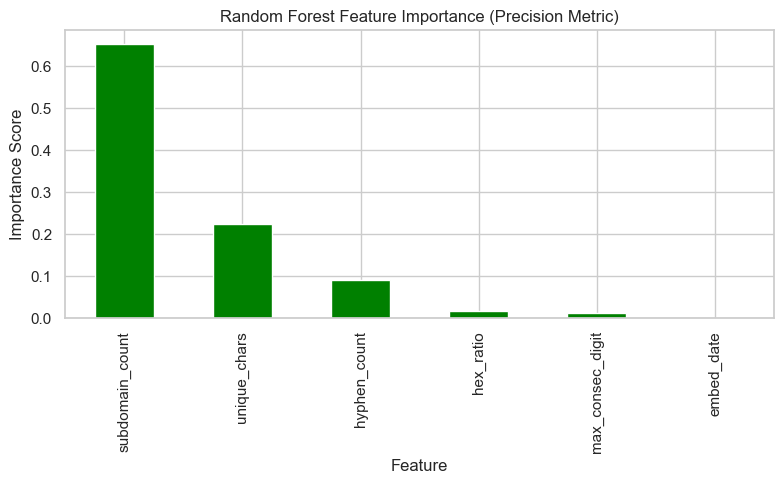

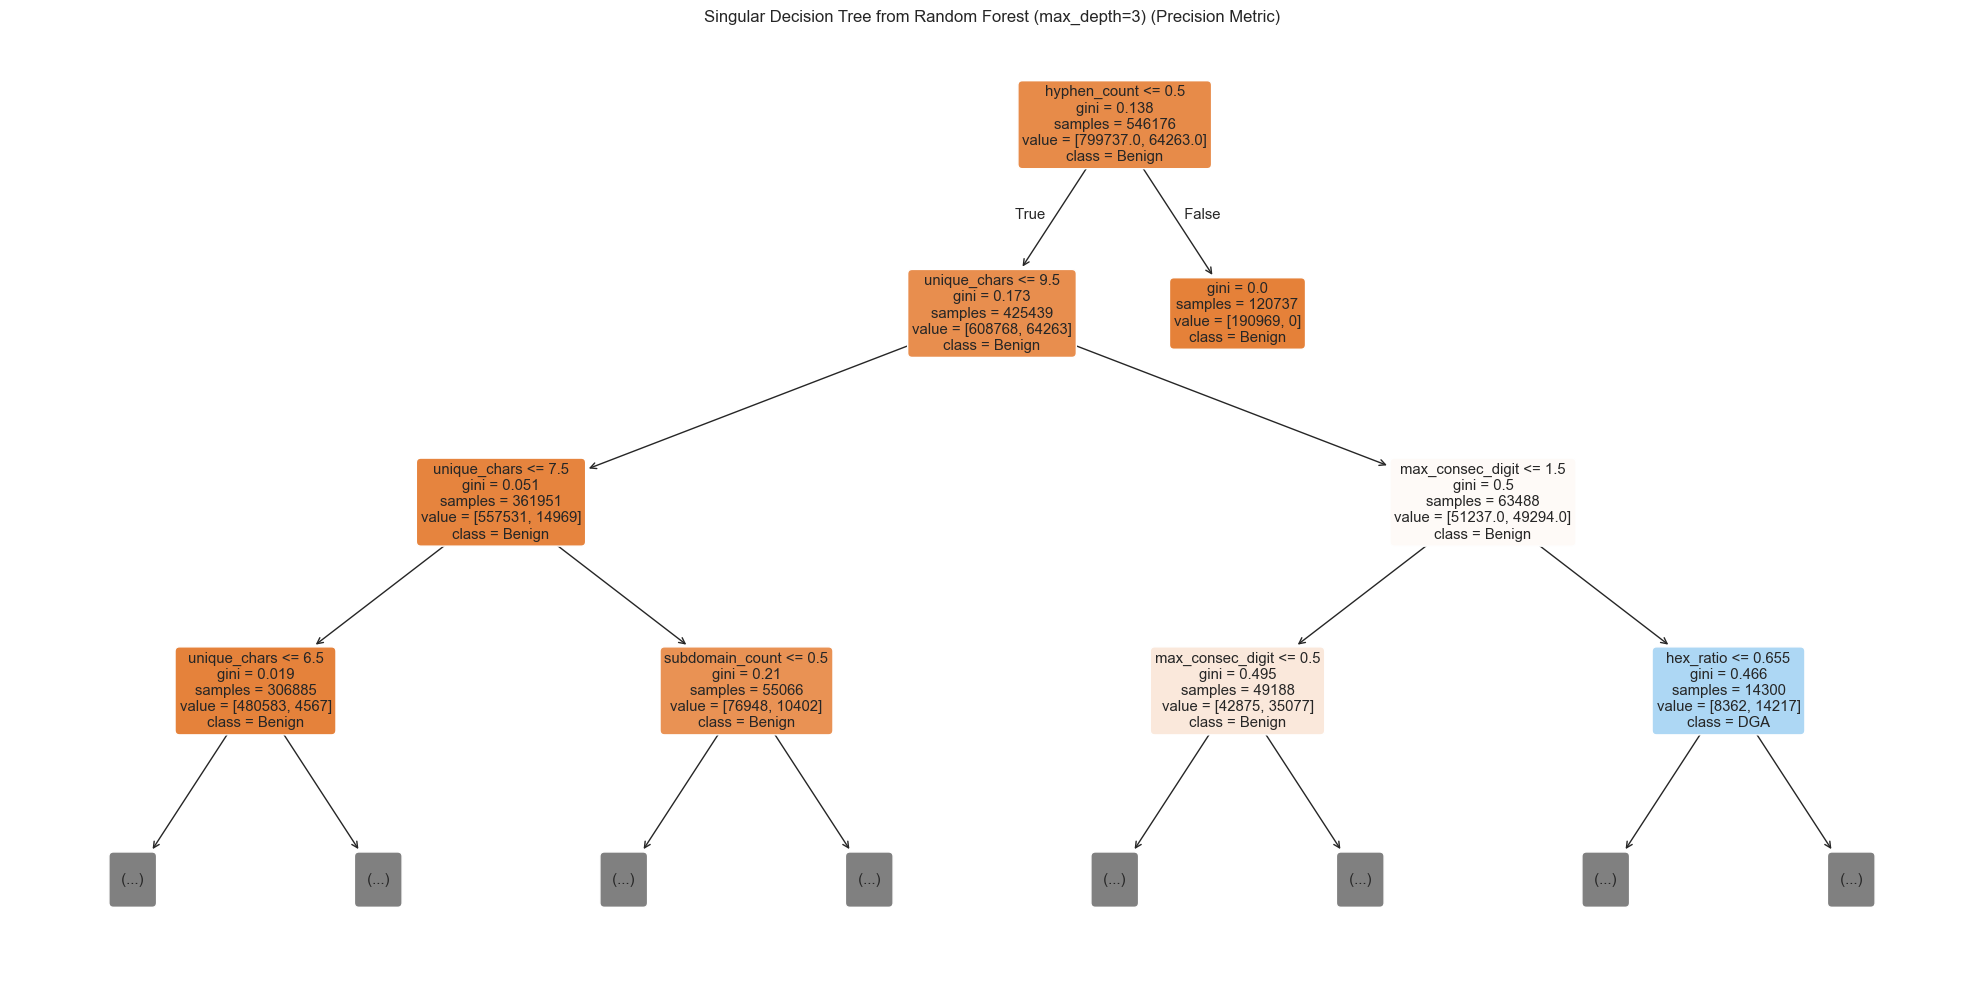

Feature Importance:
subdomain_count     0.652575
unique_chars        0.225108
hyphen_count        0.091180
hex_ratio           0.017862
max_consec_digit    0.013033
embed_date          0.000241
dtype: float64


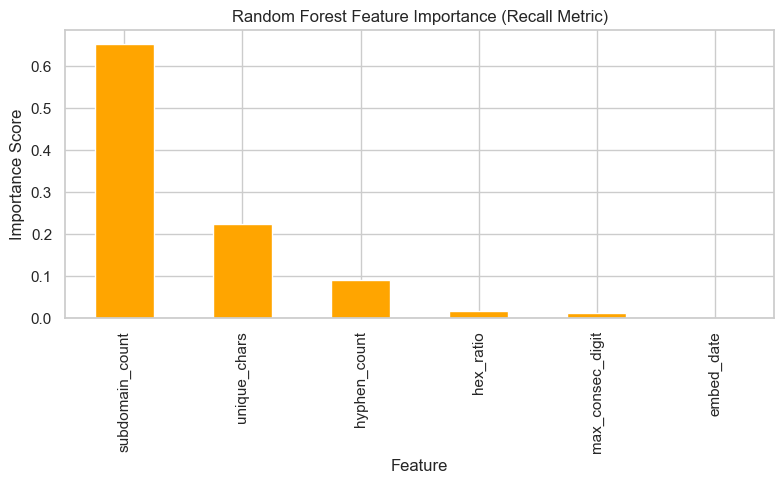

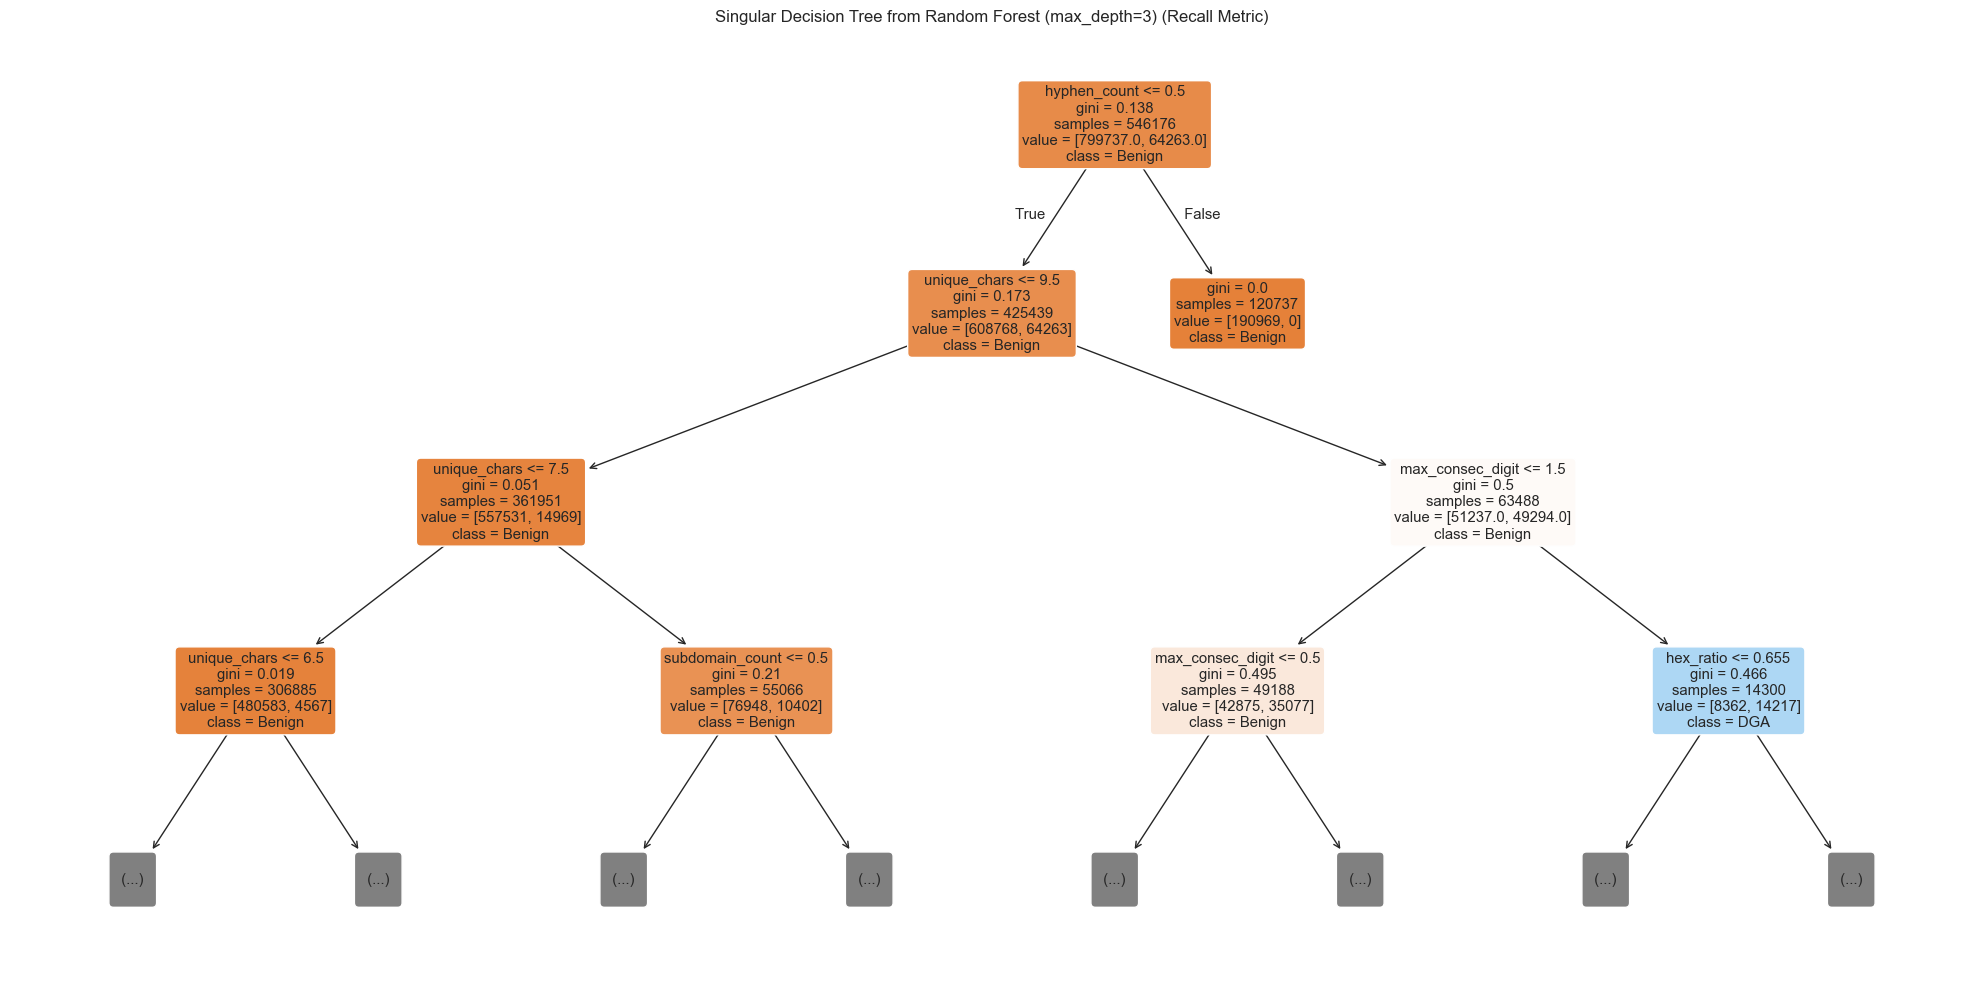

Feature Importance:
subdomain_count     0.652575
unique_chars        0.225108
hyphen_count        0.091180
hex_ratio           0.017862
max_consec_digit    0.013033
embed_date          0.000241
dtype: float64


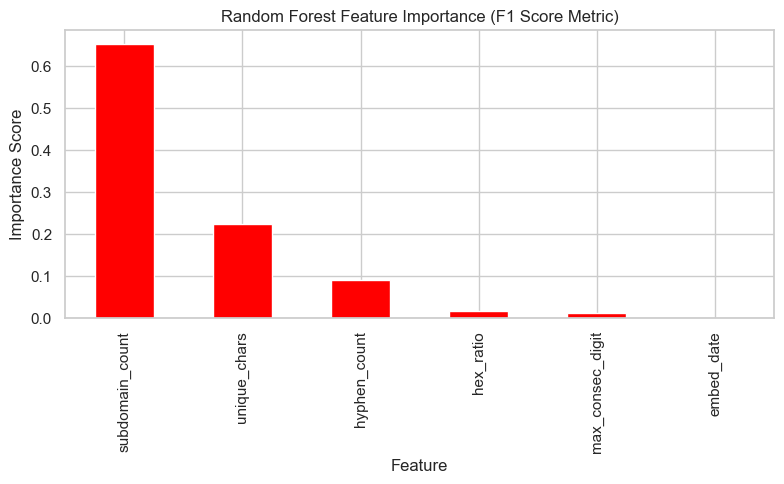

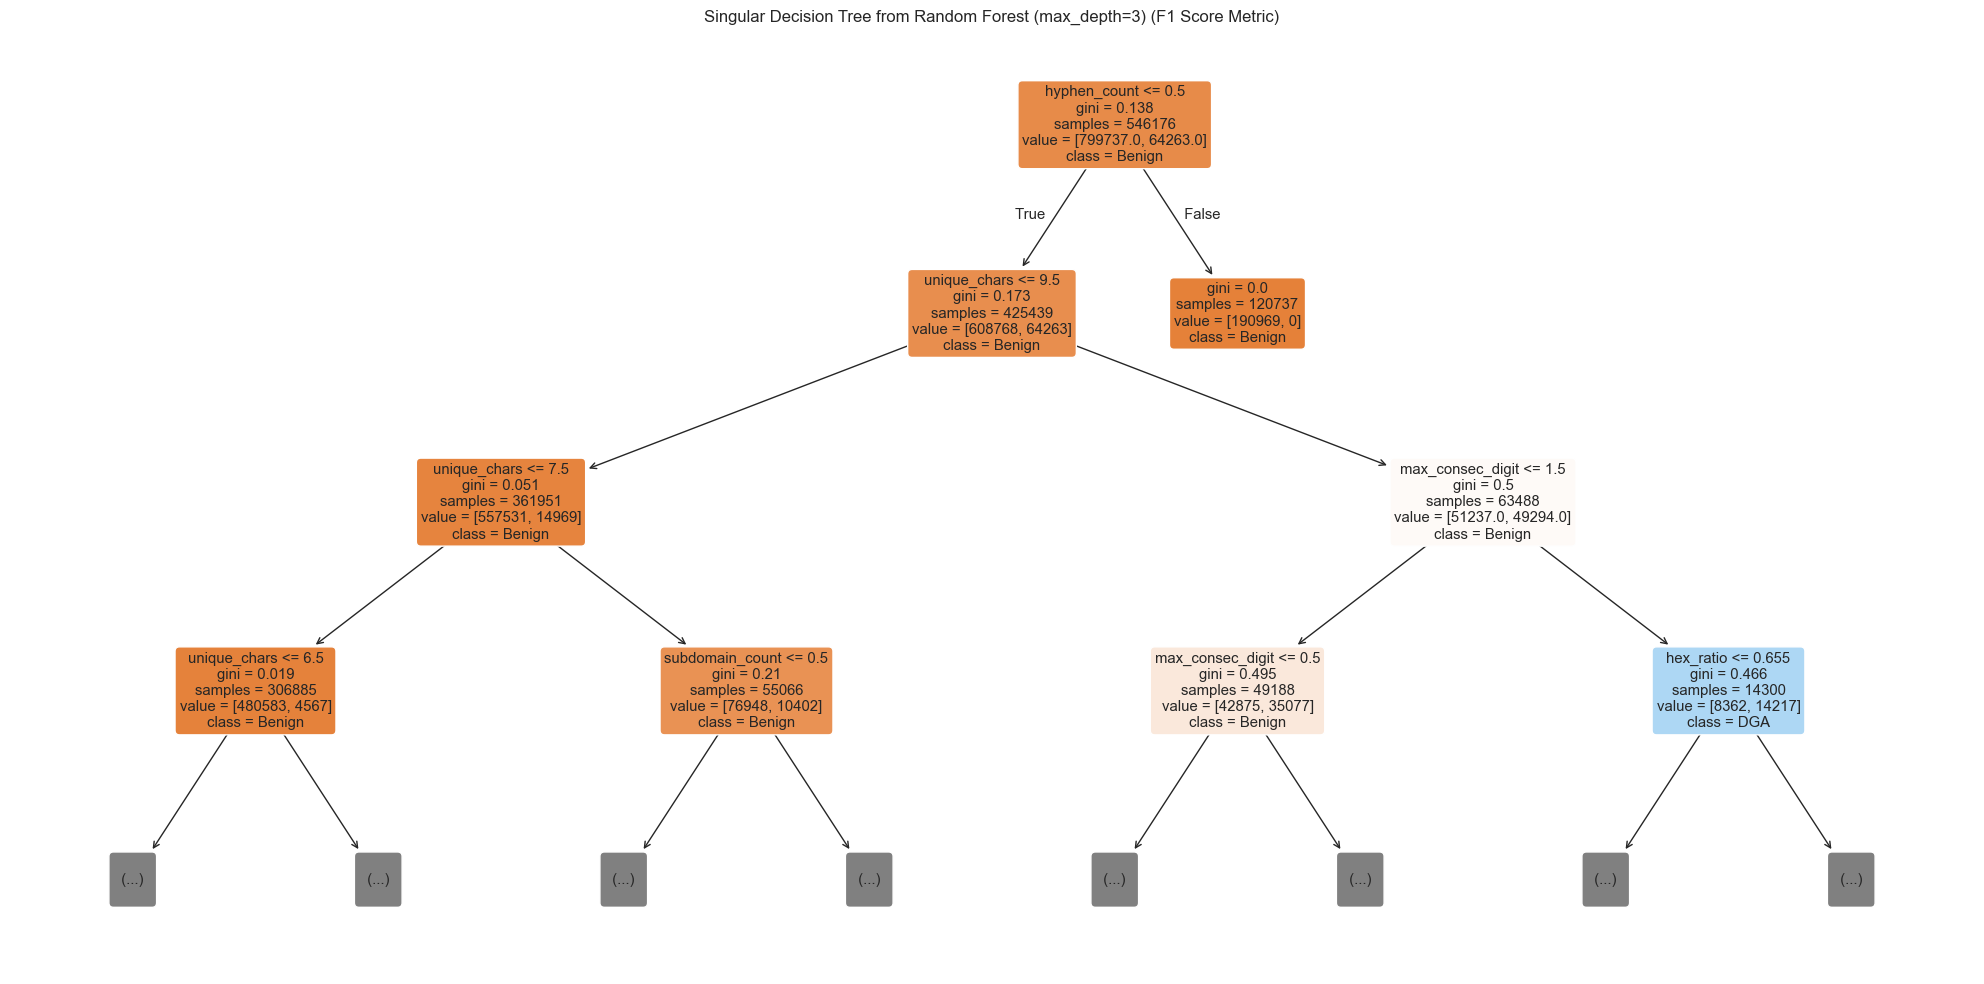

In [50]:
create_best_feature_importance(best_n_acc, "Accuracy", "blue")
create_best_feature_importance(best_n_prec, "Precision", "green")
create_best_feature_importance(best_n_recall, "Recall", "orange")
create_best_feature_importance(best_n_f1, "F1 Score", "red")

Accuracy (n=4):
	False Positive Rate: 0.00020 (0.020%)
	False Negative Rate: 0.00032 (0.032%)
	True Negatives=200148, False Positives=40, False Negatives=5, True Positives=15807

Precision (n=4):
	False Positive Rate: 0.00020 (0.020%)
	False Negative Rate: 0.00032 (0.032%)
	True Negatives=200148, False Positives=40, False Negatives=5, True Positives=15807

Recall (n=4):
	False Positive Rate: 0.00020 (0.020%)
	False Negative Rate: 0.00032 (0.032%)
	True Negatives=200148, False Positives=40, False Negatives=5, True Positives=15807

F1 Score (n=4):
	False Positive Rate: 0.00020 (0.020%)
	False Negative Rate: 0.00032 (0.032%)
	True Negatives=200148, False Positives=40, False Negatives=5, True Positives=15807



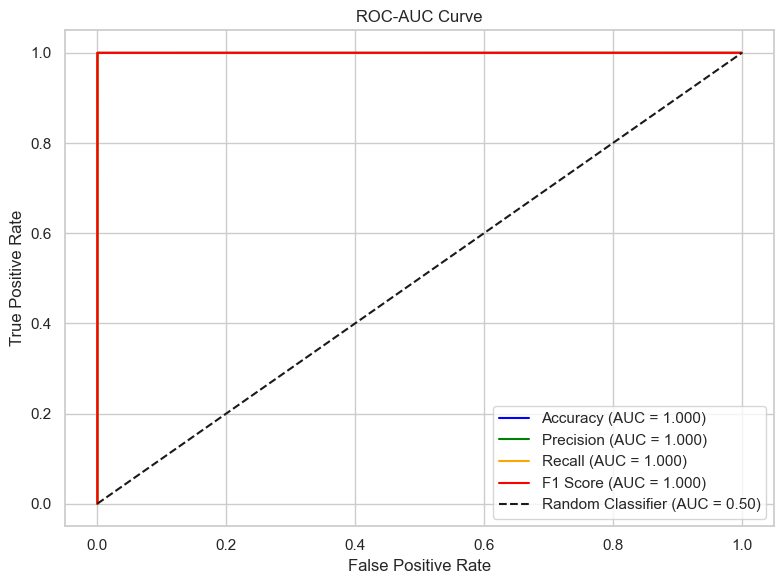

In [51]:
roc_auc_fpr(best_n_acc, best_n_prec, best_n_recall, best_n_f1, X_train, y_train, X_test, y_test)

Combinations without malicious TLD and subdomain count

In [52]:
features = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "embed_date"]

benign = df[df["label"] == 0].sample(n=25000, random_state=60)
dga = df[df["label"] == 1].sample(n=25000, random_state=60)
df_sample = pd.concat([benign, dga]).sample(frac=1, random_state=60)
# df_sample = df.sample(n=50000, random_state=60)
y = df_sample["label"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=60)
results = []
sample_n_estimators = 20
# test combinations of 3 to 8
for size in range(3, 9):
    for combo in combinations(features, size):
        X_sub = df_sample[list(combo)]
        clf = RandomForestClassifier(n_estimators=sample_n_estimators, random_state=60, n_jobs=-1)
        cv_scores = cross_val_score(clf, X_sub, y, cv=cv, scoring="f1", n_jobs=-1)
        mean_f1 = cv_scores.mean()
        results.append((mean_f1, combo))


results.sort(reverse=True)
print("15 best feature combinations:")
for score, combo in results[:15]:
    print(f"    F1 Score={score} | Length of Features:={len(combo)} | Features: {combo}")

15 best feature combinations:
    F1 Score=0.9273065598757446 | Length of Features:=6 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'max_consec_digit', 'puny_code', 'embed_date')
    F1 Score=0.9272490344078663 | Length of Features:=6 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit', 'embed_date')
    F1 Score=0.9272383944099738 | Length of Features:=6 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit')
    F1 Score=0.9272338245189914 | Length of Features:=5 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit')
    F1 Score=0.9272310295260662 | Length of Features:=5 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'max_consec_digit', 'puny_code')
    F1 Score=0.927231014853113 | Length of Features:=6 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit', 'puny_code')
    F1 Score=0.9272135877210518 | Length of Feat

In [53]:
for score, combo in results:
    print(f"    F1 Score={score} | Length of Features:={len(combo)} | Features: {combo}")

    F1 Score=0.9273065598757446 | Length of Features:=6 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'max_consec_digit', 'puny_code', 'embed_date')
    F1 Score=0.9272490344078663 | Length of Features:=6 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit', 'embed_date')
    F1 Score=0.9272383944099738 | Length of Features:=6 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit')
    F1 Score=0.9272338245189914 | Length of Features:=5 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit')
    F1 Score=0.9272310295260662 | Length of Features:=5 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'max_consec_digit', 'puny_code')
    F1 Score=0.927231014853113 | Length of Features:=6 | Features: ('length', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit', 'puny_code')
    F1 Score=0.9272135877210518 | Length of Features:=5 | Features: ('length',

Logistic Regression's Accuracy:  0.9637268518518518
Logistic Regression's Precision: 0.8272212650750677
Logistic Regression's Recall:    0.637680242853529
Logistic Regression's F1 Score:  0.7201885646941181
Training: 1
Training: 2
Training: 3
Training: 4
Training: 5
Training: 6
Training: 7
Training: 8
Training: 9
Training: 10
Training: 11
Training: 12
Training: 13
Training: 14
Training: 15
Training: 16
Training: 17
Training: 18
Training: 19
Training: 20
Training: 21
Training: 22
Training: 23
Training: 24
Training: 25
Training: 26
Training: 27
Training: 28
Training: 29
Training: 30
Training: 31
Training: 32
Training: 33
Training: 34
Training: 35
Training: 36
Training: 37
Training: 38
Training: 39
Training: 40
Training: 41
Training: 42
Training: 43
Training: 44
Training: 45
Training: 46
Training: 47
Training: 48
Training: 49
Training: 50
Training: 51
Training: 52
Training: 53
Training: 54
Training: 55
Training: 56
Training: 57
Training: 58
Training: 59
Training: 60
Training: 61
Training:

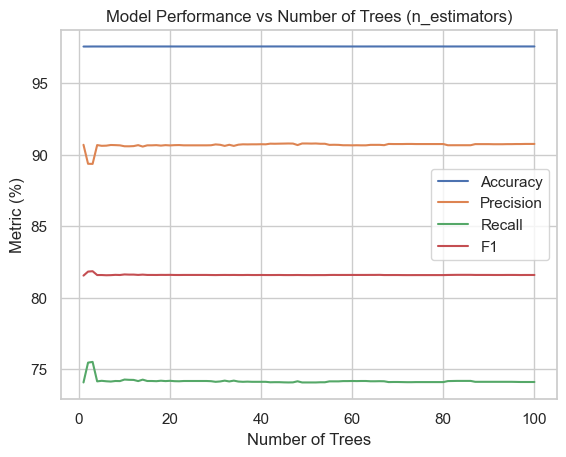

Best n_estimators (Accuracy): 10
Best Accuracy: 0.9755092592592592
Best n_estimators (Precision): 46
Best Precision: 0.9076958846779819
Best n_estimators (Recall): 3
Best Recall: 0.7550594485201113
Best n_estimators (F1): 3
Best F1: 0.8184404455869752


In [54]:
best_score, best_combo = results[0]
X_best = df[list(best_combo)]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=60)

lr = LogisticRegression(max_iter=1000, random_state=60)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f"Logistic Regression's Accuracy:  {accuracy_score(y_test, y_pred)}")
print(f"Logistic Regression's Precision: {precision_score(y_test, y_pred)}")
print(f"Logistic Regression's Recall:    {recall_score(y_test, y_pred)}")
print(f"Logistic Regression's F1 Score:  {f1_score(y_test, y_pred)}")

scores = {}
num_test_estimators = range(1, 101)
for n in num_test_estimators:
  print("Training:", n)
  clf = RandomForestClassifier(n_estimators=n, random_state=60, n_jobs=-1)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  scores[n] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }
accuracies = [scores[n]["accuracy"] * 100 for n in num_test_estimators]
precisions = [scores[n]["precision"] * 100 for n in num_test_estimators]
recalls = [scores[n]["recall"] * 100 for n in num_test_estimators]
f1s = [scores[n]["f1"] * 100 for n in num_test_estimators]
plt.plot(num_test_estimators, accuracies, label="Accuracy")
plt.plot(num_test_estimators, precisions, label="Precision")
plt.plot(num_test_estimators, recalls, label="Recall")
plt.plot(num_test_estimators, f1s, label="F1")
plt.xlabel("Number of Trees")
plt.ylabel("Metric (%)")
plt.title("Model Performance vs Number of Trees (n_estimators)")
plt.legend()
plt.grid(True)
plt.show()

best_n_acc = max(scores, key=lambda n: scores[n]["accuracy"])
best_score_acc = scores[best_n_acc]["accuracy"]
print("Best n_estimators (Accuracy):", best_n_acc)
print("Best Accuracy:", best_score_acc)

best_n_prec = max(scores, key=lambda n: scores[n]["precision"])
best_score_prec = scores[best_n_prec]["precision"]
print("Best n_estimators (Precision):", best_n_prec)
print("Best Precision:", best_score_prec)

best_n_recall = max(scores, key=lambda n: scores[n]["recall"])
best_score_recall = scores[best_n_recall]["recall"]
print("Best n_estimators (Recall):", best_n_recall)
print("Best Recall:", best_score_recall)

best_n_f1 = max(scores, key=lambda n: scores[n]["f1"])
best_score_f1 = scores[best_n_f1]["f1"]
print("Best n_estimators (F1):", best_n_f1)
print("Best F1:", best_score_f1)

Feature Importance:
max_consec_cons     0.436918
length              0.361866
hyphen_count        0.142939
max_consec_digit    0.044367
embed_date          0.013902
puny_code           0.000009
dtype: float64


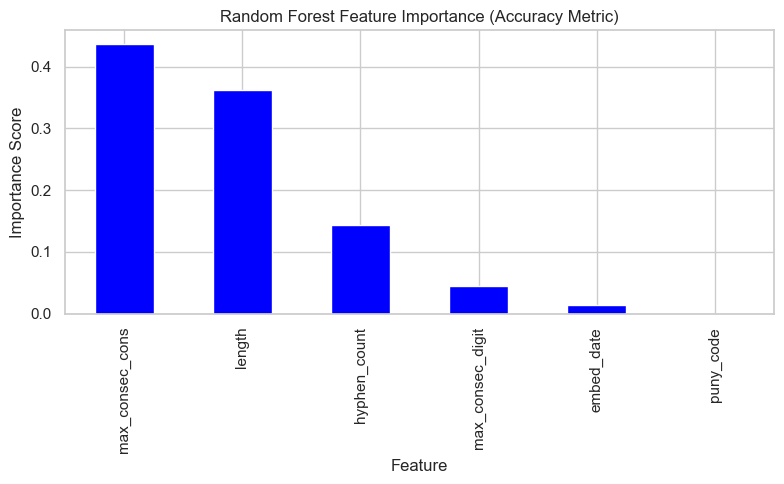

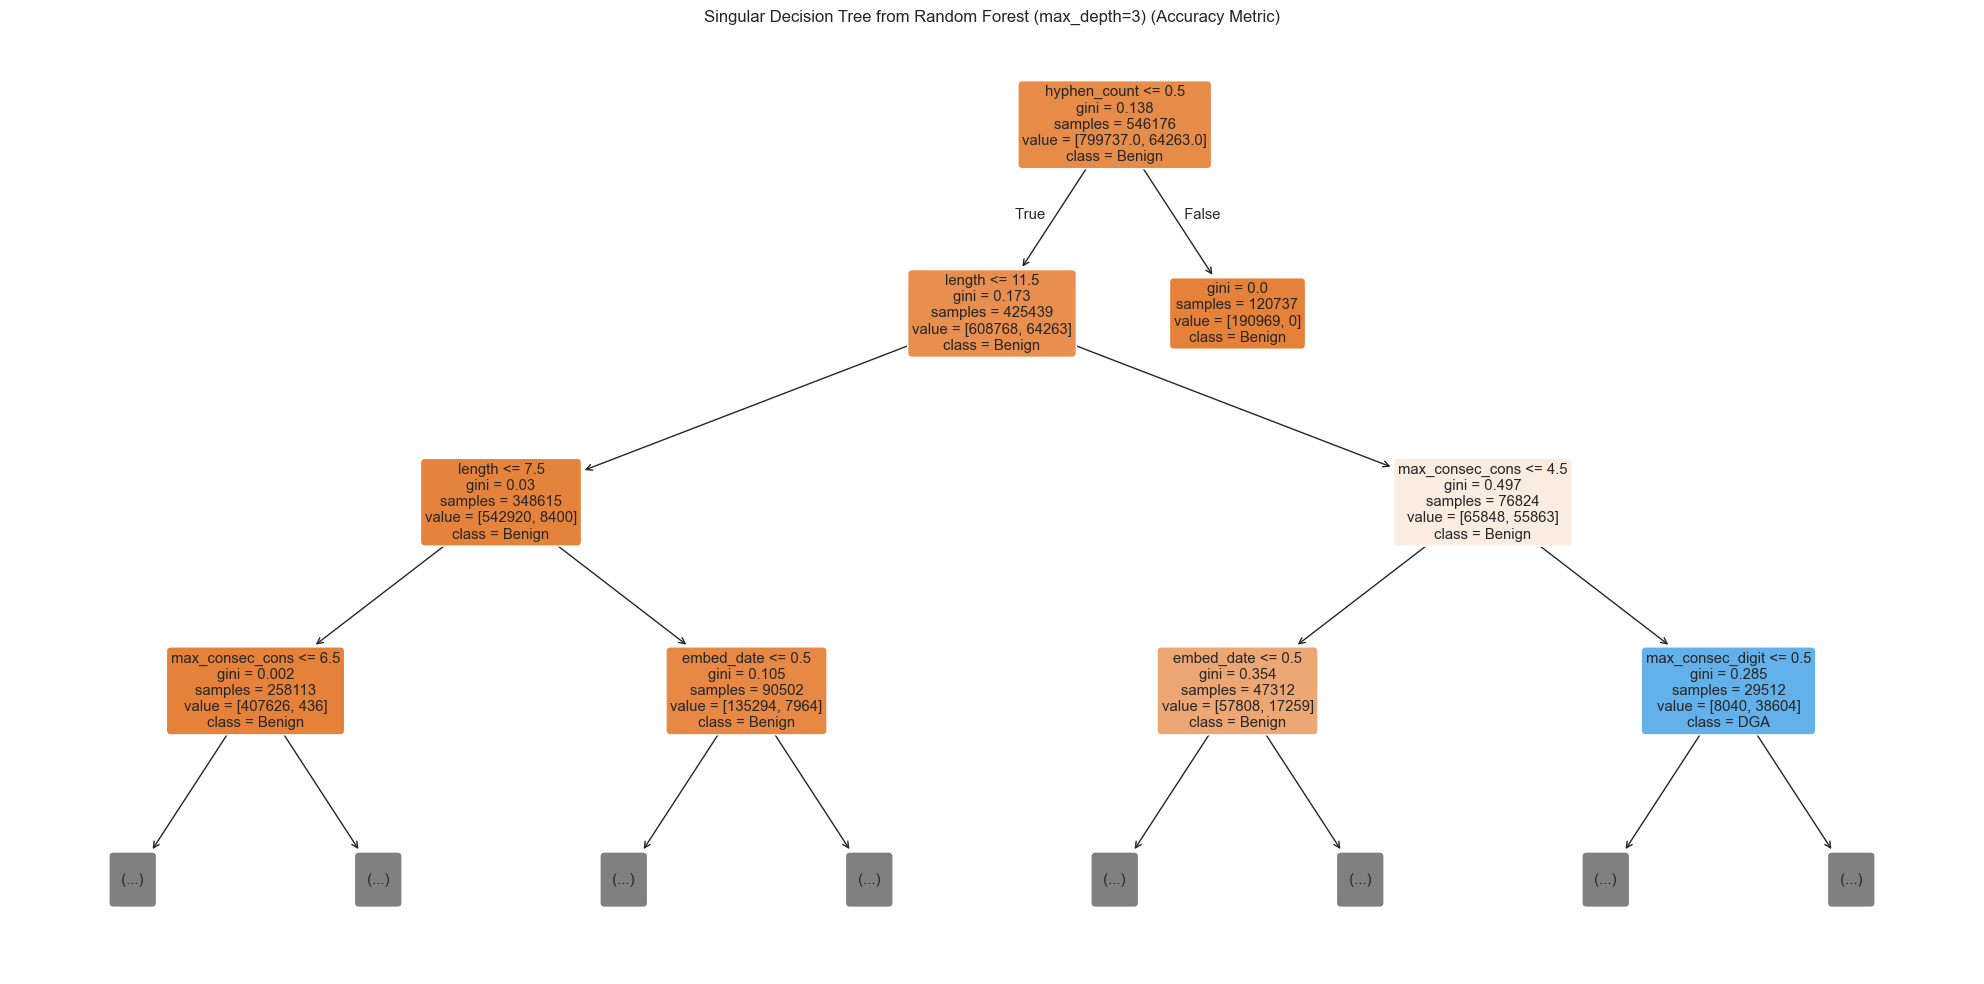

Feature Importance:
max_consec_cons     0.465307
length              0.352462
hyphen_count        0.123659
max_consec_digit    0.040864
embed_date          0.017700
puny_code           0.000008
dtype: float64


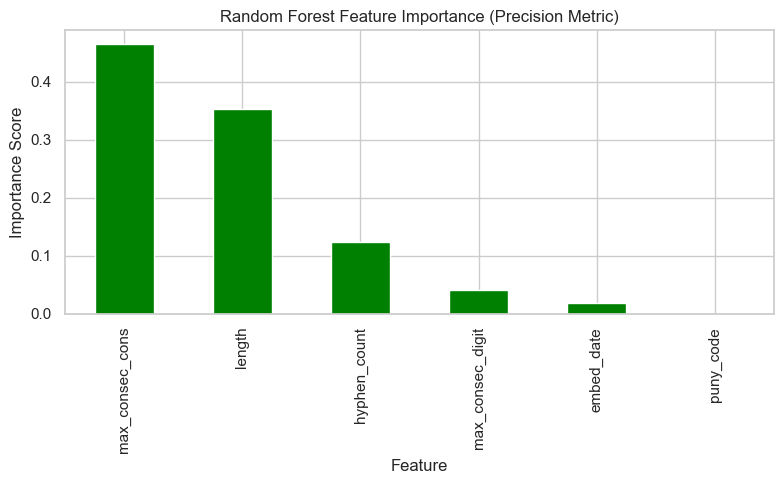

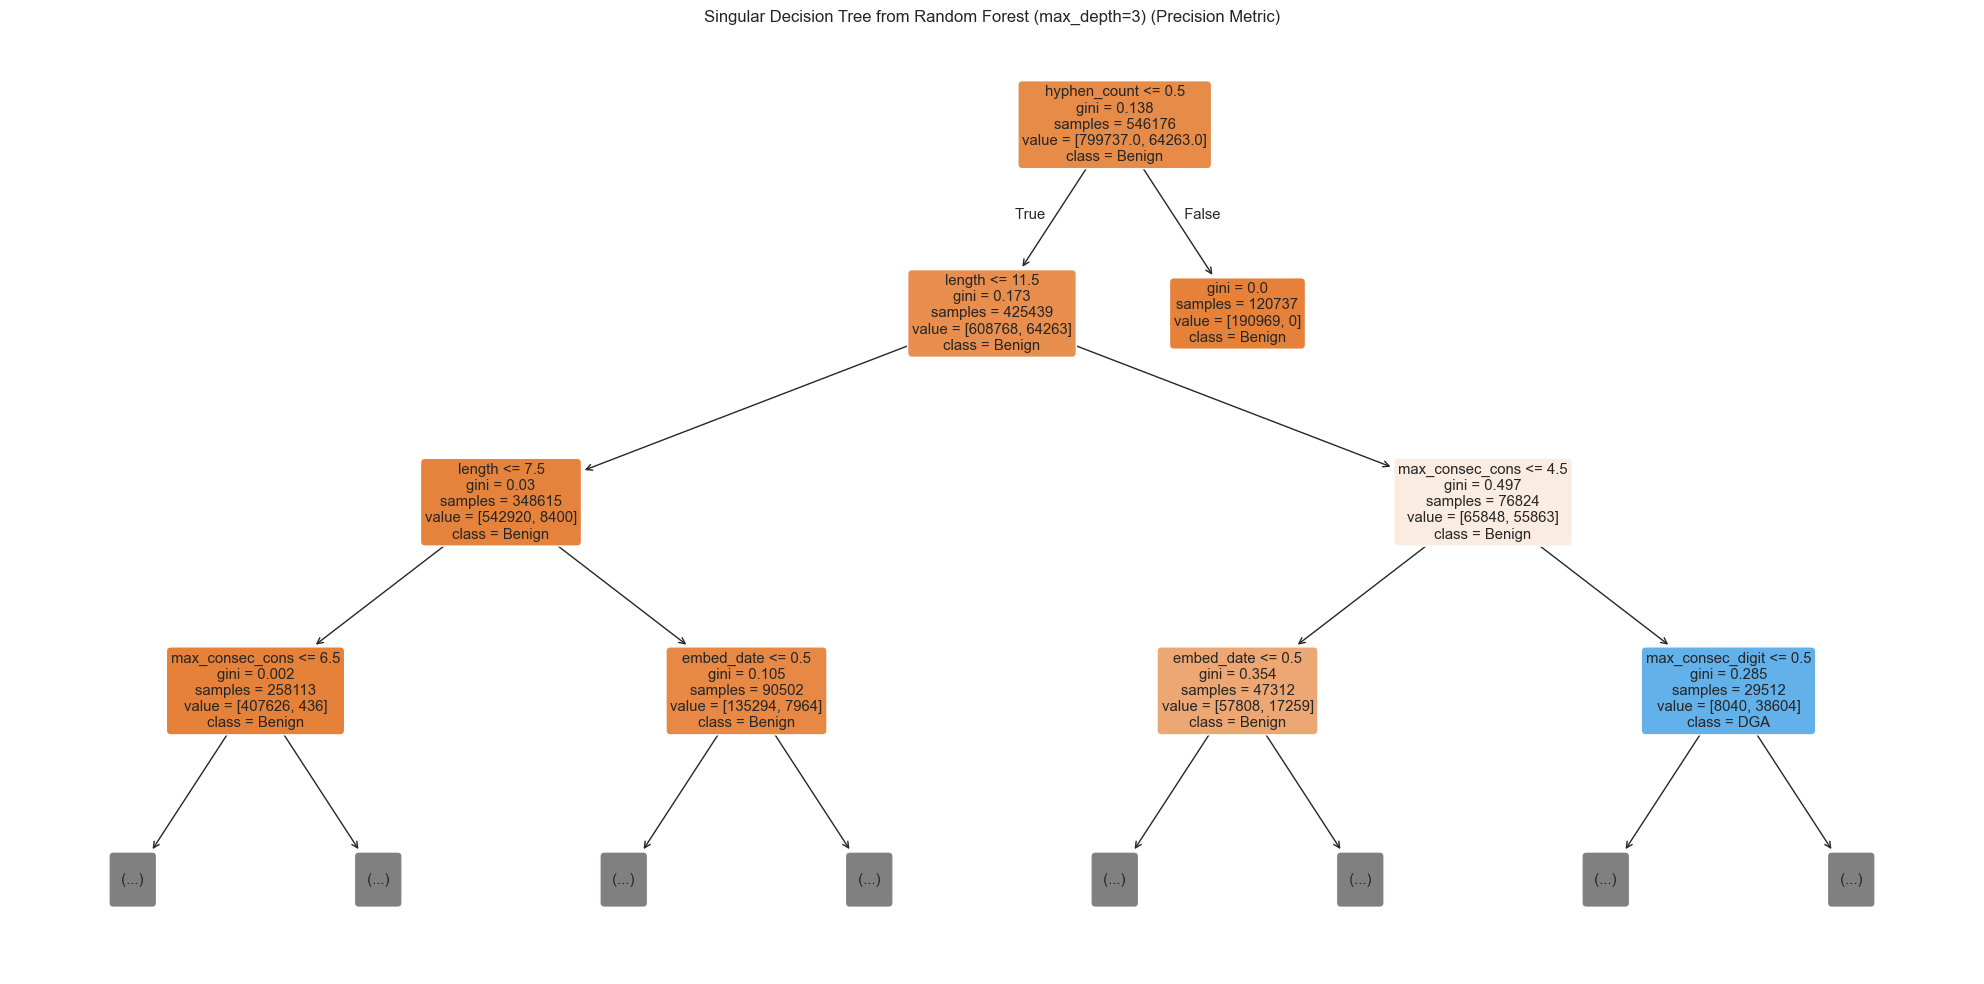

Feature Importance:
length              4.042066e-01
max_consec_cons     3.599360e-01
hyphen_count        1.619638e-01
max_consec_digit    5.892674e-02
embed_date          1.496624e-02
puny_code           5.581130e-07
dtype: float64


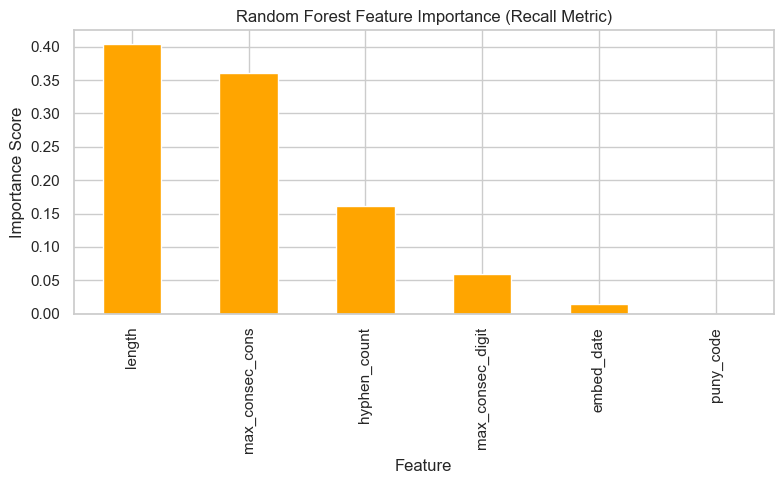

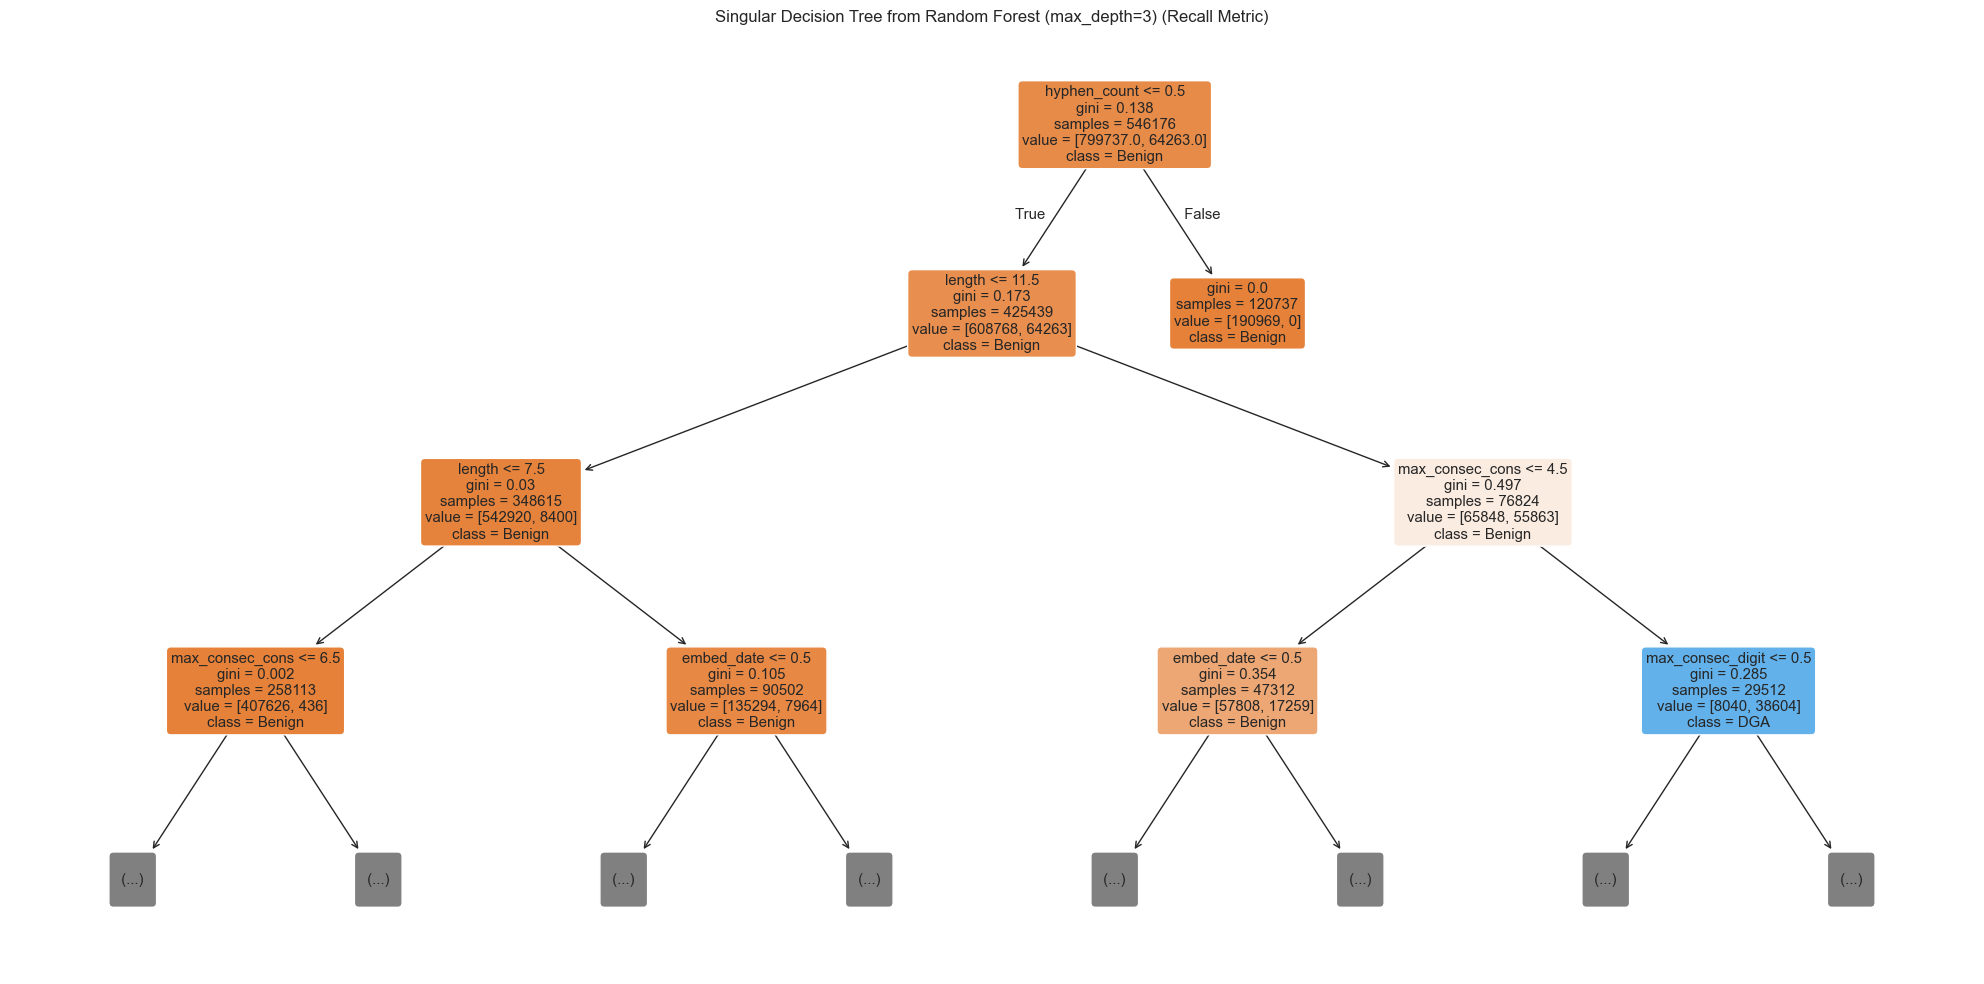

Feature Importance:
length              4.042066e-01
max_consec_cons     3.599360e-01
hyphen_count        1.619638e-01
max_consec_digit    5.892674e-02
embed_date          1.496624e-02
puny_code           5.581130e-07
dtype: float64


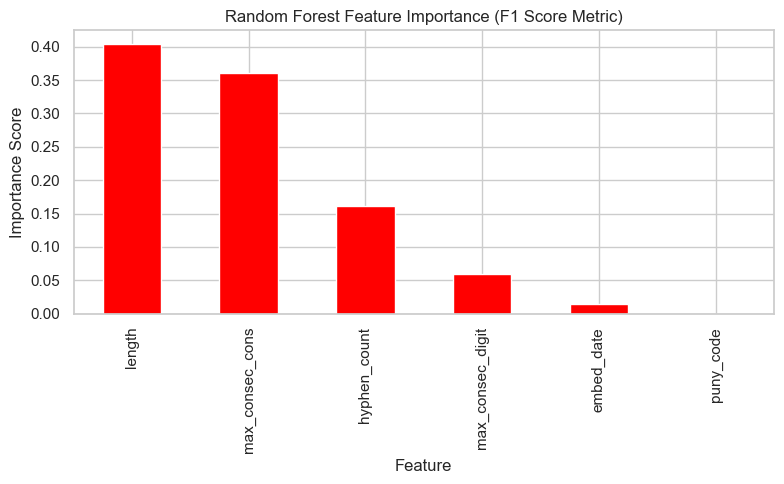

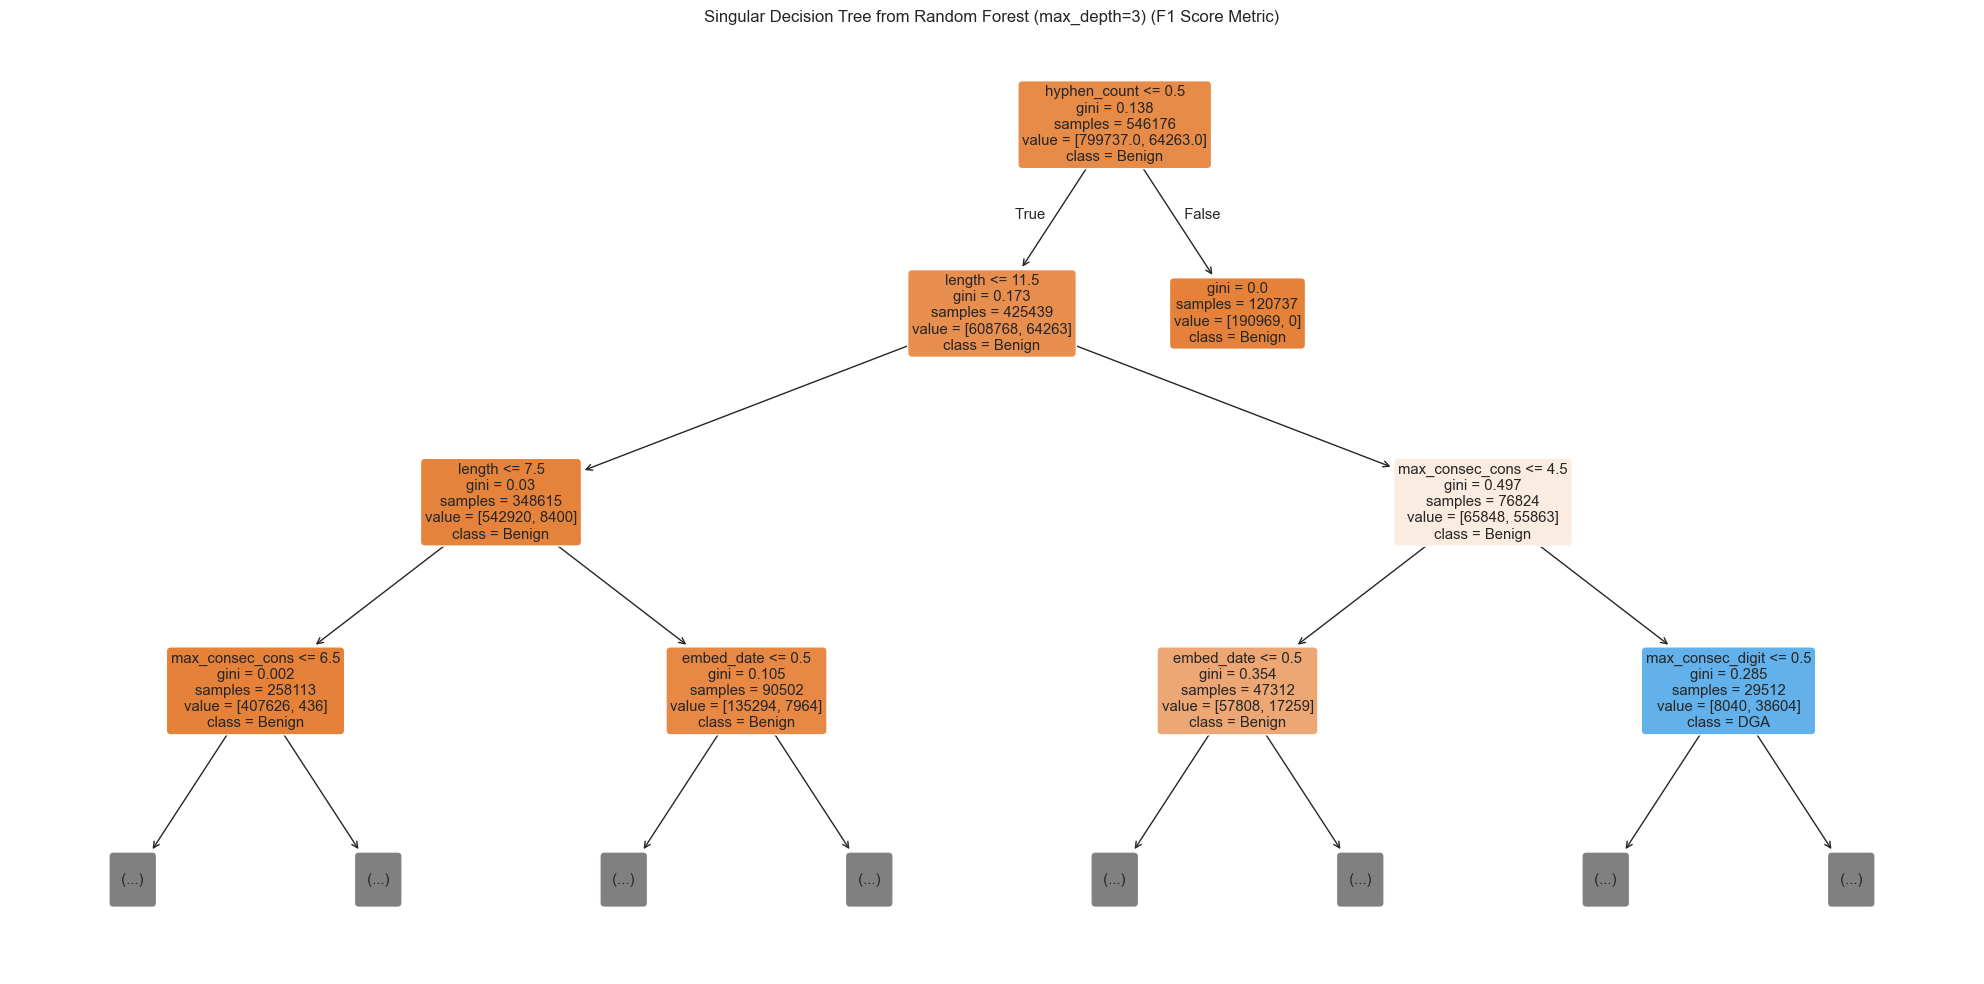

In [55]:
create_best_feature_importance(best_n_acc, "Accuracy", "blue")
create_best_feature_importance(best_n_prec, "Precision", "green")
create_best_feature_importance(best_n_recall, "Recall", "orange")
create_best_feature_importance(best_n_f1, "F1 Score", "red")

Accuracy (n=10):
	False Positive Rate: 0.00610 (0.610%)
	False Negative Rate: 0.25727 (25.727%)
	True Negatives=198966, False Positives=1222, False Negatives=4068, True Positives=11744

Precision (n=46):
	False Positive Rate: 0.00595 (0.595%)
	False Negative Rate: 0.25930 (25.930%)
	True Negatives=198997, False Positives=1191, False Negatives=4100, True Positives=11712

Recall (n=3):
	False Positive Rate: 0.00711 (0.711%)
	False Negative Rate: 0.24494 (24.494%)
	True Negatives=198764, False Positives=1424, False Negatives=3873, True Positives=11939

F1 Score (n=3):
	False Positive Rate: 0.00711 (0.711%)
	False Negative Rate: 0.24494 (24.494%)
	True Negatives=198764, False Positives=1424, False Negatives=3873, True Positives=11939



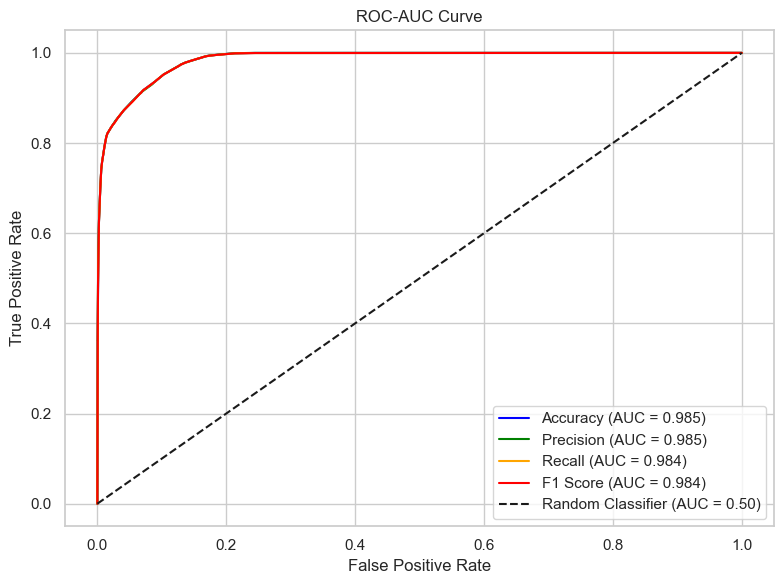

In [56]:
roc_auc_fpr(best_n_acc, best_n_prec, best_n_recall, best_n_f1, X_train, y_train, X_test, y_test)